<center>

<img src='https://micro.ce.sharif.edu/lib/tpl/writr/images/logo.svg' alt="SUT logo" width=500 height=300 align=center class="saturate" >


<br>
<font>
<div dir=ltr align=center>
<font color=0F5298 size=7>
Machine Learning <br>
<font color=2565AE size=5>
Computer Engineering Department <br>
Dr. Sharifi-Zarchi, Fall 2025 <br>
<font color=3C99D size=5>
Practical Assignment 5 - Natural Language Processing <br>
<font color=696880 size=4>
By: Sina Bayrami

</center>


# Notebook Overview — NER from BiLSTM to (Tiny)BERT

This notebook is a **hands-on, end-to-end practical lab** for a core NLP task: **Named Entity Recognition (NER)**.  
You will start from a strong non-Transformer baseline and gradually build up the ideas that lead to modern Transformer encoders and BERT-style pretraining—then you will compare those approaches fairly on the **same NER problem**.

The goal is not to “memorize architectures”, but to **learn what each ingredient adds**, why it matters, and how to evaluate models correctly.

## 1) What is NER and what are we trying to do?


**Named Entity Recognition (NER)** is a **token-level sequence labeling** task.

- **Input:** a sentence as a sequence of tokens  
  $$
  x = (x_1, x_2, \dots, x_T)
  $$
- **Output:** a label for each token  
  $$
  y = (y_1, y_2, \dots, y_T)
  $$
  where labels usually follow a BIO-style format (e.g., **B-PERSON**, **I-ORG**, **O**).

**What we want:** learn a model $f_\theta$ that predicts the correct tag for each token:
$$
\hat{y}_t = \arg\max_k \; p_\theta(y_t = k \mid x)
$$

NER is difficult because:
- Entities can span multiple tokens (e.g., “New York City”)
- Context matters (e.g., “Jordan” can be a person or a location)
- Most tokens are **not** entities → the label **O** is dominant

## 2) How we evaluate: Metrics (and why F1 is the main one)

In NER, **token accuracy** can be misleading because a model can predict **O** almost everywhere and still look “good”.

So we use two families of metrics:

### A) Token Accuracy (quick sanity metric)
Token accuracy is:
$$
\text{Acc}=\frac{\#\{t:\hat{y}_t=y_t\}}{T}
$$
But because **O** dominates, accuracy often hides failures on entities.

### B) Entity-level Precision / Recall / F1 (the main metric)
We care about **entities as spans**, not just individual tokens.

From a BIO tag sequence we extract a set of predicted entity spans $\hat{E}$ and gold spans $E$.  
A predicted entity is counted as **correct (TP)** only if:
- the span boundaries match exactly, and
- the entity type matches exactly

Define:
- $TP$: number of correctly predicted entities  
- $FP$: predicted entities not in gold  
- $FN$: gold entities missed by the model  

Then:
$$
P=\frac{TP}{TP+FP},\qquad
R=\frac{TP}{TP+FN}
$$
and the **F1-score** is the harmonic mean:
$$
F1 = \frac{2PR}{P+R}
$$
F1 heavily penalizes models that:
- miss entities (high FN → low recall),
- hallucinate entities (high FP → low precision),
- or get boundaries/types wrong (not counted as TP).

**In this notebook, the most important score is entity-level F1.**  
Token accuracy is mainly a secondary diagnostic.

## 3) What happens in each stage?

### Part 1 — Baseline: BiLSTM Tagger (sequential encoder)
Start with a strong classical baseline:
- a contextual encoder that reads tokens left-to-right and right-to-left
- predicts a tag per token

**What you learn:** a sequential model captures order naturally, but has limited parallelism and long-range interaction costs.

---

### Part 2 — Add Self-Attention on top of the baseline
You keep the baseline encoder and **add a single self-attention mechanism** after it.

**What you learn:** attention can mix global context and sometimes improve tagging quality; attention maps are also interpretable.

---

### Part 3 — Attention-only (remove the sequential encoder)
Now you remove the sequential component and try a model that relies on **self-attention only**, without any explicit notion of position.

**What you learn:** self-attention alone can mix token content, but **does not inherently know order**, so performance can degrade on tasks where order matters.

---

### Part 4 — Fix the order problem by adding Positional Encoding
You keep the attention-only design, but now inject **positional information** into the token representations.

**What you learn:** adding position makes attention usable for order-sensitive tasks, and you can directly compare Part 3 vs Part 4 as an ablation.

---

### Part 5 — Upgrade to Multi-Head Attention
You replace single attention with **multi-head attention**, so the model can represent different relation patterns in parallel.

**What you learn:** multiple heads can specialize (local vs long-range, boundaries vs separators, etc.), and you can visualize different heads.

---

### Part 6 — Build a deeper Transformer encoder (“mini-BERT brick”) + depth ablation
You turn the attention block into a standard encoder layer and stack layers to study **depth vs performance**.

**What you learn:** depth can help, but not always; optimization and overfitting constraints appear; ablations teach you what matters empirically.

---

### Part 7 — BERT-style inputs and embedding recipe
You transition from “generic sequence tagging inputs” to **BERT-style inputs**:
- special tokens ([CLS], [SEP], [MASK])
- token type (segment) IDs
- position IDs
- embedding composition used by BERT-like models

**What you learn:** how the input representation design supports pretraining and downstream fine-tuning.

---

### Part 8 — Pretraining objective: MLM (Masked Language Modeling)
You pretrain your encoder on **MLM**, where only a subset of tokens are predicted (masked positions).

**What you learn:** pretraining teaches general language/statistical structure without labels, and the masking strategy matters.

---

### Part 9 — Pretraining objective: NSP + joint MLM+NSP
You extend pretraining with a second objective: **Next Sentence Prediction (NSP)**, and train with MLM+NSP jointly.

**What you learn:** multi-objective pretraining, what NSP is trying to encourage, and why its benefit can be mixed.

---

### Part 10 — Fine-tune TinyBERT for NER (scratch vs pretrained initializations)
You fine-tune on NER and compare three conditions under a similar fine-tuning budget:
- random initialization (scratch)
- MLM-pretrained initialization
- MLM+NSP-pretrained initialization

**What you learn:** how pretraining affects downstream learning speed, stability, and final entity F1.

---

### Part 11 — Fine-tune a foundation model (pretrained DistilBERT/BERT)
You fine-tune a real pretrained Transformer model using a modern library pipeline.

**What you learn:** what large-scale pretraining buys you in practice (data efficiency + stronger performance), and how subword tokenization affects label alignment conceptually.

---

### Part 12 — Analysis Lab: attention interpretability + computational cost
You treat the final part like a mini research lab:
- visualize attention maps from a fine-tuned pretrained model
- inspect predictions vs gold labels
- measure how runtime scales with sequence length
- build a final comparison table across all approaches

**What you learn:** interpretability signals (with caution), and the practical limitation of attention’s quadratic scaling.

## 4) The full “sequence chain” of the notebook (the big picture)

You can summarize the notebook progression as:

1. **Reliable NER evaluation + reproducible training loop**  
2. **Sequential baseline (BiLSTM)**  
3. **Add attention (global mixing) while keeping sequence awareness**  
4. **Remove sequence awareness → observe failure**  
5. **Restore order with positional encoding → recover performance**  
6. **Scale attention with multi-head + depth → stronger encoder**  
7. **Adopt BERT-style input/embedding recipe**  
8. **Pretrain with MLM (self-supervision)**  
9. **Optionally add NSP and compare**  
10. **Fine-tune and measure the value of pretraining**  
11. **Compare against a real pretrained foundation model**  
12. **Interpret + analyze efficiency and limitations**

This is a controlled story of **how modern Transformer encoders emerge from specific design decisions**.

## 5) What we expect you to practice while completing TODOs

As you fill in TODO sections, your focus should be:
- correctness and reproducibility (your code must rerun cleanly)
- fair comparisons (avoid changing multiple factors at once)
- careful evaluation (use entity F1 as the main score)
- interpretation (attention maps and failure cases are part of the learning)

Whenever you change something important, document it briefly in a Markdown cell near the change.

## 6) Grading criteria

Your grade in this notebook will be based on:

1. **Correct implementation and rerunnability**  
   Your solutions must be correct and the notebook should run end-to-end when re-executed.

2. **Reasonable training progression**  
   Training curves should show a sensible learning trend (loss decreasing, metrics stabilizing).

3. **Reasonable final performance per part**  
   You do *not* need the absolute best score, but your results should not be drastically below the expected ranges shown in each section output.

4. **Quality of plots and visualizations**  
   Curves and attention heatmaps must be clearly plotted, labeled, and interpretable.

5. **Correct and well-explained answers to Concept Checks**  
   Method questions and interpretation questions must be answered accurately and with clear reasoning.

## 7) Notes for students (important)

- You are allowed to modify any code, **but your notebook will be re-run by the grader**.  
  Write clean, stable code and avoid hidden dependencies.

- Try to keep model comparisons under **equal conditions** as much as possible (same data splits, same evaluation logic, similar budgets) so the comparisons are fair.

- Do **not** change the core assignment identity:
  - keep the task as **NER**
  - keep the selected dataset
  - do not replace the overall model families with unrelated architectures

- You have flexibility in details:
  - hyperparameters, number of epochs, optimization choices, regularization, etc.
  - but if you change something important, explain why (briefly) in Markdown.

- If a section gives unexpected results (low F1, overfitting, worse than a previous model, etc.),
  you can still earn partial or even full credit for that section **if you diagnose the reason correctly and explain it clearly**.

---

# Install Dependencies

In [1]:
!pip -q install seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
# !pip -q install -U transformers accelerate

# Part 0 — Setup, Data Pipeline, and Evaluation Harness

In this part, **we build the experimental foundation** that every later section relies on. The main goal is not modeling yet—it is making sure we can **load the dataset**, **represent sequences with padding/masks**, and **evaluate NER correctly** (especially with **entity-level F1**, not just token accuracy).

Most later parts reuse the same interfaces designed here (dataset → dataloader → model → loss → metrics). So we should write Part 0 as if we are preparing a small, reliable research framework.

## What we should have by the end of Part 0

- A reproducible setup (seeds + device)
- A dataset object that returns token sequences and NER tags
- A collate function that pads inputs and labels correctly  
  (and does **not** let padded tokens influence loss/metrics)
- A label mapping (`label2id`, `id2label`) that is consistent and checked
- A reliable metric function that reports:
  - token accuracy (sanity only)
  - entity-level precision / recall / F1 (main score)

## Imports and Logging Hygiene

We import all libraries used throughout the notebook and suppress noisy warnings/logs so outputs stay readable and focused on the experiments.

In [323]:
import os
import warnings

# --- Reduce noisy HuggingFace logs ---
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()  # only show errors

# --- Reduce a common PyTorch DataParallel warning ---
warnings.filterwarnings(
    "ignore",
    message=r"Was asked to gather along dimension 0, but all input tensors were scalars.*",
    category=UserWarning,
)

# --- Standard library / utilities ---
from dataclasses import dataclass
from typing import List, Dict, Tuple
import random
import math
import time
import copy
import inspect
from collections import Counter

# --- Numerics / data ---
import numpy as np
import pandas as pd

# --- PyTorch ---
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

# --- Datasets + evaluation ---
from datasets import load_dataset, DatasetDict
from seqeval.metrics import f1_score, precision_score, recall_score, classification_report
from dataclasses import dataclass

# --- Visualization / progress ---
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# --- Transformers (later parts use these) ---
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer,
)

2026-02-15 22:16:23.973530: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771193784.123567      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771193784.161953      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771193784.516715      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771193784.516743      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771193784.516745      55 computation_placer.cc:177] computation placer alr

## Configuration (CFG)

Centralizes the key hyperparameters and conventions (seed, batch size, vocabulary limits, padding/ignore rules) so experiments stay consistent and easy to modify.

In [4]:
@dataclass
class CFG:
    # Reproducibility / dataloading
    seed: int = 34
    batch_size: int = 32
    num_workers: int = 2

    # Vocabulary (for from-scratch / word-level baselines)
    max_vocab_size: int = 50_000
    min_freq: int = 2
    pad_token: str = "<pad>"
    unk_token: str = "<unk>"

    # Label padding rule for masked loss/metrics
    ignore_index: int = -100

cfg = CFG()
cfg

CFG(seed=34, batch_size=32, num_workers=2, max_vocab_size=50000, min_freq=2, pad_token='<pad>', unk_token='<unk>', ignore_index=-100)

## Reproducibility (Seeding) and Device Selection

Set random seeds and determinism settings so runs are comparable, then select the compute device (CPU/GPU) used throughout the notebook.

In [5]:
# TODO:
# Implement a seeding utility that makes experiments reproducible.
#
# Requirements:
# - Seed Python's `random`
# - Seed NumPy
# - Seed PyTorch (CPU) and CUDA (if available)
# - (Optional but recommended) set deterministic flags for cuDNN
#
# Notes:
# - Full determinism can be slower.
# - The goal is that re-running the notebook yields similar curves/metrics.

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    pass

# TODO: call your seeding function using cfg.seed
seed_everything(cfg.seed)

# TODO: define the global device used by the notebook
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# TODO: print the chosen device for visibility
print("Device:", device)

Device: cuda


## Load the OntoNotes5 NER Dataset (HuggingFace)

We load the train/validation/test splits and print basic sanity checks (sizes + available columns) to verify the dataset pipeline is correct.

In [6]:
BASE = "https://huggingface.co/datasets/tner/ontonotes5/resolve/refs/convert/parquet/ontonotes5"

data_files = {
    "train": f"{BASE}/train/0000.parquet",
    "validation": f"{BASE}/validation/0000.parquet",
    "test": f"{BASE}/test/0000.parquet",
}

ds = load_dataset("parquet", data_files=data_files)

print(ds)
print("Columns:", ds["train"].column_names)
print("Train size:", len(ds["train"]))
print("Valid size:", len(ds["validation"]))
print("Test size :", len(ds["test"]))

ontonotes5/train/0000.parquet:   0%|          | 0.00/3.68M [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/515k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/517k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['tokens', 'tags'],
        num_rows: 59924
    })
    validation: Dataset({
        features: ['tokens', 'tags'],
        num_rows: 8528
    })
    test: Dataset({
        features: ['tokens', 'tags'],
        num_rows: 8262
    })
})
Columns: ['tokens', 'tags']
Train size: 59924
Valid size: 8528
Test size : 8262


## Normalize the Dataset Schema (Ensure We Have `ner_tags`)

Different NER exports sometimes use different column names for labels. This cell standardizes the label column name to `ner_tags` so the rest of the notebook can stay consistent.

In [7]:
# Part 0 — Ensure the dataset has a consistent NER label column name: `ner_tags`

print("Columns:", ds["train"].column_names)

def ensure_ner_tags(ds, preferred: str = "ner_tags"):
    cols = ds["train"].column_names
    if preferred in cols:
        return ds

    # Common alternatives in parquet exports / NER datasets
    candidates = ["tags", "ner", "labels", "bio_tags", "ner_tag", "ner_labels"]
    for cand in candidates:
        if cand in cols:
            print(f"Renaming '{cand}' -> '{preferred}'")
            return ds.rename_column(cand, preferred)

    raise KeyError(f"Could not find NER label column. Available columns: {cols}")

ds = ensure_ner_tags(ds, preferred="ner_tags")
print("After normalize:", ds["train"].column_names)

Columns: ['tokens', 'tags']
Renaming 'tags' -> 'ner_tags'
After normalize: ['tokens', 'ner_tags']


## Define the Fixed OntoNotes5 Label Space (and Sanity-Check)

We will use the official OntoNotes5 BIO label mapping so that decoding, metrics, and model heads all agree on the exact label IDs. We also sanity-check that the dataset does not contain unknown tag IDs.

In [8]:
ONTONOTES_LABEL2ID = {
    "O": 0,
    "B-CARDINAL": 1,
    "B-DATE": 2,
    "I-DATE": 3,
    "B-PERSON": 4,
    "I-PERSON": 5,
    "B-NORP": 6,
    "B-GPE": 7,
    "I-GPE": 8,
    "B-LAW": 9,
    "I-LAW": 10,
    "B-ORG": 11,
    "I-ORG": 12,
    "B-PERCENT": 13,
    "I-PERCENT": 14,
    "B-ORDINAL": 15,
    "B-MONEY": 16,
    "I-MONEY": 17,
    "B-WORK_OF_ART": 18,
    "I-WORK_OF_ART": 19,
    "B-FAC": 20,
    "B-TIME": 21,
    "I-CARDINAL": 22,
    "B-LOC": 23,
    "B-QUANTITY": 24,
    "I-QUANTITY": 25,
    "I-NORP": 26,
    "I-LOC": 27,
    "B-PRODUCT": 28,
    "I-TIME": 29,
    "B-EVENT": 30,
    "I-EVENT": 31,
    "I-FAC": 32,
    "B-LANGUAGE": 33,
    "I-PRODUCT": 34,
    "I-ORDINAL": 35,
    "I-LANGUAGE": 36,
}

# Reverse mapping (id -> label string)
id2label = {v: k for k, v in ONTONOTES_LABEL2ID.items()}
label2id = ONTONOTES_LABEL2ID

max_id = max(id2label)
label_names = [id2label[i] for i in range(max_id + 1)]  # index == label_id
num_labels = len(label_names)

print("Num labels:", num_labels)
print("Max id:", max_id)
print("First 10:", label_names[:10])

# Sanity-check: dataset should not contain label IDs outside this mapping
all_ids = set()
for split in ["train", "validation", "test"]:
    for seq in ds[split]["ner_tags"]:
        all_ids.update(seq)

missing = sorted([i for i in all_ids if i not in id2label])
if missing:
    raise ValueError(f"Dataset contains unknown label ids: {missing}")

print("All dataset label ids are covered")

Num labels: 37
Max id: 36
First 10: ['O', 'B-CARDINAL', 'B-DATE', 'I-DATE', 'B-PERSON', 'I-PERSON', 'B-NORP', 'B-GPE', 'I-GPE', 'B-LAW']
All dataset label ids are covered


## Robust Label-Space Construction

Some dataset formats preserve label-name metadata, while others only store integer IDs. This cell builds a reliable `label_names / label2id / id2label` setup by first using metadata if available, and otherwise inferring what it can from the data—while remaining compatible with the fixed OntoNotes mapping.

In [9]:
def infer_label_ids_from_split(split, col: str = "ner_tags", max_scan: int | None = None):
    """
    Infer label information when metadata is missing.

    - If tags are strings -> return sorted unique strings (with "O" first if present).
    - If tags are ints    -> return sorted unique int IDs (mapping to names handled elsewhere).
    """
    n = len(split) if max_scan is None else min(len(split), max_scan)

    first_seq = split[0][col]
    if len(first_seq) == 0:
        raise ValueError("Empty tag sequence encountered.")

    # Case 1: tags are strings already
    if isinstance(first_seq[0], str):
        s = set()
        for i in range(n):
            s.update(split[i][col])
        names = sorted(s)
        if "O" in names:
            names = ["O"] + [x for x in names if x != "O"]
        return names

    # Case 2: tags are ints (metadata missing)
    if isinstance(first_seq[0], (int, np.integer)):
        s = set()
        for i in range(n):
            s.update(split[i][col])
        return sorted(int(x) for x in s)

    raise TypeError(f"Unknown tag type: {type(first_seq[0])}")


# 1) Try to read metadata (works when Sequence(ClassLabel) is preserved)
label_names = None
feat = ds["train"].features.get("ner_tags", None)

if feat is not None and hasattr(feat, "feature") and hasattr(feat.feature, "names"):
    label_names = list(feat.feature.names)

# 2) Otherwise infer from data
if label_names is None:
    inferred = infer_label_ids_from_split(ds["train"], col="ner_tags", max_scan=20_000)

    # If inferred is ints -> use the official OntoNotes mapping
    if len(inferred) > 0 and isinstance(inferred[0], int):
        label2id = ONTONOTES_LABEL2ID
        id2label = {v: k for k, v in label2id.items()}
        label_names = [id2label[i] for i in range(max(id2label) + 1)]
    else:
        # inferred is already list[str]
        label_names = inferred
        label2id = {name: i for i, name in enumerate(label_names)}
        id2label = {i: name for name, i in label2id.items()}

num_labels = len(label_names)
print("Num labels:", num_labels)
print("First labels:", label_names[:20])

Num labels: 37
First labels: ['O', 'B-CARDINAL', 'B-DATE', 'I-DATE', 'B-PERSON', 'I-PERSON', 'B-NORP', 'B-GPE', 'I-GPE', 'B-LAW', 'I-LAW', 'B-ORG', 'I-ORG', 'B-PERCENT', 'I-PERCENT', 'B-ORDINAL', 'B-MONEY', 'I-MONEY', 'B-WORK_OF_ART', 'I-WORK_OF_ART']


## Quick Data Sanity Check (Tokens + Decoded Tags)

Before building models, I always inspect a couple of raw examples. This cell prints tokens alongside their NER tags (decoded to strings if needed) so you can confirm the dataset is loaded correctly and the label mapping behaves as expected.

In [10]:
def show_sample(i: int = 0, split: str = "train") -> None:
    ex = ds[split][i]
    tokens = ex["tokens"]
    tags = ex["ner_tags"]

    # If tags are ints, decode them; if already strings, keep them.
    if len(tags) > 0 and isinstance(tags[0], int):
        tags = [id2label[int(t)] for t in tags]

    print("TOKENS:", tokens)
    print("TAGS  :", tags)


show_sample(34, "train")
print("-" * 80)
show_sample(43, "train")

TOKENS: ['Employers', 'must', 'deposit', 'withholding', 'taxes', 'exceeding', '$', '3,000', 'within', 'three', 'days', 'after', 'payroll', '--', 'or', 'pay', 'stiff', 'penalties', '--', 'and', 'that', "'s", 'a', 'big', 'problem', 'for', 'small', 'businesses', '.']
TAGS  : ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-MONEY', 'O', 'B-DATE', 'I-DATE', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
--------------------------------------------------------------------------------
TOKENS: ['Alice', 'Fixx', ',', 'who', 'runs', 'her', 'own', 'public', '-', 'relations', 'concern', 'in', 'New', 'York', ',', 'says', 'she', 'has', 'had', 'to', 'overhaul', 'her', 'pension', 'and', 'profit', '-', 'sharing', 'plans', 'three', 'times', 'in', 'the', 'past', 'three', 'years', '.']
TAGS  : ['B-PERSON', 'I-PERSON', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-GPE', 'I-GPE', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-CARDINAL', 'O', 

## Build a Word-Level Vocabulary (for the from-scratch baselines)

In the early parts of this notebook, we will train non-Transformer models on **word IDs**.  
This cell builds a vocabulary from the training tokens and creates both mappings:

- `stoi`: string → integer ID  
- `itos`: integer ID → string  

Your implementation choices here (normalization, frequency thresholds, vocab cap, special tokens) will affect downstream results, so document what you decide.

In [11]:
# TODO: Build a word-level vocabulary from the training split.
#
# Requirements:
# - Input: a list of tokenized sentences (List[List[str]]) from ds["train"]["tokens"]
# - Output:
#   1) stoi: Dict[str, int] mapping tokens -> ids
#   2) itos: Dict[int, str] mapping ids -> tokens
#
# Constraints / hints:
# - Reserve IDs for at least:
#     cfg.pad_token (PAD) and cfg.unk_token (UNK)
# - Use cfg.max_vocab_size and cfg.min_freq to control vocabulary growth
# - Decide whether you want any normalization (optional):
#     lowercasing, digit masking, punctuation handling, etc.
# - Make sure your vocabulary is built ONLY from the training data (no leakage).
#
# After building:
# - Print vocab size and verify PAD/UNK ids exist.
# - Optionally print a few example ids to sanity-check the mapping.

def build_word_vocab(
    sentences: List[List[str]],
    pad_token: str,
    unk_token: str,
    max_vocab_size: int,
    min_freq: int,
    lowercase: bool = False,
) -> Tuple[Dict[str, int], Dict[int, str]]:
    """
    Build a word-level vocabulary from training data only.
    """
    counter = Counter()

    for sent in sentences:
        for tok in sent:
            tok = tok.lower() if lowercase else tok
            counter[tok] += 1

    tokens = [t for t, c in counter.items() if c >= min_freq]
    tokens.sort(key=lambda t: (-counter[t], t))
    max_tokens = max_vocab_size - 2
    tokens = tokens[:max_tokens]
    stoi = {pad_token: 0, unk_token: 1}
    for idx, tok in enumerate(tokens, start=2):
        stoi[tok] = idx

    itos = {idx: tok for tok, idx in stoi.items()}
    return stoi, itos

train_tokens = ds["train"]["tokens"]
stoi, itos = build_word_vocab(
    sentences=train_tokens,
    pad_token=cfg.pad_token,
    unk_token=cfg.unk_token,
    max_vocab_size=cfg.max_vocab_size,
    min_freq=cfg.min_freq,
)

print("Vocab size:", len(stoi))
print("PAD id:", stoi[cfg.pad_token], "UNK id:", stoi[cfg.unk_token])
print("Top few ids:", list(itos.items())[:20])

Vocab size: 23872
PAD id: 0 UNK id: 1
Top few ids: [(0, '<pad>'), (1, '<unk>'), (2, 'the'), (3, ','), (4, '.'), (5, 'of'), (6, 'to'), (7, 'and'), (8, 'a'), (9, 'in'), (10, 'that'), (11, "'s"), (12, 'is'), (13, '-'), (14, 'I'), (15, 'for'), (16, 'it'), (17, '/.'), (18, 'on'), (19, 'was')]


## Wrap the NER Data as a PyTorch Dataset (word-level IDs)

This cell defines a simple `Dataset` that converts each example into `(input_ids, labels)` for the from-scratch baselines, while still keeping the raw tokens for debugging and qualitative inspection.

In [12]:
class NERWordDataset(Dataset):
    """
    Word-level NER dataset:
    - Converts token strings into integer IDs using `stoi`
    - Returns aligned NER label IDs from the dataset
    - Keeps raw tokens for debugging/inspection
    """
    def __init__(self, hf_split, stoi: Dict[str, int]):
        self.split = hf_split
        self.stoi = stoi
        self.unk_id = stoi[cfg.unk_token]

    def __len__(self) -> int:
        return len(self.split)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        ex = self.split[idx]
        tokens = ex["tokens"]
        labels = ex["ner_tags"]

        input_ids = [self.stoi.get(tok, self.unk_id) for tok in tokens]

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "labels": torch.tensor(labels, dtype=torch.long),
            "tokens": tokens,  # keep raw tokens for debugging
        }


train_ds = NERWordDataset(ds["train"], stoi)
valid_ds = NERWordDataset(ds["validation"], stoi)
test_ds  = NERWordDataset(ds["test"], stoi)

print(
    f"train length: {len(train_ds)}\n"
    f"validation length: {len(valid_ds)}\n"
    f"test length: {len(test_ds)}"
)

train length: 59924
validation length: 8528
test length: 8262


## Collate Function + DataLoaders (padding, masks, and label ignoring)

In this cell you will implement batching for variable-length token sequences: pad `input_ids`, build an `attention_mask`, and pad `labels` using an ignore index so padded positions do not contribute to loss or metrics. Then you will plug this collate function into PyTorch `DataLoader`s.

In [13]:
# TODO (students):
# Implement a collate function for variable-length NER batches.
#
# Requirements:
# 1) Pad `input_ids` to the max length in the batch using the PAD token id.
# 2) Build an `attention_mask` (1 for real tokens, 0 for padding).
# 3) Pad `labels` to the same max length using `cfg.ignore_index`
#    so that padded positions are ignored by the loss and by metrics.
# 4) Optionally return:
#    - the original tokens (for debugging)
#    - `lengths` (useful for RNN packing or analysis)
#
# Return a dict with at least:
#   {"input_ids": ..., "attention_mask": ..., "labels": ...}
#
# Tip: Keep tensor dtypes consistent (usually long for ids/masks/labels).

def ner_collate_fn(batch: List[Dict]) -> Dict[str, torch.Tensor]:
    pad_id = stoi[cfg.pad_token]
    ignore_index = cfg.ignore_index

    input_ids_list = [torch.as_tensor(item["input_ids"], dtype=torch.long) for item in batch]
    labels_list = [torch.as_tensor(item["labels"], dtype=torch.long) for item in batch]
    tokens_list = [item.get("tokens", None) for item in batch]

    lengths = torch.tensor([len(x) for x in input_ids_list], dtype=torch.long)
    max_len = lengths.max().item()

    padded_input_ids = []
    padded_labels = []
    attention_masks = []

    for input_ids, labels in zip(input_ids_list, labels_list):
        pad_length = max_len - input_ids.size(0)

        if pad_length > 0:
            input_pad = torch.full((pad_length,), pad_id, dtype=torch.long)
            label_pad = torch.full((pad_length,), ignore_index, dtype=torch.long)

            input_ids = torch.cat([input_ids, input_pad])
            labels = torch.cat([labels, label_pad])

        attention_mask = (input_ids != pad_id).long()

        padded_input_ids.append(input_ids)
        padded_labels.append(labels)
        attention_masks.append(attention_mask)

    batch_dict = {
        "input_ids": torch.stack(padded_input_ids),
        "attention_mask": torch.stack(attention_masks),
        "labels": torch.stack(padded_labels),
        "lengths": lengths,
    }

    if tokens_list[0] is not None:
        batch_dict["tokens"] = tokens_list

    return batch_dict

# TODO (students):
# Create train/valid/test DataLoaders using your collate function.
# Feel free to choose num_workers, pin_memory, shuffle, etc.
# Make sure the loader outputs match what your training loop expects.

cfg.num_workers = 0  # set as appropriate for your environment

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    collate_fn=ner_collate_fn,
    pin_memory=torch.cuda.is_available(),
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    collate_fn=ner_collate_fn,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    collate_fn=ner_collate_fn,
    pin_memory=torch.cuda.is_available(),
)

# TODO (students):
# Take one batch and print shapes/types to sanity-check padding + masks.
batch = next(iter(train_loader))
{k: (v.shape if torch.is_tensor(v) else type(v)) for k, v in batch.items()}

{'input_ids': torch.Size([32, 68]),
 'attention_mask': torch.Size([32, 68]),
 'labels': torch.Size([32, 68]),
 'lengths': torch.Size([32]),
 'tokens': list}

## Metrics Utilities (masking, decoding, and seqeval formatting)

In this cell you will implement the metric utilities used throughout the notebook. Your goal is to (1) correctly ignore padded positions, (2) convert label IDs into BIO tag strings, and (3) compute both token accuracy and entity-level precision/recall/F1 using `seqeval`.

In [14]:
# TODO (students):
# Implement helpers to compute NER metrics.
#
# Core requirements:
# 1) Convert (padded) label/pred id tensors into list-of-list BIO tag strings,
#    and IGNORE positions where the gold label equals cfg.ignore_index.
# 2) Compute token-level accuracy over non-ignored positions.
# 3) Compute entity-level precision / recall / F1 using seqeval.
#
# Notes:
# - Your output format matters: seqeval expects List[List[str]] for y_true/y_pred.
# - Keep the masking policy consistent across the entire notebook.
# - Optionally support a `verbose=True` mode that prints seqeval's classification report.

def ids_to_tags(label_ids: torch.Tensor, pred_ids: torch.Tensor) -> Tuple[List[List[str]], List[List[str]]]:
    ignore_index = cfg.ignore_index

    y_true: List[List[str]] = []
    y_pred: List[List[str]] = []

    label_ids = label_ids.cpu()
    pred_ids = pred_ids.cpu()

    for gold_seq, pred_seq in zip(label_ids, pred_ids):
        true_tags = []
        pred_tags = []

        for gold_id, pred_id in zip(gold_seq.tolist(), pred_seq.tolist()):
            if gold_id == ignore_index:
                continue
            true_tags.append(id2label[gold_id])
            pred_tags.append(id2label[pred_id])

        y_true.append(true_tags)
        y_pred.append(pred_tags)

    return y_true, y_pred


@torch.no_grad()
def compute_token_accuracy(label_ids: torch.Tensor, pred_ids: torch.Tensor) -> float:
    ignore_index = cfg.ignore_index

    mask = (label_ids != ignore_index).to(device)
    correct = (label_ids == pred_ids) & mask

    total = mask.sum().item()
    if total == 0:
        return 0.0

    return correct.sum().item() / total


@torch.no_grad()
def compute_ner_metrics(label_ids: torch.Tensor, pred_ids: torch.Tensor, verbose: bool = False) -> Dict[str, float]:
    token_acc = compute_token_accuracy(label_ids, pred_ids)
    y_true, y_pred = ids_to_tags(label_ids, pred_ids)

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    if verbose:
        print(classification_report(y_true, y_pred))

    return {
        "token_acc": token_acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

## Sanity-check baseline: label distribution + random predictor

In this cell you will build a quick sanity baseline to validate your data + metrics pipeline. The idea is to compute a simple label distribution from the training data and then generate random tag predictions for a batch. This baseline should score poorly in entity-level F1, but it helps confirm that your metric code runs end-to-end and that the label imbalance is real.


In [15]:
# TODO (students):
# 1) Compute the empirical distribution of NER labels on the training split.
#    (This is typically extremely imbalanced, with "O" dominating.)
# 2) Print a small summary of the most frequent labels.
# 3) Create a trivial baseline predictor (e.g., random sampling from the empirical distribution)
#    and evaluate it using your compute_ner_metrics() implementation.
#
# Notes:
# - Make sure you evaluate on a *real batch* from your DataLoader.
# - Your predictions must have the same shape as the padded label tensor.
# - This is a diagnostic step: don't overthink performance here.

def label_distribution(hf_split) -> np.ndarray:
    num_labels = len(id2label)
    counts = np.zeros(num_labels, dtype=np.float64)

    for seq in hf_split["ner_tags"]:
        for label_id in seq:
            counts[label_id] += 1

    probs = counts / counts.sum()
    return probs

# TODO: compute probs from ds["train"] and print the most common labels
probs = label_distribution(ds["train"])
label_probs = [(id2label[i], float(probs[i])) for i in range(len(probs))]
label_probs.sort(key=lambda x: -x[1])
print("Most common labels:", label_probs[:5])

# TODO: take one batch from train_loader, generate trivial predictions, and compute metrics
batch = next(iter(train_loader))
label_ids = batch["labels"].to(device)
num_labels = len(id2label)
flat_samples = np.random.choice(num_labels, size=label_ids.numel(), p=probs)
pred_ids = torch.tensor(flat_samples, dtype=torch.long).view_as(label_ids).to(device)
metrics = compute_ner_metrics(label_ids, pred_ids, verbose=False)
metrics

Most common labels: [('O', 0.8628029789368657), ('I-ORG', 0.01676341045273887), ('B-PERSON', 0.014175307457815851), ('B-GPE', 0.014153257592044409), ('I-DATE', 0.012249619180443238)]


{'token_acc': 0.7890625,
 'precision': np.float64(0.0),
 'recall': np.float64(0.0),
 'f1': np.float64(0.0)}

## Concept Checks (answer in Markdown, no code)

1. **Why do we use entity-level F1 as the main score for NER instead of token accuracy?**  
   Explain using the label imbalance and what “getting an entity correct” actually means.

    **My Answer**: Since in NER, the majority of tokens are labeled "O" (non-entity), if a model predicts "O" everywhere token accuracy will be very high and entity detection  will be completely useless. An entity is only counted as correct if 1) The start boundary is correct (B-), 2) The continuation tokens are correct (I-), 3) The entity type matches exactly; If any of those fail, the entity is counted as wrong.

2. **What is the purpose of `ignore_index` in token classification training?**  
   In our own words, what goes wrong if padded positions are not ignored?

    **My Answer**: `ignore_index` ensures that padded positions do not contribute to loss or evaluation. Without it the model would be penalized for predictions on artificial padding tokens, The loss would be dominated by padding and Metrics would be distorted. Padding is not real data, so it must not influence training or evaluation.

3. **Padding and masking:**  
   We will create both a padded `labels` tensor and an `attention_mask`.  
   - What does each one control?  
    
      **My Answer**: `Padded labels` tensor controls which positions contribute to the loss and which positions count for metrics and `Attention_mask` controls which tokens the model is allowed to attend to.
   
   - Where do we expect each one to be used later (loss vs model vs metrics)?
   
      **My Answer**: `Padded labels` used in `CrossEntropyLoss(ignore_index=...)` and Metric masking and `Attention_mask` used in transformer attention computation and prevents attention over padding tokens.

4. **BIO-style tagging:**  
   What does it mean for a model to be “wrong” even if it predicts many correct token labels?  
   Hint: think about entity boundaries and types.
   
   **My Answer**: Let's think about this `Example: Gold Label -> B-PER, I-PER, O; Prediction: B-PER, O, O`. Two out of three tokens are correct and we will get high token accuracy. So the entity span is broken and the model failed to capture the full entity. But `Entity-level` evaluation counts this as incorrect entity. This is because NER is about structured span correctness, not isolated tokens.

# Part 1 — Baseline: BiLSTM Tagger (Sequence Encoder)

In this part we build our **strong non-Transformer baseline** for NER: a **BiLSTM tagger**.

Why start here? Because sequence labeling is one of the most natural settings for recurrent models:
- A BiLSTM reads the sentence **left-to-right and right-to-left**, so each token representation can use both past and future context.
- We predict a tag **for every token** (token-level classification), while carefully ignoring padded positions during training and evaluation.

This baseline will become our reference point for the rest of the notebook:
- Later, we will add attention on top of it.
- Then we will remove recurrence and try attention-only models.
- Finally, we will compare against pretrained Transformer encoders.

**Important:** In this part we focus on building a *clean experiment loop*: correct masking, fair metrics, stable training, and a clear report of both token accuracy and entity-level F1.

## What we will do in Part 1
By the end of this part, we will have:
1. A BiLSTM model that produces logits of shape `(B, T, num_labels)`.
2. A loss function that properly ignores padded labels using `ignore_index`.
3. A training loop with reasonable optimization defaults (and gradient clipping).
4. An evaluation loop that reports **loss + token accuracy + entity-level P/R/F1**.
5. A few qualitative examples (tokens + gold tags + predicted tags) to see failure modes.

## DataLoaders for Validation and Test
We instantiate deterministic (non-shuffled) DataLoaders for validation and test so that evaluation is stable and comparable across runs and across later model variants.

In [16]:
# Re-create loaders explicitly (train_loader is already defined in Part 0)
valid_loader = DataLoader(
    valid_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    collate_fn=ner_collate_fn,
)

test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    collate_fn=ner_collate_fn,
)

print("Batches:", len(train_loader), len(valid_loader), len(test_loader))

Batches: 1873 267 259


## Baseline Model: BiLSTM Tagger (Token-Level Classifier)
We implement our first strong non-Transformer baseline: a bidirectional LSTM encoder followed by a per-token classifier. The key goal here is to produce contextual representations while handling padding correctly so that evaluation is fair and later comparisons remain meaningful.

In [17]:
# TODO: Implement a BiLSTM-based token classifier for NER.
#
# Requirements (keep the interface compatible with later parts):
# - Use an embedding layer with a padding index (pad_id).
# - Use a bidirectional LSTM encoder that reads the sequence and outputs contextual token representations.
# - Ensure padded tokens do not corrupt sequence modeling:
#   * Either use pack_padded_sequence / pad_packed_sequence, OR an equivalent masking strategy.
# - Apply dropout (where appropriate) and a linear classifier to produce per-token logits.
#
# The forward() method should accept:
#   input_ids: LongTensor of shape [B, T]
#   lengths:   LongTensor of shape [B] containing true lengths (no padding)
# and return:
#   logits: FloatTensor of shape [B, T, num_labels]
#
# Notes:
# - You may choose the embedding size, hidden size, number of layers, and dropout rate.
# - Keep the output shape exactly [B, T, num_labels] so our evaluation code works unchanged.

class BiLSTMTagger(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        num_labels: int,
        pad_id: int,
        emb_dim: int = 128,
        hidden_dim: int = 256,
        num_layers: int = 1,
        dropout: float = 0.2,
    ):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=emb_dim, padding_idx=pad_id)
        self.lstm = nn.LSTM(input_size=emb_dim, hidden_size=hidden_dim, num_layers=num_layers,
                            batch_first=True, bidirectional=True, dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_labels) # Input is hidden_dim * 2 because of Bidirection (Concatanated forward and backward passes)

    def forward(self, input_ids: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_ids)  # [B, T, emb_dim]
        packed = pack_padded_sequence(embeddings, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_output, _ = self.lstm(packed)
        lstm_out, _ = pad_packed_sequence(packed_output, batch_first=True, total_length=input_ids.size(1))  # [B, T, 2*hidden_dim]
        lstm_out = self.dropout(lstm_out)
        logits = self.classifier(lstm_out)  # [B, T, num_labels]
        return logits

# TODO: Instantiate the model and move it to the chosen device.
# - vocab_size should match our word-level vocabulary.
# - pad_id should match the PAD token id in stoi.
vocab_size = len(stoi)
pad_id = stoi[cfg.pad_token]
num_labels = len(id2label)
model = BiLSTMTagger(vocab_size=vocab_size, num_labels=num_labels, pad_id=pad_id,
                     emb_dim=128, hidden_dim=256, num_layers=1, dropout=0.2).to(device)
print(model)

BiLSTMTagger(
  (embedding): Embedding(23872, 128, padding_idx=0)
  (lstm): LSTM(128, 256, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=512, out_features=37, bias=True)
)


## Sanity Check: Forward Pass Shapes
We run a single batch through the model to verify that the forward pass works and the logits have the expected shape `[B, T, num_labels]`. This quick check saves a lot of debugging time later.

In [18]:
batch = next(iter(train_loader))

input_ids = batch["input_ids"].to(device)
lengths = batch["lengths"].to(device)

logits = model(input_ids, lengths)

print("input_ids:", input_ids.shape)
print("logits   :", logits.shape, "(should be [B, T, num_labels])")

input_ids: torch.Size([32, 58])
logits   : torch.Size([32, 58, 37]) (should be [B, T, num_labels])


## Training & Evaluation Utilities (TODO)
We now define the core utilities that we will reuse throughout the notebook: **masked loss computation** (ignoring padded tokens), an **evaluation pass** that reports both token accuracy and entity-level P/R/F1, and a **single-epoch training loop** with optional gradient clipping. Keep the design clean and reusable—later parts will plug into the same API.

In [19]:
# TODO: Training + evaluation utilities (core loop)
#
# In this section, we need a minimal training/evaluation toolkit for token-level NER:
#
# 1) Loss computation with padding ignored
#    - logits: [B, T, C]
#    - labels: [B, T]
#    - Use cfg.ignore_index to ignore padded label positions.
#    - Decide whether to compute:
#        (a) sum loss over real tokens + token count, and/or
#        (b) mean loss per real token
#
# 2) Evaluation function (no gradients)
#    - Must return at least:
#        loss, token accuracy, entity-level precision/recall/F1
#    - Important: entity-level metrics must ignore padded tokens
#      and must be computed on tag strings (via ids_to_tags).
#
# 3) One-epoch training function
#    - Typical steps: zero_grad -> forward -> loss -> backward -> (optional) grad clip -> optimizer.step
#    - Track and return mean loss per real token (or an equivalent fair normalization).
#
# Design notes:
# - Keep signatures simple and reusable across later parts.
# - Be careful: averaging loss across batches is NOT the same as averaging over tokens
#   when sequence lengths differ. Prefer token-normalized loss.

loss_fn = nn.CrossEntropyLoss(ignore_index=cfg.ignore_index, reduction='sum')
def loss_sum_and_tokens(logits: torch.Tensor, labels: torch.Tensor):
    B, T, C = logits.shape
    logits_flat = logits.view(-1, C)           # [B*T, C]
    labels_flat = labels.view(-1)              # [B*T]

    mask = labels_flat != cfg.ignore_index
    num_tokens = mask.sum().item()

    loss = loss_fn(logits_flat, labels_flat)
    return loss, num_tokens

def loss_mean(logits: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
    loss_sum, num_tokens = loss_sum_and_tokens(logits, labels)
    return loss_sum / num_tokens

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    total_correct = 0
    all_true_tags = []
    all_pred_tags = []

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        lengths = batch["lengths"].to(device)

        logits = model(input_ids, lengths)
        loss_sum, num_tokens = loss_sum_and_tokens(logits, labels)
        total_loss += loss_sum.item()
        total_tokens += num_tokens

        preds = logits.argmax(-1)
        mask = labels != cfg.ignore_index
        total_correct += ((preds == labels) & mask).sum().item()

        y_true, y_pred = ids_to_tags(labels, preds)
        all_true_tags.extend(y_true)
        all_pred_tags.extend(y_pred)

    mean_loss = total_loss / total_tokens if total_tokens > 0 else 0.0
    token_acc = total_correct / total_tokens if total_tokens > 0 else 0.0

    precision = precision_score(all_true_tags, all_pred_tags)
    recall = recall_score(all_true_tags, all_pred_tags)
    f1 = f1_score(all_true_tags, all_pred_tags)

    return {
        "loss": mean_loss,
        "token_acc": token_acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

def train_one_epoch(model, loader, optimizer, grad_clip: float = 1.0):
    model.train()
    total_loss = 0.0
    total_tokens = 0

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        lengths = batch["lengths"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, lengths)

        loss_sum, num_tokens = loss_sum_and_tokens(logits, labels)
        loss_mean_value = loss_sum / num_tokens
        loss_mean_value.backward()

        if grad_clip > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        optimizer.step()

        total_loss += loss_sum.item()
        total_tokens += num_tokens

    return total_loss / total_tokens if total_tokens > 0 else 0.0

## Training Loop with Early Stopping (TODO)
We now run the full training procedure for the BiLSTM baseline: define an optimizer, iterate over epochs, evaluate on the validation set each epoch, and apply **early stopping based on entity-level F1**. We also store a compact training history for later plotting and reload the best checkpoint before final testing.

In [20]:
# TODO: Training driver (optimizer + epochs + early stopping + checkpointing)
#
# Goal:
# - Create an optimizer (and optionally a scheduler)
# - Train for multiple epochs using train_one_epoch(...)
# - Evaluate each epoch using evaluate(...)
# - Track history for plots (loss + metrics)
# - Implement early stopping (recommended: monitor entity-level F1 on validation)
# - Restore the best model weights before moving on
#
# Requirements / suggestions:
# - Use AdamW or another optimizer of your choice.
# - Keep a "history" dict for plotting later.
# - Save "best_state" as a CPU copy of the state_dict for reliability.
# - Use a small tolerance when comparing floats (optional).
# - Early stopping patience should be configurable.

# --- optimizer / schedule ---
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01,)

# --- hyperparameters ---
EPOCHS = 10
patience = 5
grad_clip = 1.0
eps = 1e-6

# --- bookkeeping ---
best_f1 = -float("inf")
best_state = None
bad_epochs = 0
history = {"train_loss": [], "val_loss": [], "val_token_acc": [], "val_f1": []}

# --- training loop ---
for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, grad_clip=grad_clip)
    val_metrics = evaluate(model, valid_loader)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["val_token_acc"].append(val_metrics["token_acc"])
    history["val_f1"].append(val_metrics["f1"])
    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_f1={val_metrics['f1']:.4f} | "
        f"val_token_acc={val_metrics['token_acc']:.4f}"
    )
    current_f1 = val_metrics["f1"]
    if current_f1 > best_f1 + eps:
        best_f1 = current_f1
        best_state = copy.deepcopy({k: v.cpu() for k, v in model.state_dict().items()})
        bad_epochs = 0
    else:
        bad_epochs += 1
    if bad_epochs >= patience:
        print(f"Early stopping triggered at epoch {epoch}.")
        break

# --- restore best model ---
model.load_state_dict(best_state)
print(f"Loaded best model with val_F1= {best_f1:.4f}")

Epoch 01 | train_loss=0.5478 | val_loss=0.3443 | val_f1=0.4350 | val_token_acc=0.9166
Epoch 02 | train_loss=0.2747 | val_loss=0.2505 | val_f1=0.5730 | val_token_acc=0.9368
Epoch 03 | train_loss=0.1975 | val_loss=0.2074 | val_f1=0.6384 | val_token_acc=0.9463
Epoch 04 | train_loss=0.1539 | val_loss=0.1922 | val_f1=0.6647 | val_token_acc=0.9501
Epoch 05 | train_loss=0.1239 | val_loss=0.1779 | val_f1=0.6887 | val_token_acc=0.9539
Epoch 06 | train_loss=0.1018 | val_loss=0.1745 | val_f1=0.7075 | val_token_acc=0.9562
Epoch 07 | train_loss=0.0834 | val_loss=0.1679 | val_f1=0.7187 | val_token_acc=0.9579
Epoch 08 | train_loss=0.0686 | val_loss=0.1695 | val_f1=0.7223 | val_token_acc=0.9586
Epoch 09 | train_loss=0.0561 | val_loss=0.1745 | val_f1=0.7172 | val_token_acc=0.9580
Epoch 10 | train_loss=0.0456 | val_loss=0.1808 | val_f1=0.7181 | val_token_acc=0.9585
Loaded best model with val_F1= 0.7223


## Visualize Learning Curves (TODO)
We plot the main training curves to check whether optimization is behaving sensibly: losses should generally decrease and validation metrics (especially **entity-level F1**) should stabilize. These plots are a key diagnostic tool before we trust any final test results.

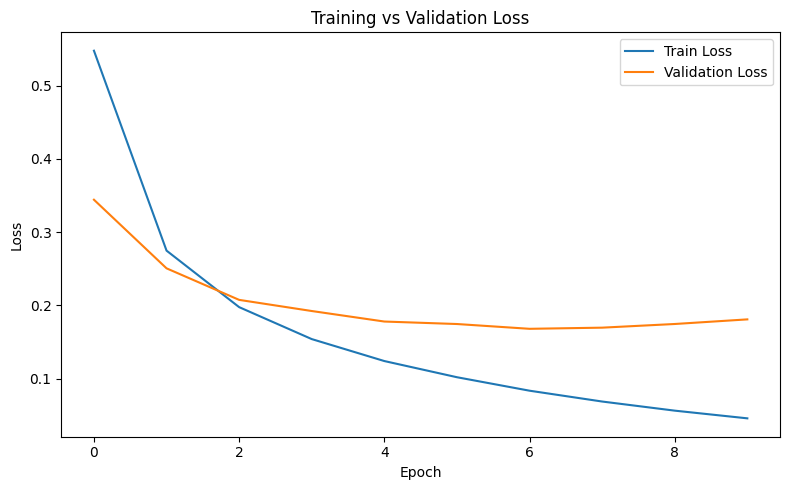

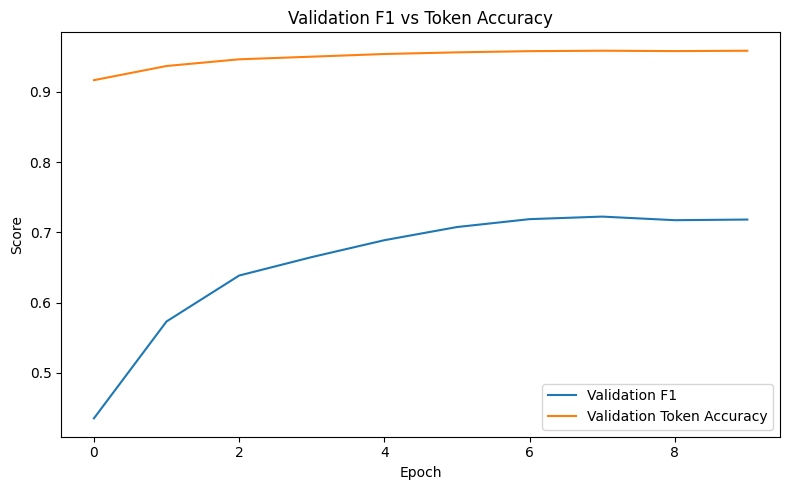

In [21]:
# TODO: Plot training curves
#
# Goal:
# - Visualize the training dynamics using the "history" dictionary.
#
# Minimum plots to include:
# 1) train_loss vs val_loss across epochs
# 2) val_f1 vs val_token_acc across epochs
#
# Plotting tips:
# - Label axes and include a legend.
# - Keep plots readable (reasonable figure size, clear labels).
# - Optionally mark the best epoch (based on val_f1).

epochs = np.arange(len(history["train_loss"]))
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["val_f1"], label="Validation F1")
plt.plot(epochs, history["val_token_acc"], label="Validation Token Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation F1 vs Token Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

## Inspect Token-Level Predictions (TODO)
Numbers (F1/precision/recall) tell us *how good* a model is overall, but not *how it fails*. Here we inspect a few sequences by hand to see typical error patterns (boundary mistakes, type confusions, and “O”-dominance effects) before moving on to more complex architectures.


In [22]:
# TODO: Qualitative inspection of predictions (human-readable)
#
# Goal:
# - Take a small batch (typically from validation)
# - Run the model to get per-token predictions
# - Print a readable comparison of:
#     token | gold tag | predicted tag
#
# Requirements:
# - Stop at padding (labels == cfg.ignore_index), so we don't print padded tokens.
# - Show at least a few examples (e.g., 3 sequences).
#
# Suggestions (optional):
# - Highlight mismatches (e.g., print "OK?" column or only print errors).
# - Add a max_tokens cap to keep the output short.
#
# You may implement helper functions like:
# - predict_batch(model, batch) -> list of per-sequence token/tag triples
# - pretty_print_ner(triples) -> prints a neat table

@torch.no_grad()
def predict_batch(model, batch):
    model.eval()

    input_ids = batch["input_ids"].to(device)
    labels = batch["labels"].to(device)
    lengths = batch["lengths"].to(device)

    logits = model(input_ids, lengths)
    preds = logits.argmax(-1)

    input_ids = input_ids.cpu()
    labels = labels.cpu()
    preds = preds.cpu()

    results = []

    for i in range(input_ids.size(0)):
        seq = []
        for j in range(input_ids.size(1)):
            if labels[i, j].item() == cfg.ignore_index:
                break  # stop at padding

            token_id = input_ids[i, j].item()
            gold_id = labels[i, j].item()
            pred_id = preds[i, j].item()

            token = itos[token_id]
            gold_tag = id2label[gold_id]
            pred_tag = id2label[pred_id]

            seq.append((token, gold_tag, pred_tag))

        results.append(seq)

    return results

def pretty_print_ner(seqs, max_sequences=3, max_tokens=40):
    for i, seq in enumerate(seqs[:max_sequences]):
        print(f"\n=== Example {i+1} ===")
        print(f"{'TOKEN':20s} {'TRUE':15s} {'PRED':15s} {'OK?'}")
        print("-" * 60)

        for token, gold, pred in seq[:max_tokens]:
            ok = "Yes" if gold == pred else "No"
            print(f"{token:20s} {gold:15s} {pred:15s} {ok}")

        if len(seq) > max_tokens:
            print("... (truncated)")

batch = next(iter(valid_loader))
seqs = predict_batch(model, batch)
pretty_print_ner(seqs, max_sequences=3)


=== Example 1 ===
TOKEN                TRUE            PRED            OK?
------------------------------------------------------------
A                    O               O               Yes
Russian              B-NORP          B-NORP          Yes
<unk>                O               O               Yes
has                  O               O               Yes
found                O               O               Yes
the                  O               O               Yes
bodies               O               O               Yes
of                   O               O               Yes
three                B-CARDINAL      B-CARDINAL      Yes
of                   O               O               Yes
the                  O               O               Yes
118                  B-CARDINAL      B-NORP          No
sailors              O               O               Yes
who                  O               O               Yes
were                 O               O               Yes
killed   

## Test-Set Evaluation
Here we run a single final evaluation on the held-out test split and report loss, token accuracy, and entity-level precision/recall/F1. This is the number we will compare against later parts (under similar training and evaluation conditions).

In [23]:
# Final evaluation on the held-out test set
test_metrics = evaluate(model, test_loader)

print(
    f"TEST | loss={test_metrics['loss']:.4f} | "
    f"token_acc={test_metrics['token_acc']:.4f} | "
    f"P={test_metrics['precision']:.4f} | "
    f"R={test_metrics['recall']:.4f} | "
    f"F1={test_metrics['f1']:.4f}"
)

TEST | loss=0.1637 | token_acc=0.9595 | P=0.7372 | R=0.7175 | F1=0.7272


## Concept Checks (answer in Markdown, no code)

### Q1 — Why BiLSTM for NER?
What does bidirectionality buy us in NER specifically?  
Explain what information the forward LSTM and backward LSTM each contribute.

**My Answer**: Named Entity Recognition is context-dependent. A token’s label often depends on words both before and after it. A BiLSTM runs a forward LSTM (left → right) and a backward LSTM (right → left), each token representation is the concatenation of both hidden states.

### Q2 — Padding and “ignore_index”
Why must we ignore padded positions when computing the loss?  
What would go wrong (in optimization and metrics) if we treated padding like a real label?

**My naswer**: If we include them in the loss the model would be trained to predict something for padding tokens. Since padding is extremely frequent (every batch), the model could learn to predict a dominant label on padded positions, waste capacity modeling meaningless data and bias gradients toward padding behavior. Also If padded positions are counted token accuracy becomes artificially inflated and model appears better than it is.

### Q3 — Token accuracy vs. entity F1
We will print both token accuracy and entity-level F1.  
Give one concrete reason token accuracy can look “good” even when the model is poor at entities.

**My Answer**: NER datasets are extremely imbalanced. Typically 85–90% of tokens are "O" and a trivial model that predicts "O" everywhere can achieve ~85–90% token accuracy but it detects zero entities and entity-level F1 would be 0.0. To get entity-level credit, the model must predict the correct boundary, predict the correct type, predict the entire span and partial matches do NOT count.

# Part 2 — Add Self-Attention on Top of the BiLSTM

In Part 1, we used a strong sequential baseline (BiLSTM) that naturally encodes left-to-right and right-to-left context.  
In this part, we keep that **sequence-aware backbone**, but we add a **single self-attention block** on top of the BiLSTM outputs.

The point of this design is very specific:

- The **BiLSTM** already injects order and local sequential structure.
- The **self-attention layer** then provides a direct mechanism for **global token-to-token mixing**.
- Because we did *not* remove the BiLSTM, we can test whether attention helps *beyond* what a strong sequential encoder already learns.

Conceptually, we compute queries, keys, and values from the BiLSTM features $X$, then build attention weights and mix values:

$$
Q = XW_Q,\quad K = XW_K,\quad V = XW_V
$$

$$
A = \operatorname{softmax}\!\left(\frac{QK^{\mathsf T}}{\sqrt{d}} + M\right)
$$

$$
\text{out} = AV
$$

where $M$ is a masking term that prevents padding tokens from being attended to.

At the end, we still do token classification as before, and we evaluate with the **same exact metrics** (token accuracy + entity-level precision/recall/F1).  
That consistency makes Part 2 a clean ablation against Part 1.

### What we should pay attention to in this part

- **Does attention improve entity-level F1** compared to the BiLSTM baseline?
- **Does it help more for certain entity types** (longer spans, rarer types, or boundary-sensitive cases)?
- **How sensitive is it to masking and dropout**, since attention can exploit artifacts if masking is wrong?
- **What do the attention maps look like**, and do they show patterns that are at least plausibly meaningful?

## Single-Head Self-Attention (Core Mechanism)

In this cell, we implement **single-head self-attention**: each token computes a weighted mixture of all other tokens using the $QK^\top$ similarity matrix.  
The key detail is **padding-aware masking**: padded tokens must not be attended to, or the model will learn misleading interactions.

In [24]:
# TODO: Implement a single-head self-attention module.
#
# Requirements (do NOT hardcode shapes):
# - Input: x of shape [B, T, D] where D = d_model
# - Learnable projections: Q = xWq, K = xWk, V = xWv
# - Attention scores: scores = (Q K^T) / sqrt(D)
# - Masking:
#     attention_mask is [B, T] with 1 for real tokens and 0 for padding.
#     We must prevent attending *to padding keys* by setting masked scores to a large negative value.
# - Softmax over the last dimension to get attention weights A: [B, T, T]
# - Output: y = A V projected back to [B, T, D]
#
# Output behavior:
# - If return_attn=True, return (y, attn_weights)
# - Otherwise return y only.
#
# Notes:
# - Be careful about broadcasting the mask to match [B, T, T].
# - Use numerically stable masking (large negative score before softmax).
# - Add dropout on attention weights (optional but recommended).
#
# You are free to structure the code differently (e.g., combine projections, store parameters differently, etc.)
# as long as the behavior matches the requirements.

class SingleHeadSelfAttention(nn.Module):
    def __init__(self, d_model: int, dropout: float = 0.1):
        super().__init__()
        self.d_model = d_model
        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, attention_mask: torch.Tensor = None, return_attn: bool = False):
            B, T, D = x.shape

            Q = self.Wq(x)  # [B, T, D]
            K = self.Wk(x)  # [B, T, D]
            V = self.Wv(x)  # [B, T, D]
            scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(D) # [B, T, T]

            if attention_mask is not None:
                key_mask = attention_mask.unsqueeze(1)  # [B, 1, T]
                scores = scores.masked_fill(key_mask == 0, -1e9)

            attn_weights = F.softmax(scores, dim=-1)  # [B, T, T]
            attn_weights = self.dropout(attn_weights)
            y = torch.matmul(attn_weights, V)  # [B, T, D]
            y = self.out_proj(y)  # [B, T, D]

            if return_attn:
                return y, attn_weights
            return y

## Single-Head Transformer Block (Residual + LayerNorm + FFN)

We now wrap single-head self-attention into a **Transformer-style block** by adding:  
1) a residual path + normalization around attention, and  
2) a position-wise **feed-forward network (FFN)** with another residual + normalization.

This gives us the smallest “Transformer brick” we can plug into an NER model without introducing multi-head attention yet.

In [25]:
# TODO: Implement a minimal Transformer-style block (single-head version).
#
# Requirements (keep it simple and readable):
# - Use the provided SingleHeadSelfAttention module.
# - Add a residual connection around attention.
# - Apply LayerNorm in a consistent way (choose a pattern and document it):
#     * Post-LN (as written in many classic tutorials), or
#     * Pre-LN (often used for stability in deeper stacks).
# - Add a position-wise feed-forward network (FFN), then another residual + normalization.
# - Support an `attention_mask` so padding tokens are handled correctly.
# - If `return_attn=True`, return both (output, attention_weights).
#
# Notes:
# - Keep tensor shapes consistent: input/output should both be [B, T, d_model].
# - Avoid changing the external API: forward(x, attention_mask=None, return_attn=False).
#
# After implementing, we will plug this block into an NER tagger and compare to Part 1.

class SingleHeadTransformerBlock(nn.Module):
    def __init__(self, d_model: int, dropout: float = 0.2, ff_mult: int = 4):
        super().__init__()
        self.attn = SingleHeadSelfAttention(d_model, dropout=dropout)
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(nn.Linear(d_model, ff_mult * d_model), nn.ReLU(), nn.Dropout(dropout), nn.Linear(ff_mult * d_model, d_model))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, attention_mask=None, return_attn=False):
        residual = x
        x_norm = self.ln1(x)
        attn_out, attn_weights = self.attn(x_norm, attention_mask=attention_mask, return_attn=True)
        x = residual + self.dropout(attn_out)

        residual = x
        x_norm = self.ln2(x)
        ffn_out = self.ffn(x_norm)
        x = residual + self.dropout(ffn_out)

        if return_attn:
            return x, attn_weights
        return x

## Hybrid Tagger: BiLSTM Encoder + Single-Head Attention Block

In this section, we combine a **sequence-aware BiLSTM** (strong classical baseline) with a **single-head Transformer block** on top.

The goal is to isolate one idea:  
**What changes when we add a global mixing mechanism (self-attention) after a sequential encoder?**

We will keep the training/evaluation protocol consistent with Part 1, so any gains or failures can be attributed to this architectural change—not to changes in the experiment setup.

In [26]:
# TODO: Implement a hybrid NER tagger that combines:
#   (1) word embeddings
#   (2) a BiLSTM encoder (sequence-aware baseline feature extractor)
#   (3) a projection into a "model dimension" d_model
#   (4) ONE Transformer-style block (single-head attention + FFN)
#   (5) a token-level classifier over NER labels
#
# Requirements:
# - Input: input_ids [B, T], lengths [B], attention_mask [B, T] (1 real, 0 pad)
# - Output: logits [B, T, num_labels]
# - Use packing/unpacking for the LSTM so padded tokens do not waste compute.
# - Include dropout in reasonable places (embedding / between modules / before classifier).
# - If return_attn=True: return (logits, attn_weights) so we can visualize attention later.
#
# Design freedom (choose and document your choices):
# - Where to apply dropout (embedding output, LSTM output, after attention block, etc.)
# - Whether to apply projection before/after LSTM (but keep shapes consistent)
# - Whether to share dropout modules or use separate ones
#
# NOTE:
# - Keep tensor shapes consistent: logits must align with padded batch length T.
# - attention_mask should be forwarded into the Transformer block.

class BiLSTMTransformerTagger(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        num_labels: int,
        pad_id: int,
        emb_dim: int = 128,
        lstm_hidden: int = 192,
        d_model: int = 192,
        lstm_layers: int = 1,
        dropout: float = 0.4,
    ):
        super().__init__()
        self.pad_id = pad_id
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)
        self.emb_dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(input_size=emb_dim, hidden_size=lstm_hidden, num_layers=lstm_layers, batch_first=True, bidirectional=True)
        self.lstm_dropout = nn.Dropout(dropout)
        self.proj = nn.Linear(2 * lstm_hidden, d_model)
        self.transformer = SingleHeadTransformerBlock(d_model=d_model, dropout=dropout)
        self.classifier_dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, num_labels)

    def forward(self, input_ids, lengths, attention_mask=None, return_attn=False):
        x = self.embedding(input_ids)  # [B, T, emb_dim]
        x = self.emb_dropout(x)
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed)
        x, _ = pad_packed_sequence(packed_out, batch_first=True, total_length=input_ids.size(1))  # [B, T, 2*lstm_hidden]
        x = self.lstm_dropout(x)
        x = self.proj(x)  # [B, T, d_model]
        x, attn_weights = self.transformer(x, attention_mask=attention_mask, return_attn=True)
        x = self.classifier_dropout(x)
        logits = self.classifier(x)  # [B, T, num_labels]

        if return_attn:
            return logits, attn_weights
        return logits

## Loss on Real Tokens Only (Mask-Aware)

In token classification, sequences are padded to a common length.  
Here we define the loss so that **padding does not contribute** (using `ignore_index`) and we can report loss **normalized by the number of real tokens**.

In [27]:
def loss_sum_and_tokens(logits: torch.Tensor, labels: torch.Tensor):
    """
    logits: [B, T, C], labels: [B, T]
    returns: (loss_sum over real tokens, num_real_tokens)
    """
    B, T, C = logits.shape
    loss_sum = F.cross_entropy(
        logits.view(B * T, C),
        labels.view(B * T),
        ignore_index=cfg.ignore_index,
        reduction="sum",
    )
    n_tokens = (labels != cfg.ignore_index).sum().item()
    return loss_sum, n_tokens


def loss_mean(logits: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
    loss_sum, n_tokens = loss_sum_and_tokens(logits, labels)
    return loss_sum / max(n_tokens, 1)

## Training & Evaluation Loops (Attention-Aware)

With this cell we can practice writing a clean training loop and a fair evaluation loop.  
The key requirement is **mask correctness**: padding must not affect loss or metrics, and attention must respect the `attention_mask`.

In [28]:
def train_one_epoch_attn(model, loader, optimizer, grad_clip: float = 1.0):
    """
    One training epoch for models that use an attention mask.
    We expect each batch to contain:
      - input_ids, labels, lengths, attention_mask
    """
    # TODO:
    model.train()
    total_loss_sum = 0.0
    total_tokens = 0
    for batch in tqdm(loader, leave=False):
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        lengths = batch["lengths"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        optimizer.zero_grad()
        logits = model(input_ids, lengths, attention_mask=attention_mask) # [B, T, C]
        loss = loss_mean(logits, labels)
        loss.backward()
        if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        loss_sum, n_tokens = loss_sum_and_tokens(logits, labels)
        total_loss_sum += loss_sum.item()
        total_tokens += n_tokens
    return total_loss_sum / total_tokens if total_tokens > 0 else 0.0

@torch.no_grad()
def evaluate_attn(model, loader):
    """
    Evaluation for models that use an attention mask.
    Returns:
      - loss per real token
      - token accuracy (excluding padding)
      - entity-level precision/recall/F1 (seqeval) computed from decoded tag sequences
    """
    model.eval()
    total_loss_sum = 0.0
    total_tokens = 0
    total_correct = 0
    y_true_all = []
    y_pred_all = []

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        lengths = batch["lengths"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        logits = model(input_ids, lengths, attention_mask=attention_mask)
        preds = logits.argmax(-1)
        loss_sum, n_tokens = loss_sum_and_tokens(logits, labels)
        total_loss_sum += loss_sum.item()
        total_tokens += n_tokens
        mask = labels != cfg.ignore_index
        total_correct += ((preds == labels) & mask).sum().item()
        y_true, y_pred = ids_to_tags(labels.cpu(), preds.cpu())
        y_true_all.extend(y_true)
        y_pred_all.extend(y_pred)

    mean_loss = total_loss_sum / total_tokens if total_tokens > 0 else 0.0
    token_acc = total_correct / total_tokens if total_tokens > 0 else 0.0

    precision = precision_score(y_true_all, y_pred_all)
    recall = recall_score(y_true_all, y_pred_all)
    f1 = f1_score(y_true_all, y_pred_all)

    return {
        "loss": mean_loss,
        "token_acc": token_acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

## Initialize the Part 2 Model (BiLSTM + Single-Head Attention)

In this cell we define the **Part 2 model instance** and choose its main capacity knobs (embedding size, hidden size, attention dimension, dropout, etc.).  
We keep the **input/output interface** fixed so evaluation stays comparable, but we leave the architectural choices to you.

In [29]:
# TODO: Instantiate your Part 2 model.
#
# Requirements / contract:
# - The model must accept (input_ids, lengths, attention_mask=...) in forward()
# - It must return logits of shape [B, T, num_labels]
# - It must run on `device` (CPU or GPU)
#
# Flexibility:
# - You may change embedding size, hidden sizes, d_model, dropout, number of LSTM layers, etc.
# - You may replace BiLSTMTransformerTagger with your own architecture as long as the interface matches.
#
# Tip:
# - Keep cfg.num_workers = 0 in notebook environments where multiprocessing is unstable.

cfg.num_workers = 0
attn_model = BiLSTMTransformerTagger(
    vocab_size=len(stoi),
    num_labels=len(label2id),
    pad_id=stoi[cfg.pad_token],
    emb_dim=128,
    lstm_hidden=192,
    d_model=192,
    lstm_layers=1,
    dropout=0.4,
)

attn_model = attn_model.to(device)

## Train Part 2 and Early-Stop on Validation F1

In this cell we train the **BiLSTM + single-head attention** tagger under a controlled setup.  
We track both optimization signals (loss) and NER signals (entity-level precision/recall/F1), and we **keep the best model** according to validation performance (typically **entity-level F1**).

In [30]:
# TODO: Train the Part 2 model and keep the best checkpoint.
#
# Requirements / contract:
# - Create an optimizer for `attn_model.parameters()`
# - Train for multiple epochs using your training function (e.g., train_one_epoch_attn)
# - Evaluate on `valid_loader` each epoch (e.g., evaluate_attn)
# - Track a history dict for plotting (at least train_loss, val_loss, val_token_acc, val_f1)
# - Implement early stopping based on validation F1 (recommended) OR justify your choice
# - Save the best model state_dict in memory and reload it at the end
#
# Flexibility:
# - You may change optimizer type, lr, weight_decay, grad clipping, epochs, patience
# - You may add LR schedulers, mixed precision, gradient accumulation, etc.
# - You may change the early-stopping metric (but keep reporting entity-level F1)
#
# Hint:
# - Store `best_state = {k: v.detach().cpu().clone() ...}` to avoid GPU memory issues.

optimizer = torch.optim.AdamW(attn_model.parameters(), lr=3e-4, weight_decay=0.01)
EPOCHS = 10
patience = 5
grad_clip = 1.0
best_f1 = -1.0
best_state = None
bad_epochs = 0
history2 = {
    "train_loss": [],
    "val_loss": [],
    "val_token_acc": [],
    "val_f1": [],
}

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch_attn(attn_model, train_loader, optimizer, grad_clip=grad_clip)
    val_metrics = evaluate_attn(attn_model, valid_loader)

    history2["train_loss"].append(train_loss)
    history2["val_loss"].append(val_metrics["loss"])
    history2["val_token_acc"].append(val_metrics["token_acc"])
    history2["val_f1"].append(val_metrics["f1"])

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_acc={val_metrics['token_acc']:.4f} | "
        f"val_P={val_metrics['precision']:.4f} | "
        f"val_R={val_metrics['recall']:.4f} | "
        f"val_F1={val_metrics['f1']:.4f}"
    )

    current_f1 = val_metrics["f1"]
    if current_f1 > best_f1 + 1e-5:
        best_f1 = current_f1
        bad_epochs = 0
        best_state = {k: v.detach().cpu().clone() for k, v in attn_model.state_dict().items()}
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            break

attn_model.load_state_dict(best_state)
attn_model = attn_model.to(device)
print(f"\nLoaded best attention model with val_F1 = {best_f1:.4f}")

  0%|          | 0/1873 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.5975 | val_loss=0.3789 | val_acc=0.9080 | val_P=0.4647 | val_R=0.3545 | val_F1=0.4022


  0%|          | 0/1873 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.4152 | val_loss=0.2984 | val_acc=0.9246 | val_P=0.5838 | val_R=0.4526 | val_F1=0.5099


  0%|          | 0/1873 [00:00<?, ?it/s]

...

Epoch 08 | train_loss=0.2170 | val_loss=0.1886 | val_acc=0.9497 | val_P=0.7049 | val_R=0.6527 | val_F1=0.6778


  0%|          | 0/1873 [00:00<?, ?it/s]

Epoch 09 | train_loss=0.2025 | val_loss=0.1791 | val_acc=0.9526 | val_P=0.7187 | val_R=0.6693 | val_F1=0.6931


  0%|          | 0/1873 [00:00<?, ?it/s]

Epoch 10 | train_loss=0.1916 | val_loss=0.1744 | val_acc=0.9533 | val_P=0.7209 | val_R=0.6766 | val_F1=0.6980

Loaded best attention model with val_F1 = 0.6980


## Visualize Training Curves (Part 2)

We plot how the model evolves over epochs.  
Loss curves help diagnose optimization and overfitting, while **entity-level F1** is the key signal for NER quality (token accuracy is only a secondary diagnostic).

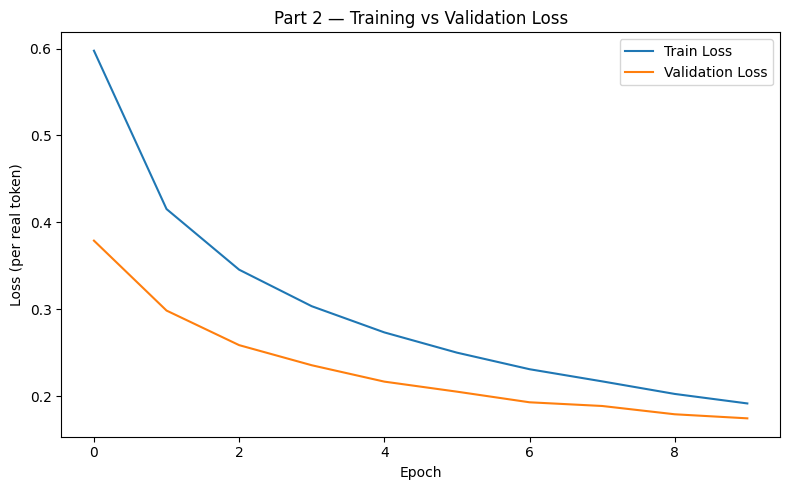

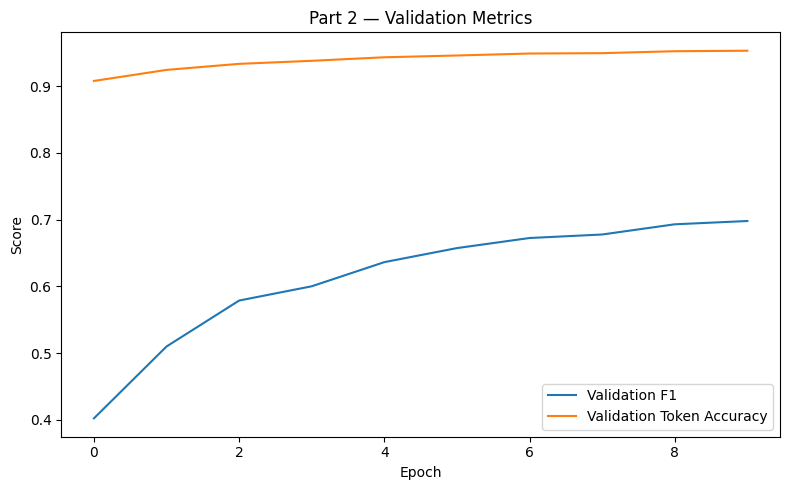

In [31]:
# TODO: Plot training dynamics for Part 2.
#
# Minimum expectations:
# - Plot loss curves across epochs (train_loss and val_loss)
# - Plot metric curves across epochs (at least val_f1 and val_token_acc)
#
# Notes:
# - Use `history2` as the source of curves.
# - Keep plots readable: axis labels, legend, and a clear title are recommended.
# - Optional: add grid, save figures, smooth curves, or plot P/R as well.

epochs = range(len(history2["train_loss"]))
plt.figure(figsize=(8, 5))
plt.plot(epochs, history2["train_loss"], label="Train Loss")
plt.plot(epochs, history2["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (per real token)")
plt.title("Part 2 — Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history2["val_f1"], label="Validation F1")
plt.plot(epochs, history2["val_token_acc"], label="Validation Token Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Part 2 — Validation Metrics")
plt.legend()
plt.tight_layout()
plt.show()

## Test Evaluation and Quick Baseline Comparison (Part 2)

We evaluate the attention-augmented model on the **held-out test set** and report the full NER metric suite.  
If Part 1 results are available, we also print a short comparison—primarily focusing on **entity-level F1** to judge whether attention improves span-level predictions.

In [32]:
# TODO: Evaluate the Part 2 attention-augmented model on the **test set**.
#
# Minimum expectations:
# 1) Run evaluation on `test_loader` using your Part 2 evaluation function (e.g., `evaluate_attn`).
# 2) Print a clean summary including: loss, token_acc, precision, recall, F1.
#
# Optional (recommended):
# - If Part 1 test metrics exist (e.g., `test_metrics` from the BiLSTM baseline),
#   print a short comparison focused on **entity-level F1**.
# - Store results in a dict (e.g., `attn_test`) for later summary tables.

test_metrics2 = evaluate_attn(attn_model, test_loader)

print(
    f"ATTN TEST | "
    f"loss={test_metrics2['loss']:.4f} | "
    f"token_acc={test_metrics2['token_acc']:.4f} | "
    f"P={test_metrics2['precision']:.4f} | "
    f"R={test_metrics2['recall']:.4f} | "
    f"F1={test_metrics2['f1']:.4f}"
)

print("\n--- Comparison vs Part 1 (BiLSTM) ---")
print(f"BiLSTM TEST F1: {test_metrics['f1']:.4f}")
print(f"Attn  TEST F1: {test_metrics2['f1']:.4f}")

ATTN TEST | loss=0.1684 | token_acc=0.9555 | P=0.7374 | R=0.6892 | F1=0.7125

--- Comparison vs Part 1 (BiLSTM) ---
BiLSTM TEST F1: 0.7272
Attn  TEST F1: 0.7125


## Attention Map Visualization on a Single Sentence (Part 2)

We take one validation sentence, run the attention-augmented model in a mode that returns **attention weights**, and visualize the resulting **token-to-token attention matrix**.  
This helps us inspect (qualitatively) which tokens attend to which others—while remembering that attention is not a guaranteed explanation, just a useful signal to explore.

Tokens:
['A', 'Russian', '<unk>', 'has', 'found', 'the', 'bodies', 'of', 'three', 'of', 'the', '118', 'sailors', 'who', 'were', 'killed', 'when', 'the', 'nuclear', 'submarine', 'Kursk', '<unk>', 'in', 'the', 'Barents', 'Sea', '.']

Pred  :
['O', 'B-NORP', 'O', 'O', 'O', 'O', 'O', 'O', 'B-CARDINAL', 'O', 'O', 'B-NORP', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-PRODUCT', 'O', 'O', 'B-LOC', 'I-LOC', 'I-LOC', 'O']




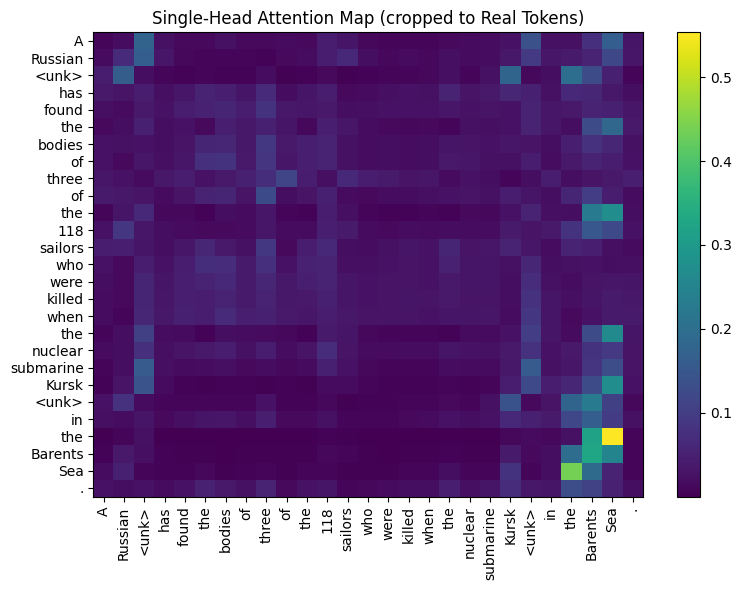

In [33]:
# TODO: Build a **single-example batch** and visualize the model's attention map.
#
# Goals:
# 1) Create a batch of size 1 (compatible with our `ner_collate_fn`) from a chosen split + index.
# 2) Move tensors to `device` and run the attention model in a mode that **returns attention weights**.
# 3) Decode predictions for the real (unpadded) tokens and print:
#    - tokens
#    - predicted tags
# 4) Extract the attention matrix and **crop it to the true length** L (no padding).
# 5) Plot a heatmap of attention weights with token labels on both axes.
#
# Notes:
# - The returned attention should be shaped like [B, T, T] (for single-head).
# - Make sure we visualize only the non-pad region: [:L, :L].
# - Keep the plot readable: rotate x tick labels, call tight_layout, etc.

example = valid_ds[0]
single_batch = ner_collate_fn([example])
input_ids = single_batch["input_ids"].to(device)
labels = single_batch["labels"].to(device)
lengths = single_batch["lengths"].to(device)
attention_mask = single_batch["attention_mask"].to(device)

attn_model.eval()
with torch.no_grad():
    logits, attn_weights = attn_model(input_ids, lengths, attention_mask=attention_mask, return_attn=True)

preds = logits.argmax(-1).cpu()
labels = labels.cpu()
input_ids = input_ids.cpu()
attn_weights = attn_weights.cpu()
L = lengths.item()
tokens = [itos[input_ids[0, i].item()] for i in range(L)]
pred_tags = [id2label[preds[0, i].item()] for i in range(L)]

print("Tokens:")
print(tokens)
print("\nPred  :")
print(pred_tags)
print("\n")

attn_matrix = attn_weights[0, :L, :L]  # [L, L]

plt.figure(figsize=(8, 6))
plt.imshow(attn_matrix, aspect="auto")
plt.colorbar()

plt.xticks(range(L), tokens, rotation=90)
plt.yticks(range(L), tokens)

plt.title("Single-Head Attention Map (cropped to Real Tokens)")
plt.tight_layout()
plt.show()

## Concept Checks (answer in Markdown, no code)

1. **Why is “BiLSTM + attention” a cleaner experiment than “attention-only” at this stage?**  
   What capability does the BiLSTM provide that attention alone does not automatically guarantee?

   **My Answer**: Because the BiLSTM already injects sequential, order-aware context, we can isolate the effect of attention. In an attention-only model, any failures could be due to missing sequential structure, making it harder to judge whether attention actually helps.

2. In the attention formula, we scale by $\sqrt{d}$.  
   **What numerical issue is this scaling trying to reduce?**  
   (Explain intuitively, not with a proof.)

   **My Answer**: Scaling by $\sqrt{d}$ prevents the dot products from becoming too large when the dimensionality is high, which could push the softmax into extremely small gradients (saturation). It keeps attention scores in a numerically stable range for learning.

3. Self-attention produces a matrix $A \in \mathbb{R}^{T \times T}$ (per example).  
   **What do rows and columns represent in that matrix?**  
   If token $i$ strongly attends to token $j$, what does that mean operationally?

   **My Answer**: Rows are queries (tokens asking “where should I attend?”), Columns are keys (tokens being attended to) and Entry A[i, j] shows how much token i attends to token j.

4. Suppose Part 2 improves token accuracy but barely changes entity-level F1.  
   **Give one realistic reason this could happen in NER.**

   **My Answer**: This can happen if the model mostly predicts “O” correctly, which dominates token counts, but fails on actual entity spans—missing boundaries or mislabeling entity types. High token accuracy can be misleading in label-imbalanced NER tasks.

# Part 3 — Attention-Only Tagger (No Positional Encoding)

In this part we intentionally **remove the sequential encoder** (BiLSTM) and try to solve NER using **self-attention only**.  
This is a controlled stress test: attention is excellent at mixing information across tokens, but **order is not “built in”** unless we explicitly provide it.

We keep the experimental setup as consistent as possible (same dataset, same evaluation metrics, same masking rules), and we focus on one central question:

> **What breaks when we remove sequence awareness, and why?**

We will:
- implement an attention-only encoder block (self-attention + feed-forward + layer norm + residuals),
- train it on NER,
- evaluate it with **entity-level precision/recall/F1** (not just token accuracy),
- and run interpretability/diagnostic checks that probe whether the model understands token order.

## Single-Head Self-Attention (Core Module)

In this cell we implement the fundamental attention mechanism used throughout the Transformer family.  
We will compute attention scores, apply optional scaling for stability, correctly mask padded tokens, and return either the transformed sequence or (optionally) the attention weight matrix for visualization.

In [34]:
class SingleHeadSelfAttention(nn.Module):
    """
    Single-head self-attention module.

    Expected behavior:
      - Input:  x            [B, T, D]
      - Mask:   attention_mask [B, T] with 1 for real tokens, 0 for padding
      - Output: y            [B, T, D]
      - Optional: return attention weights attn [B, T, T] if return_attn=True

    Notes:
      - "Masking keys" means padded token positions must NOT be attended to.
      - If use_scaling=True, scale attention scores by sqrt(D) for stability.
    """
    def __init__(self, d_model: int, dropout: float = 0.1, use_scaling: bool = True):
        super().__init__()
        self.d_model = d_model
        self.use_scaling = use_scaling
        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        x: torch.Tensor,
        attention_mask: torch.Tensor = None,
        return_attn: bool = False,
    ):
        B, T, D = x.size()
        Q = self.q(x)  # [B, T, D]
        K = self.k(x)  # [B, T, D]
        V = self.v(x)  # [B, T, D]
        scores = Q @ K.transpose(-2, -1)  # [B, T, T]
        if self.use_scaling: scores /= math.sqrt(D)
        if attention_mask is not None:
            key_mask = (attention_mask == 0).unsqueeze(1)  # [B, 1, T]
            scores = scores.masked_fill(key_mask, -1e9)
        attn = F.softmax(scores, dim=-1)  # [B, T, T]
        attn = self.dropout(attn)
        y = torch.matmul(attn, V)  # [B, T, D]
        y = self.out(y) # [B, T, D]
        if return_attn:
            return y, attn
        else:
            return y

## Attention-Only Tagger Skeleton

In this cell we define an **attention-only** NER model: it must map token IDs to per-token label logits while handling padding correctly.  
We keep the design intentionally open-ended so we can later study how “attention without order information” behaves under different reasonable implementations.

In [35]:
class AttentionOnlyTagger(nn.Module):
    """
    Attention-only sequence tagger (no RNN/CNN).

    Required behavior:
      - Inputs:
          input_ids:       [B, T]
          attention_mask:  [B, T] with 1 for real tokens and 0 for padding (may be None)
      - Output:
          logits:          [B, T, num_labels]
      - Optional:
          if return_attn=True, also return attention weights with shape [B, T, T]
            (weights should correspond to how each query position distributes mass over key positions)

    Notes:
      - Padding tokens must not affect the model's computations for real tokens.
      - Keep shapes consistent across the notebook so comparisons are fair.
    """
    def __init__(
        self,
        vocab_size: int,
        num_labels: int,
        pad_id: int,
        d_model: int = 128,
        dropout: float = 0.2,
        use_scaling: bool = True,
    ):
        super().__init__()
        self.pad_id = pad_id
        self.num_labels = num_labels
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.emb_dropout = nn.Dropout(dropout)
        self.attn_block = SingleHeadSelfAttention(d_model=d_model, dropout=dropout, use_scaling=use_scaling)
        self.ffn = nn.Sequential(nn.Linear(d_model, d_model), nn.ReLU(), nn.Dropout(dropout), nn.Linear(d_model, d_model))
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model, num_labels)
        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.embedding.weight)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor = None,
        return_attn: bool = False,
    ):
        x = self.embedding(input_ids)  # [B, T, D]
        x = self.emb_dropout(x)
        attn_out, attn_weights = self.attn_block(x, attention_mask=attention_mask, return_attn=True)
        x = self.ln1(x + attn_out)
        ff_out = self.ffn(x)
        x = self.ln2(x + ff_out)
        logits = self.classifier(x)  # [B, T, num_labels]
        if return_attn:
            return logits, attn_weights
        else:
            return logits

## Evaluation for Attention-Based Taggers

We define a dedicated evaluation function for attention-based NER models.  
The key requirement is **fairness**: we must compute **exactly the same metrics** as earlier parts (especially entity-level F1) while correctly ignoring padded tokens.

In [36]:
@torch.no_grad()
def evaluate_attn(model, loader):
    """
    Evaluate an attention-based tagger.

    Requirements:
      - model outputs logits of shape [B, T, num_labels]
      - ignore padded positions using cfg.ignore_index
      - return a dict with at least: loss, token_acc, precision, recall, f1
      - use the same entity-level metrics (seqeval) as Part 0/1 for fair comparison

    Tips:
      - Keep this function comparable to Part 1's evaluate() so we can isolate the effect of architecture,
        not evaluation differences.
      - Decide whether to compute metrics per-batch then aggregate, or collect all sequences and compute once.
    """
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    y_true_all = []
    y_pred_all = []

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        lengths = batch["lengths"].to(device)
        logits = model(input_ids, attention_mask=attention_mask)  # [B, T, num_labels]
        preds = logits.argmax(dim=-1)
        loss_sum, n_tokens = loss_sum_and_tokens(logits, labels)
        total_loss += loss_sum
        total_tokens += n_tokens
        batch_true, batch_pred = ids_to_tags(labels, preds)
        y_true_all.extend(batch_true)
        y_pred_all.extend(batch_pred)

    mean_loss = total_loss / total_tokens
    all_labels = torch.cat([b["labels"].view(-1) for b in loader], dim=0).to(device)
    all_preds = torch.cat([model(b["input_ids"].to(device), attention_mask=b["attention_mask"].to(device))
                           .argmax(-1).view(-1) for b in loader], dim=0)
    token_acc = compute_token_accuracy(all_labels, all_preds)

    precision = precision_score(y_true_all, y_pred_all)
    recall = recall_score(y_true_all, y_pred_all)
    f1 = f1_score(y_true_all, y_pred_all)

    return {
        "loss": mean_loss.item(),
        "token_acc": token_acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

## One-Epoch Training Loop for Attention Models

We implement a single-epoch training loop that mirrors earlier parts, but now passes an **attention mask** and enforces **padding-aware loss**.  
We keep the structure minimal so we can later compare different training choices without changing the rest of the notebook.

In [37]:
def train_one_epoch_attn(model, loader, optimizer, grad_clip: float = 1.0):
    """
    Train the model for one epoch.

    Requirements:
      - use attention_mask correctly (padding should not influence learning)
      - compute loss only over real tokens (ignore cfg.ignore_index)
      - update parameters with the provided optimizer
      - optionally apply gradient clipping for stability
      - return mean loss over real tokens (not over padded length)

    You are free to:
      - add mixed precision
      - add schedulers
      - change logging granularity
      - add gradient accumulation
    """
    model.train()
    total_loss = 0.0
    total_tokens = 0

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask=attention_mask)  # [B, T, num_labels]
        loss_sum, n_tokens = loss_sum_and_tokens(logits, labels)
        loss = loss_sum / n_tokens
        loss.backward()
        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        optimizer.step()
        total_loss += loss_sum.item()
        total_tokens += n_tokens

    mean_loss = total_loss / total_tokens
    return mean_loss

## Part 3 Setup: Attention-Only Model + Optimizer

We instantiate our **attention-only** NER tagger and choose an optimizer configuration.  
We keep this cell flexible on purpose so we can later study how architecture and optimization choices affect performance.

In [38]:
# TODO: Instantiate the Part 3 model (attention-only tagger) and its optimizer.

# Requirements:
# - Use the same `stoi`, `num_labels`, and `cfg.pad_token` as earlier parts.
# - Move the model to `device`.
# - Create an optimizer (e.g., AdamW) for model parameters.

pad_id = stoi[cfg.pad_token]
d_model = 192
dropout = 0.3

# TODO: Choose architecture hyperparameters (examples: d_model, dropout, scaling).
attn_model = AttentionOnlyTagger(
    vocab_size=len(stoi),
    num_labels=num_labels,
    pad_id=pad_id,
    d_model=d_model,
    dropout=dropout,
    use_scaling=True,
).to(device)

# TODO: Print the model (optional but useful for sanity checking).
print(attn_model)

# TODO: Choose optimizer + hyperparameters (lr, weight_decay, etc.)
optimizer = torch.optim.AdamW(attn_model.parameters(), lr=3e-4, weight_decay=1e-2)

AttentionOnlyTagger(
  (embedding): Embedding(23872, 192, padding_idx=0)
  (emb_dropout): Dropout(p=0.3, inplace=False)
  (attn_block): SingleHeadSelfAttention(
    (q): Linear(in_features=192, out_features=192, bias=True)
    (k): Linear(in_features=192, out_features=192, bias=True)
    (v): Linear(in_features=192, out_features=192, bias=True)
    (out): Linear(in_features=192, out_features=192, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (ffn): Sequential(
    (0): Linear(in_features=192, out_features=192, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=192, out_features=192, bias=True)
  )
  (ln1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
  (ln2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
  (classifier): Linear(in_features=192, out_features=37, bias=True)
)


## Part 3 Training: Validation-Selected Checkpointing

We train the attention-only model and select checkpoints using **validation entity-level F1**.  
The goal is to keep the training protocol comparable across parts, while still allowing experimentation with stopping rules and optimization details.

In [39]:
# TODO: Train the attention-only model with validation-based selection.

# Requirements:
# - Use `train_one_epoch_attn(...)` and `evaluate_attn(...)` from earlier cells.
# - Track training/validation curves in a `history` dict (for plotting later).
# - Save the best model based on validation entity-level F1 (recommended for NER).
# - Restore the best checkpoint at the end.

# TODO: Choose training budget + early stopping policy
EPOCHS = 10
patience = 5

# TODO: Initialize tracking variables
best_f1 = 0
best_state = None
bad_epochs = 0
history3 = {"train_loss": [], "val_loss": [], "val_token_acc": [], "val_f1": []}

# TODO: Main training loop
for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch_attn(attn_model, train_loader, optimizer)
    val_metrics = evaluate_attn(attn_model, valid_loader)

    history3["train_loss"].append(train_loss)
    history3["val_loss"].append(val_metrics['loss'])
    history3["val_token_acc"].append(val_metrics['token_acc'])
    history3["val_f1"].append(val_metrics['f1'])
    print(
            f"Epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"token_acc={val_metrics['token_acc']:.4f} | "
            f"P={val_metrics['precision']:.4f} | "
            f"R={val_metrics['recall']:.4f} | "
            f"F1={val_metrics['f1']:.4f}"
        )

    current_f1 = val_metrics['f1']
    if current_f1 > best_f1 + 1e-5:
        best_f1 = current_f1
        bad_epochs = 0
        best_state = {k: v.detach().cpu().clone() for k, v in attn_model.state_dict().items()}
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            break

# TODO: Restore best checkpoint
attn_model.load_state_dict(best_state)
print("Loaded best model with val_F1 =", best_f1)

Epoch 01 | train_loss=0.3038 | val_loss=0.2563 | token_acc=0.9319 | P=0.4873 | R=0.5493 | F1=0.5165
Epoch 02 | train_loss=0.1955 | val_loss=0.2428 | token_acc=0.9347 | P=0.4919 | R=0.5743 | F1=0.5299
Epoch 03 | train_loss=0.1701 | val_loss=0.2449 | token_acc=0.9356 | P=0.4984 | R=0.5880 | F1=0.5395
Epoch 04 | train_loss=0.1542 | val_loss=0.2495 | token_acc=0.9353 | P=0.4902 | R=0.5947 | F1=0.5374
Epoch 05 | train_loss=0.1439 | val_loss=0.2560 | token_acc=0.9363 | P=0.5001 | R=0.5933 | F1=0.5427
Epoch 06 | train_loss=0.1352 | val_loss=0.2591 | token_acc=0.9349 | P=0.4955 | R=0.6064 | F1=0.5454
Epoch 07 | train_loss=0.1297 | val_loss=0.2620 | token_acc=0.9359 | P=0.5017 | R=0.5884 | F1=0.5416
Epoch 08 | train_loss=0.1245 | val_loss=0.2728 | token_acc=0.9346 | P=0.4952 | R=0.6040 | F1=0.5442
Epoch 09 | train_loss=0.1201 | val_loss=0.2752 | token_acc=0.9351 | P=0.4960 | R=0.6007 | F1=0.5433
Epoch 10 | train_loss=0.1165 | val_loss=0.2833 | token_acc=0.9344 | P=0.4945 | R=0.5882 | F1=0.5373


## Training Curves for Part 3

We visualize optimization and generalization by plotting **loss** (train vs validation) and **validation metrics** (entity-level F1 vs token accuracy) across epochs.

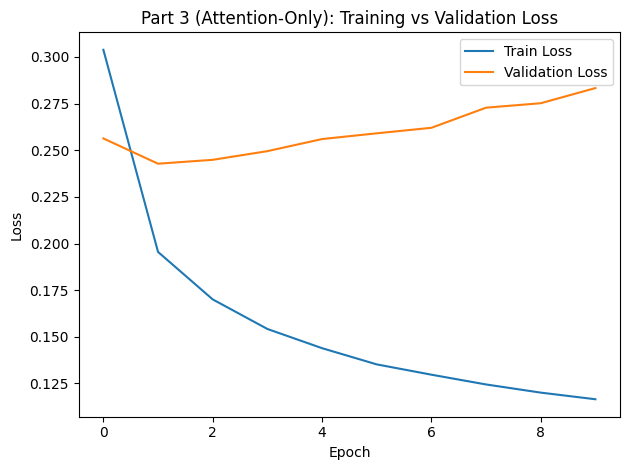

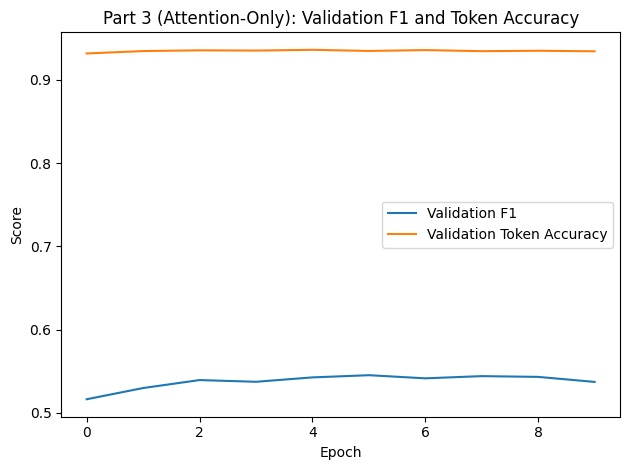

In [40]:
# TODO: Plot training dynamics for Part 3.
#
# Requirements (minimum):
# 1) Make one figure showing training loss and validation loss across epochs.
# 2) Make a second figure showing validation entity-level F1 and validation token accuracy across epochs.
#
# Notes:
# - Use whatever history containers you designed in your TODOs above (lists, dicts, logs, etc.).
# - Label axes clearly (Epoch vs Loss / Score) and include legends.
# - Keep plots consistent with earlier parts so comparisons are meaningful.

epochs = range(len(history3["train_loss"]))
plt.figure()
plt.plot(epochs, history3["train_loss"])
plt.plot(epochs, history3["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Part 3 (Attention-Only): Training vs Validation Loss")
plt.legend(["Train Loss", "Validation Loss"])
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(epochs, history3["val_f1"])
plt.plot(epochs, history3["val_token_acc"])
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Part 3 (Attention-Only): Validation F1 and Token Accuracy")
plt.legend(["Validation F1", "Validation Token Accuracy"])
plt.tight_layout()
plt.show()

## Final Evaluation on the Test Set (Part 3)

We run a **held-out test evaluation** using the same masked loss and NER span-level metrics as before, so we can compare Part 3 fairly against earlier architectures.


In [41]:
# TODO: Evaluate the final Part 3 model on the test set and print the results.
#
# Requirements:
# - Run your evaluation pipeline on `test_loader` using the best/selected model checkpoint.
# - Report (at minimum):
#   1) average test loss (masked over real tokens)
#   2) token-level accuracy (masked)
#   3) entity-level precision, recall, and F1 (BIO span-based)
#
# Notes:
# - Do NOT assume a specific return type for your evaluation function.
#   Use whatever structure you designed earlier (dict, namedtuple, etc.).
# - Print the metrics in a clean, readable single-line or multi-line format.
# - Keep the same metric definitions as Parts 0–2 so comparisons are fair.

test_metrics3 = evaluate_attn(attn_model, test_loader)

print(
    f"TEST | "
    f"loss={test_metrics3["loss"]:.4f} | "
    f"token_acc={test_metrics3["token_acc"]:.4f} | "
    f"P={ test_metrics3["precision"]:.4f} | "
    f"R={test_metrics3["recall"]:.4f} | "
    f"F1={test_metrics3["f1"]:.4f}"
)

TEST | loss=0.2461 | token_acc=0.9364 | P=0.4910 | R=0.6028 | F1=0.5412


## Attention Map Visualization (No Positional Encoding)

We visualize a **single-head self-attention heatmap** on a real validation sentence to qualitatively inspect what information the model is using when it has **no explicit positional encoding**.

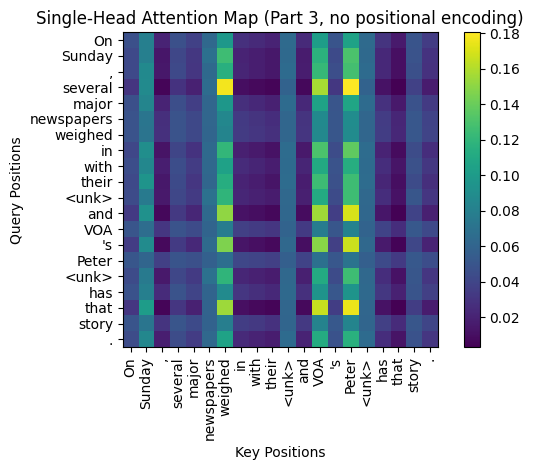

In [42]:
# TODO: Visualize a single-head attention map for one validation example.
#
# Goal:
# - Pick ONE example from `valid_loader` (or any loader you choose) and extract its attention matrix.
# - Plot a heatmap of attention weights for the first `max_tokens` real tokens.
#
# What you need to decide/implement:
# 1) How to get a batch and select an example inside it (by index).
# 2) How to call your model to *also* return attention weights.
#    - If your model doesn’t currently support returning attention, add an optional flag (e.g., return_attn=True).
# 3) How to crop to the true (unpadded) length using `attention_mask` and/or token count.
# 4) How to label axes with tokens (and rotate x-labels for readability).
#
# Hints (do not copy-paste blindly):
# - Attention for a single head is usually shaped like [B, T, T] (or [T, T] for one example).
# - Use the attention mask to ignore padding tokens when selecting/cropping.
# - Keep the plot readable: limit to ~20–30 tokens.
#
# Expected output:
# - A heatmap that helps us *qualitatively* inspect what the model attends to.

batch = next(iter(valid_loader))
input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)

attn_model.eval()
with torch.no_grad():
    logits, attn_weights = attn_model(input_ids, attention_mask=attention_mask, return_attn=True)

example_idx = 10
example_ids = input_ids[example_idx]            # [T]
example_mask = attention_mask[example_idx]      # [T]
example_attn = attn_weights[example_idx]        # [T, T]

true_len = example_mask.sum().item()
max_tokens = min(true_len, 25)
attn_crop = example_attn[:max_tokens, :max_tokens].cpu()
tokens = [itos[idx.item()] for idx in example_ids[:max_tokens]]

plt.figure()
plt.imshow(attn_crop)
plt.xticks(range(max_tokens), tokens, rotation=90)
plt.yticks(range(max_tokens), tokens)
plt.xlabel("Key Positions")
plt.ylabel("Query Positions")
plt.title("Single-Head Attention Map (Part 3, no positional encoding)")
plt.colorbar()
plt.tight_layout()
plt.show()

## Permutation Sanity Check (Order Sensitivity)

We run a small diagnostic where we **shuffle token order** in a short window and compare the model’s behavior before vs. after shuffling. The purpose is to test whether, **without positional encoding**, the model can reliably represent *order-dependent* structure in NER.

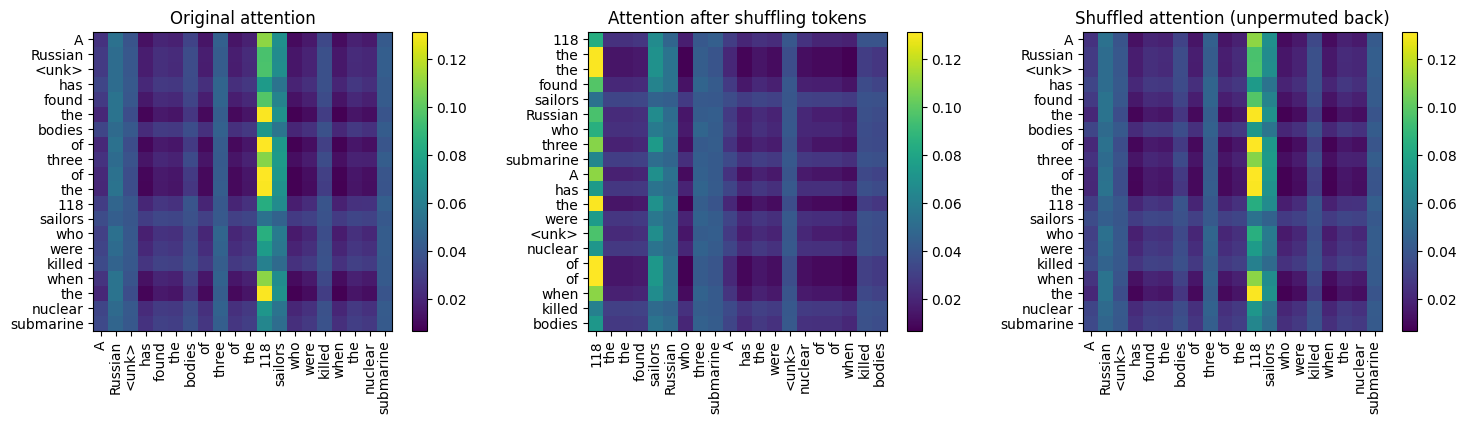

In [43]:
# TODO: Permutation sanity check (order sensitivity diagnostic).
#
# Goal:
# Show (empirically) that an attention-only model WITHOUT positional encoding
# is largely insensitive to token order (beyond token identity / content),
# by comparing behavior before vs. after shuffling tokens.
#
# What to implement:
# 1) Select ONE example (batch-of-1 is easiest) from a loader and choose a token window length L.
# 2) Run the model on the original input and extract:
#    - predicted tags (optional but recommended)
#    - attention matrix (if your model can return it)
# 3) Create a permuted version of the first L tokens (and permute the mask consistently).
# 4) Run the model on the permuted input and extract the same outputs.
# 5) Compare results in a way that makes the invariance (or lack of it) visible.
#
# You get to choose the comparison method:
# - Compare logits/predictions before vs. after permutation
# - Compare attention maps (raw) and/or attention maps re-indexed back to original order
# - Print the permutation and the token lists to keep the experiment interpretable
#
# Rules:
# - Do NOT change the model architecture here (the point is to probe it).
# - Keep the test small and readable (e.g., L <= 20).
#
# Expected output:
# - A short, clear qualitative comparison (plots and/or prints) that supports a conclusion
#   about whether the model is order-sensitive without positional information.

batch = next(iter(valid_loader))
input_ids = batch["input_ids"][0:1].to(device)  # [1, T]
attention_mask = batch["attention_mask"][0:1].to(device)
attn_model.eval()

with torch.no_grad():
    logits_orig, attn_orig = attn_model(input_ids, attention_mask=attention_mask, return_attn=True)

true_len = attention_mask[0].sum().item()
L = min(true_len, 20)

orig_ids = input_ids[0, :L].clone()
orig_tokens = [itos[i.item()] for i in orig_ids]

orig_preds = logits_orig.argmax(-1)[0, :L].cpu()
orig_tags = [id2label[p.item()] for p in orig_preds]

perm = torch.randperm(L)
shuffled_ids = input_ids.clone()
shuffled_ids[0, :L] = input_ids[0, perm]
with torch.no_grad():
    logits_perm, attn_perm = attn_model(shuffled_ids, attention_mask=attention_mask, return_attn=True)

perm_preds = logits_perm.argmax(-1)[0, :L].cpu()
perm_tags = [id2label[p.item()] for p in perm_preds]
shuffled_tokens = [orig_tokens[i] for i in perm.tolist()]

attn_orig_crop = attn_orig[0, :L, :L].cpu()
attn_perm_crop = attn_perm[0, :L, :L].cpu()

inv_perm = torch.argsort(perm)
attn_perm_reindexed = attn_perm_crop[inv_perm][:, inv_perm]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
im0 = axes[0].imshow(attn_orig_crop)
axes[0].set_title("Original attention")
axes[0].set_xticks(range(L))
axes[0].set_xticklabels(orig_tokens, rotation=90)
axes[0].set_yticks(range(L))
axes[0].set_yticklabels(orig_tokens)
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(attn_perm_crop)
axes[1].set_title("Attention after shuffling tokens")
axes[1].set_xticks(range(L))
axes[1].set_xticklabels(shuffled_tokens, rotation=90)
axes[1].set_yticks(range(L))
axes[1].set_yticklabels(shuffled_tokens)
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(attn_perm_reindexed)
axes[2].set_title("Shuffled attention (unpermuted back)")
axes[2].set_xticks(range(L))
axes[2].set_xticklabels(orig_tokens, rotation=90)
axes[2].set_yticks(range(L))
axes[2].set_yticklabels(orig_tokens)
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

In [44]:
print("Original tokens:")
print(orig_tokens)
print("\nOriginal predictions:")
print(orig_tags)
print("\nPermutation indices:")
print(perm.tolist())
print("\nShuffled tokens:")
print(shuffled_tokens)
print("\nPredictions after shuffle:")
print(perm_tags)

Original tokens:
['A', 'Russian', '<unk>', 'has', 'found', 'the', 'bodies', 'of', 'three', 'of', 'the', '118', 'sailors', 'who', 'were', 'killed', 'when', 'the', 'nuclear', 'submarine']

Original predictions:
['O', 'B-NORP', 'I-LOC', 'O', 'O', 'B-LOC', 'O', 'O', 'B-CARDINAL', 'O', 'B-LOC', 'B-CARDINAL', 'O', 'O', 'O', 'O', 'O', 'B-LOC', 'O', 'O']

Permutation indices:
[11, 5, 10, 4, 12, 1, 13, 8, 19, 0, 3, 17, 14, 2, 18, 7, 9, 16, 15, 6]

Shuffled tokens:
['118', 'the', 'the', 'found', 'sailors', 'Russian', 'who', 'three', 'submarine', 'A', 'has', 'the', 'were', '<unk>', 'nuclear', 'of', 'of', 'when', 'killed', 'bodies']

Predictions after shuffle:
['B-CARDINAL', 'B-LOC', 'B-LOC', 'O', 'O', 'B-NORP', 'O', 'B-CARDINAL', 'O', 'O', 'O', 'B-LOC', 'O', 'I-LOC', 'O', 'O', 'O', 'O', 'O', 'O']


## Concept Checks (answer in Markdown, no code)

1. **Why is this an important ablation?**  
   What specific capability do we lose by removing BiLSTM-style recurrence?

2. **Self-attention mixes tokens — so why might order still be missing?**  
   In plain language, explain why “mixing” is not the same as “knowing positions.”

3. **Interpretation caution:**  
   If we visualize a single-head attention map, why is it risky to conclude that the model “understands” syntax or entities from the heatmap alone?

# Part 4 — Adding Positional Encoding (Fixing the Order Blindness)

In Part 3 we intentionally built an **attention-only** tagger *without* any explicit notion of token position.  
That setup is useful because it exposes a core limitation: **self-attention can mix information globally, but it does not inherently know token order** unless we give it some positional signal.

In this part we make **one minimal, controlled change**:

- We keep the attention-only architecture the same.
- We add **sinusoidal positional encoding** to the token embeddings before attention.

Everything else (data, masking, loss, optimizer style, evaluation metrics) should remain as consistent as possible so that we can interpret changes in performance as “the effect of position”.

By the end of Part 4, we should be able to answer a simple experimental question:

> Does injecting positional information recover performance and make attention behave more “structure-aware” on an order-sensitive task like NER?

## What we should pay attention to in this part

- **Fair comparison:** We should not change multiple knobs at once.  
- **Evaluation:** We still care most about **entity-level F1**, not token accuracy.
- **Interpretability (with caution):** Attention maps may look different with positional encoding, but we should treat them as *signals*, not proofs.

## Sinusoidal Positional Encoding

We add a **fixed sinusoidal positional signal** to token embeddings so the attention-only model can represent **token order**.  
In this cell, we implement a reusable module that precomputes a position table and adds the correct prefix for a given sequence length.

In [45]:
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512):
        super().__init__()

        position = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model, dtype=torch.float32)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # [1, max_len, d_model]
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor):
        seq_len = x.size(1) # [B, T, d_model] --> [T]
        return x + self.pe[:, :seq_len, :]

## Attention-Only Tagger + Positional Encoding (Part 4)

We repeat the Part 3 attention-only tagger, but we inject **sinusoidal positional information** into the embeddings so the model can represent **token order**.  
This is an ablation-style step: we keep everything else as comparable as possible and test whether adding position restores NER performance.

In [46]:
class AttentionOnlyTaggerWithPE(nn.Module):
    """
    Same as Part 3 AttentionOnlyTagger, but adds sinusoidal positional encoding to embeddings.
    """
    def __init__(
        self,
        vocab_size: int,
        num_labels: int,
        pad_id: int,
        d_model: int = 128,
        dropout: float = 0.2,
        max_len: int = 512,
        use_scaling: bool = True,
    ):
        super().__init__()
        self.pad_id = pad_id
        self.num_labels = num_labels
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.posembedding = SinusoidalPositionalEncoding(d_model, max_len)
        self.emb_dropout = nn.Dropout(dropout)
        self.attn_block = SingleHeadSelfAttention(d_model=d_model, dropout=dropout, use_scaling=use_scaling)
        self.ffn = nn.Sequential(nn.Linear(d_model, d_model), nn.ReLU(), nn.Dropout(dropout), nn.Linear(d_model, d_model))
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model, num_labels)
        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.embedding.weight)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor = None,
        return_attn: bool = False
    ):
        x = self.embedding(input_ids)  # [B, T, D]
        x = self.posembedding(x) # [B, T, D]
        x = self.emb_dropout(x)
        attn_out, attn_weights = self.attn_block(x, attention_mask=attention_mask, return_attn=True)
        x = self.ln1(x + attn_out)
        ff_out = self.ffn(x)
        x = self.ln2(x + ff_out)
        logits = self.classifier(x)  # [B, T, num_labels]
        if return_attn:
            return logits, attn_weights
        else:
            return logits

## Notice: We Reuse the Part 3 Training/Evaluation Code

**Do not re-implement `train_one_epoch_attn(...)` and `evaluate_attn(...)` in Part 4.**

In Part 4, we intentionally keep the **same training loop and the same evaluation harness** from Part 3.  
This is a controlled experiment: the *only* conceptual change we want to test is **adding positional encoding**.

## Initialize the Positional-Encoding Model

We fix the random seed again and instantiate the **attention-only tagger with sinusoidal positional encoding**.  
Keeping the initialization protocol consistent helps us attribute any performance changes to **positional information**, not to randomness or a different setup.

In [47]:
seed_everything(cfg.seed)

pe_model = AttentionOnlyTaggerWithPE(
    vocab_size=len(stoi),
    num_labels=num_labels,
    pad_id=stoi[cfg.pad_token],
    d_model=128,      # keep consistent with Part 3 unless we explicitly ablate this
    dropout=0.2,
    max_len=512,
    use_scaling=True,
).to(device)

## Train the PE Model (Early Stopping on Entity F1)

We now train the **attention-only model with sinusoidal positional encoding** under the same evaluation protocol as Part 3.  
Your job is to implement a clean training loop, track the key metrics, and use **early stopping based on validation entity-level F1** so the comparison stays fair and meaningful.

In [48]:
# Optimizer and training configuration (you may tune these, but keep Part 3 vs Part 4 comparisons fair)
optimizer = torch.optim.AdamW(pe_model.parameters(), lr=3e-4, weight_decay=1e-2)

EPOCHS = 10
patience = 5

# Track the best checkpoint (by validation F1)
best_f1_pe = 0
best_state_pe = None
bad_epochs = 0

# Keep a lightweight training history for plotting/diagnostics
history4 = {"train_loss": [], "val_loss": [], "val_token_acc": [], "val_f1": []}

# TODO:
# Train the positional-encoding model for up to `EPOCHS` epochs.
#
# Requirements:
# 1) Each epoch should:
#    - run one full training epoch (reuse the helper you used in Part 3)
#    - evaluate on the validation split (reuse the helper you used in Part 3)
#    - append metrics to `history4`
#    - print a concise progress line (epoch, train_loss, val_loss, val_token_acc, val_F1)
#
# 2) Early stopping:
#    - monitor validation entity-level F1 (NOT token accuracy)
#    - if F1 improves (with a small tolerance), save the model weights into `best_state_pe`
#    - otherwise increment `bad_epochs`
#    - stop when `bad_epochs >= patience`
#
# 3) After the loop:
#    - load `best_state_pe` back into `pe_model`
#    - print the best validation F1 you achieved
#
# Notes:
# - Keep the comparison fair: avoid changing multiple factors at once (e.g., EPOCHS + model size + optimizer).
# - If you change any training detail, document it briefly in a Markdown cell near the change.

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch_attn(pe_model, train_loader, optimizer)
    val_metrics = evaluate_attn(pe_model, valid_loader)

    history4["train_loss"].append(train_loss)
    history4["val_loss"].append(val_metrics['loss'])
    history4["val_token_acc"].append(val_metrics['token_acc'])
    history4["val_f1"].append(val_metrics['f1'])

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_token_acc={val_metrics['token_acc']:.4f} | "
        f"val_F1={val_metrics['f1']:.4f}"
    )

    current_f1 = val_metrics["f1"]
    if current_f1 > best_f1_pe + 1e-5:
        best_f1_pe = current_f1
        best_state_pe = copy.deepcopy(pe_model.state_dict())
        bad_epochs = 0
    else:
        bad_epochs += 1

    if bad_epochs >= patience:
        break

pe_model.load_state_dict(best_state_pe)
print(f"Loaded best PE model with val_F1 = {best_f1_pe:.4f}")

Epoch 01 | train_loss=0.5516 | val_loss=0.3935 | val_token_acc=0.9093 | val_F1=0.3307
Epoch 02 | train_loss=0.3607 | val_loss=0.2909 | val_token_acc=0.9284 | val_F1=0.4790
Epoch 03 | train_loss=0.2831 | val_loss=0.2470 | val_token_acc=0.9369 | val_F1=0.5505
Epoch 04 | train_loss=0.2385 | val_loss=0.2211 | val_token_acc=0.9423 | val_F1=0.5832
Epoch 05 | train_loss=0.2092 | val_loss=0.2085 | val_token_acc=0.9449 | val_F1=0.6114
Epoch 06 | train_loss=0.1881 | val_loss=0.2061 | val_token_acc=0.9467 | val_F1=0.6156
Epoch 07 | train_loss=0.1729 | val_loss=0.1957 | val_token_acc=0.9479 | val_F1=0.6383
Epoch 08 | train_loss=0.1611 | val_loss=0.1948 | val_token_acc=0.9485 | val_F1=0.6450
Epoch 09 | train_loss=0.1517 | val_loss=0.1895 | val_token_acc=0.9500 | val_F1=0.6446
Epoch 10 | train_loss=0.1452 | val_loss=0.1893 | val_token_acc=0.9503 | val_F1=0.6700
Loaded best PE model with val_F1 = 0.6700


## Test Evaluation (Report Final Metrics)

We report **test-set** loss, token accuracy, and entity-level precision/recall/F1 for the positional-encoding model.  
This is the number we will later compare against Part 3 to see how much **positional information** changes performance.

In [49]:
test_metrics4 = evaluate_attn(pe_model, test_loader)

print(
    f"PART 4 TEST | "
    f"loss={test_metrics4['loss']:.4f} | "
    f"token_acc={test_metrics4['token_acc']:.4f} | "
    f"P={test_metrics4['precision']:.4f} | "
    f"R={test_metrics4['recall']:.4f} | "
    f"F1={test_metrics4['f1']:.4f}"
)

PART 4 TEST | loss=0.1822 | token_acc=0.9505 | P=0.6316 | R=0.6887 | F1=0.6589


## Plot Learning Curves (Diagnostics)

We visualize our Part 4 training dynamics to diagnose optimization and generalization:  
loss curves tell us whether training is stable, and score curves (especially entity-level F1) tell us whether improvements translate to better NER performance.

/tmp/ipykernel_55/2638807315.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


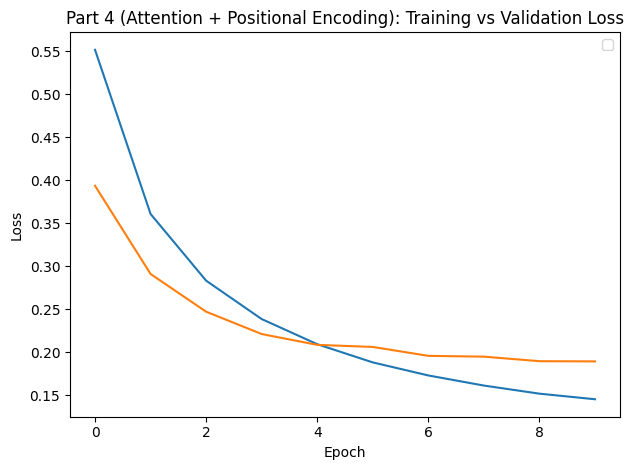

/tmp/ipykernel_55/2638807315.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


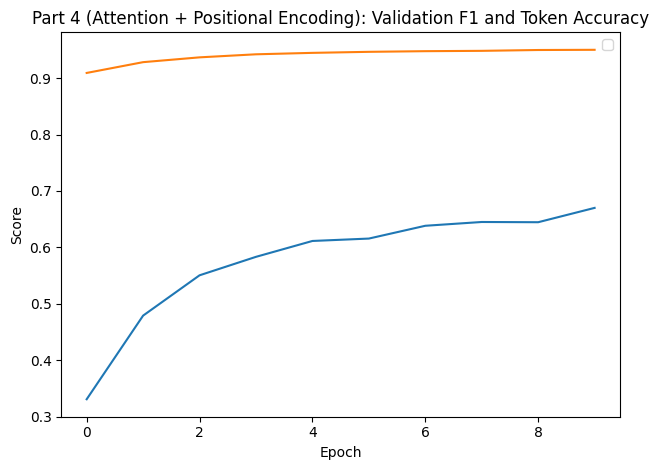

In [50]:
# TODO: Plot learning curves for Part 4.
#
# Requirements:
# - Plot at least one loss curve (e.g., train vs. validation).
# - Plot at least one NER score curve (e.g., validation F1; optionally token accuracy too).
# - Use the history structure YOU chose in earlier TODOs (do not hardcode my key names).
#
# Suggestions (optional):
# - Add axis labels, legends, and a clear title.
# - If you tracked multiple metrics, consider separate figures for loss vs. scores.

epochs = range(len(history4["train_loss"]))
plt.figure()
plt.plot(epochs, history4["train_loss"])
plt.plot(epochs, history4["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Part 4 (Attention + Positional Encoding): Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(epochs, history4["val_f1"])
plt.plot(epochs, history4["val_token_acc"])
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Part 4 (Attention + Positional Encoding): Validation F1 and Token Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

## Compare With vs Without Positional Encoding

Here we make a *fair* visual comparison between Part 3 (attention-only **without** positional encoding) and Part 4 (the **same** model but **with** positional encoding).  
We compare validation curves (loss and at least one NER score such as entity-level F1) across epochs to see whether adding positional information improves learning dynamics and final tagging quality.


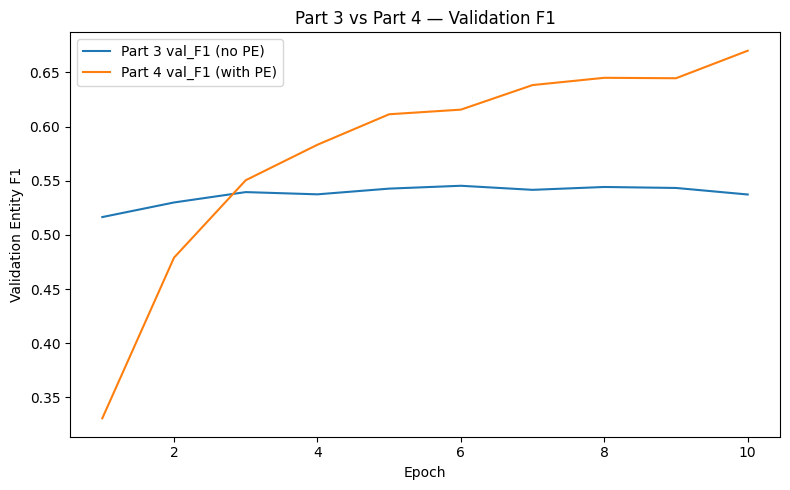

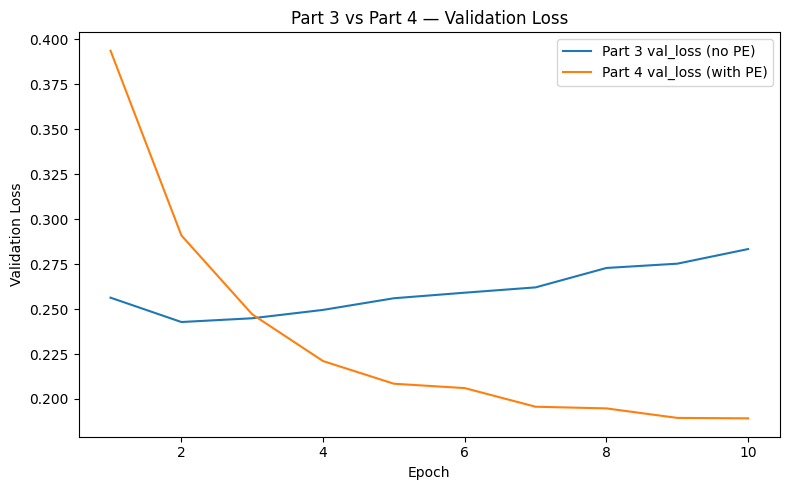

In [51]:
# TODO: Compare Part 3 (no positional encoding) vs Part 4 (with positional encoding).
#
# Goal:
# - Plot a side-by-side (or overlaid) comparison of validation performance across epochs.
#
# Minimum:
# - One comparison plot for a score metric (preferably entity-level F1).
# - One comparison plot for validation loss (or another comparable optimization signal).
#
# Constraints:
# - Do NOT assume specific variable names like `history3` / `history4`.
# - Use the metric containers you created in your own earlier TODOs.
# - Ensure the curves are aligned by epoch index; if early stopping differs, handle unequal lengths cleanly.
#
# Suggestions:
# - Use clear labels such as "Part 3 (no PE)" and "Part 4 (with PE)".
# - Add xlabel/ylabel/legend and an informative title.
#
# After plotting, briefly comment (in a Markdown cell) on what changed and why you think it changed.

history_no_pe = history3
history_with_pe = history4

def get_min_len(key):
    return min(len(history_no_pe[key]), len(history_with_pe[key]))

if "val_f1" in history_no_pe and "val_f1" in history_with_pe:
    min_len = get_min_len("val_f1")
    epochs = range(1, min_len + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(
        epochs,
        history_no_pe["val_f1"][:min_len],
        label="Part 3 val_F1 (no PE)"
    )
    plt.plot(
        epochs,
        history_with_pe["val_f1"][:min_len],
        label="Part 4 val_F1 (with PE)"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Validation Entity F1")
    plt.title("Part 3 vs Part 4 — Validation F1")
    plt.legend()
    plt.tight_layout()
    plt.show()

if "val_loss" in history_no_pe and "val_loss" in history_with_pe:
    min_len = get_min_len("val_loss")
    epochs = range(1, min_len + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(
        epochs,
        history_no_pe["val_loss"][:min_len],
        label="Part 3 val_loss (no PE)"
    )
    plt.plot(
        epochs,
        history_with_pe["val_loss"][:min_len],
        label="Part 4 val_loss (with PE)"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Validation Loss")
    plt.title("Part 3 vs Part 4 — Validation Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

**My Answer and Comparison**: Based on the above curves, Part 4 (with Positional Encoding) significantly outperforms Part 3 (without Positional Encoding), demonstrating that spatial awareness is critical for NER tasks. While the model without positional encoding (blue line) starts with a lower loss and higher F1, it immediately stagnates—its validation loss slowly increases (worsening from ~0.26 to ~0.28) and its F1 score barely improves, flattening out around 0.54. In contrast, the model with positional encoding (orange line) shows a healthy learning trajectory: although it starts with worse metrics, it rapidly improves, crossing the no-PE model around Epoch 3 and achieving a much higher final F1 score of approximately 0.67 and a significantly lower validation loss of ~0.19. This confirms that without positional information, the self-attention mechanism acts merely as a "bag-of-words" processor, failing to capture the sequence dependencies necessary to correctly identify multi-token entity boundaries.

## Attention Map Comparison: No PE vs With PE

In this cell we compare *interpretability signals* across two nearly identical models:  
the attention-only tagger **without** positional encoding (Part 3) and the same architecture **with** sinusoidal positional encoding (Part 4).

We visualize a single sentence’s attention matrix from each model (cropped to real token length) and compare patterns qualitatively.  
The goal is not to “prove” correctness from attention, but to develop intuition about how positional information can reshape attention structure.

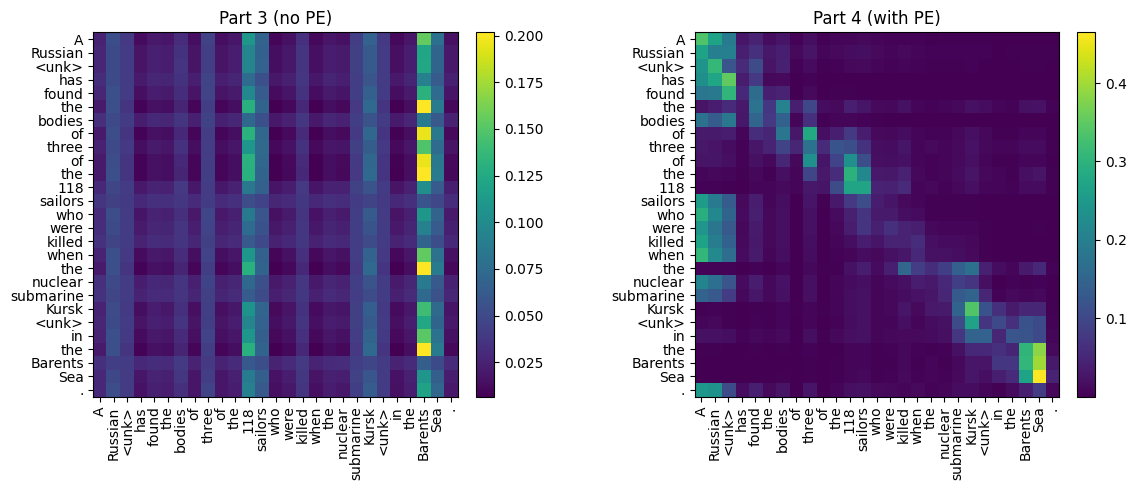

In [52]:
# TODO: Visualize and compare attention patterns for:
#   - Part 3 model (no positional encoding)
#   - Part 4 model (with sinusoidal positional encoding)
#
# Requirements:
# 1) Pick a singleREASONABLE way to extract attention weights from both models
#    (e.g., by enabling a `return_attn=True` flag in forward).
# 2) Choose one batch from `valid_loader` and one example index inside that batch.
# 3) Crop attention to the true (unpadded) token length and optionally limit to `max_tokens`.
# 4) Plot attention matrices side-by-side with:
#    - same token labels on x/y axes
#    - colorbar
#    - clear titles (e.g., "Part 3 (no PE)" vs "Part 4 (with PE)")
#
# Notes:
# - Do NOT assume variable names like `attn_model`, `pe_model`, `history3`, `history4`.
# - Do NOT assume a specific attention shape; print shapes once to confirm and then slice carefully.
# - Keep plots readable: rotate x-ticks, use tight_layout, and cap max_tokens if needed.
#
# After plotting, write a short Markdown reflection:
# - What qualitative differences do we see (if any)?
# - How might positional encoding change the structure of attention?

example_idx = 0
max_tokens = 50

batch = next(iter(valid_loader))
input_ids = batch["input_ids"].to(device)   # [B, T]
attention_mask = batch.get("attention_mask", None)
if attention_mask is not None:
    attention_mask = attention_mask.to(device)

input_ids_ex = input_ids[example_idx].unsqueeze(0)  # [1, T]
attention_mask_ex = attention_mask[example_idx].unsqueeze(0) if attention_mask is not None else None

attn_model.eval()
pe_model.eval()
with torch.no_grad():
    logits3, attn3 = attn_model(input_ids_ex, attention_mask=attention_mask_ex, return_attn=True)
    logits4, attn4 = pe_model(input_ids_ex, attention_mask=attention_mask_ex, return_attn=True)

true_len = (input_ids_ex != stoi[cfg.pad_token]).sum().item()
true_len = min(true_len, max_tokens)
attn3 = attn3[0, :true_len, :true_len].cpu()
attn4 = attn4[0, :true_len, :true_len].cpu()
tokens = [itos[idx.item()] for idx in input_ids_ex[0, :true_len]]

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
im0 = axs[0].imshow(attn3, cmap="viridis")
axs[0].set_title("Part 3 (no PE)")
axs[0].set_xticks(range(len(tokens)))
axs[0].set_yticks(range(len(tokens)))
axs[0].set_xticklabels(tokens, rotation=90)
axs[0].set_yticklabels(tokens)
fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)
im1 = axs[1].imshow(attn4, cmap="viridis")
axs[1].set_title("Part 4 (with PE)")
axs[1].set_xticks(range(len(tokens)))
axs[1].set_yticks(range(len(tokens)))
axs[1].set_xticklabels(tokens, rotation=90)
axs[1].set_yticklabels(tokens)
fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## Concept Checks (answer in Markdown, no code)

### Q1 — Why positional encoding is needed
Self-attention computes attention weights using content-based similarity.  
Why does this make the model *potentially invariant* to token order when we remove any positional signal?

**My Answer**: Self-attention scores tokens based solely on content similarity. Without positional information, tokens like "Alice" and "Bob" may be treated identically regardless of order. This makes the model invariant to permutation — it can mix information from all positions without knowing sequence structure. For NER, this is critical because entity boundaries depend on token order.

### Q2 — What sinusoidal positional encoding provides
Sinusoidal positional encoding is a deterministic function of position index.  
What property makes it reasonable for sequence models, and what kinds of information can it inject into embeddings?

**My Answer**: Sinusoidal PE is a deterministic, fixed function of position. It provides unique representation for each position, allows the model to compute relative or absolute distances using linear combinations.
It injectes token order, relative distance between tokens and helps attention distinguish "before" vs "after" tokens.

### Q3 — Controlled ablation logic
If we keep everything the same except positional encoding, what conclusions are we allowed to draw from:
- a large improvement in entity F1? **My Answer**: Positional information is critical for this task; the model benefits from order awareness.
- a small/no improvement? **My Answer**: Self-attention may already capture weak positional cues (e.g., via padding masks or local correlations) and order may be less important for the dataset/task.
- a drop in performance? **My Answer**: Positional encoding interacts poorly with existing model structure or overfitting / training instability could occur.

### Q4 — Attention-map comparison interpretation
When we compare attention maps between Part 3 and Part 4:
- What qualitative patterns would we *expect* to change if positional information is being used? **My Answer**: Attention becomes more diagonal / local, Nearby tokens receive higher attention, reflecting sequence order

Long-range mixing may still occur but is structured
- Why is it still risky to claim “the model learned X” based purely on attention heatmaps? **My Answer**: Attention heatmaps are not explanations, they show where the model “looks” but do not prove causal reasoning and multiple attention patterns can yield the same output.

# Part 5 — Multi-Head Attention

In Parts 3–4 we saw that **self-attention can mix global context**, but it also needs **positional information** to work well on order-sensitive tasks like NER.  
Now we take the next step toward real Transformer encoders: **multi-head self-attention**.

The key idea is simple:

- Instead of learning *one* attention pattern, we learn **multiple attention heads in parallel**.
- Each head can focus on different relationships (local neighborhoods, long-range dependencies, boundary cues, etc.).
- We then **combine** those heads to form a richer representation.

In this part we will:
- implement **multi-head self-attention** (single layer first),
- wrap it into a standard **encoder-layer block** (attention + feed-forward + residuals + layer norm),
- stack multiple layers,
- train and compare against our earlier attention models,
- and finally **inspect attention heads** to build intuition about what different heads might be doing.


## Multi-Head Self-Attention (TODO)

In this cell we implement **multi-head self-attention**: multiple attention heads run in parallel on different learned subspaces, then their outputs are concatenated and projected back to \(d_{\text{model}}\). The key technical requirements are correct **tensor shapes**, correct **scaled dot-product attention**, and correct **padding masking** so pad tokens do not receive attention.

In [53]:
# TODO (Part 5): Implement Multi-Head Self-Attention (MHA)
#
# Goal:
#   Write a PyTorch module that takes a sequence representation x and returns
#   a transformed representation using multi-head scaled dot-product attention.
#
# Required interface:
#   class MultiHeadSelfAttention(nn.Module):
#       def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1): ...
#       def forward(self, x: torch.Tensor, attention_mask: torch.Tensor = None,
#                   return_attn: bool = False): ...
#
# Inputs:
#   x:              [B, T, d_model]
#   attention_mask: [B, T] where 1 indicates a real token and 0 indicates padding
#
# Outputs:
#   y:    [B, T, d_model]
#   attn: (optional) attention weights with shape [B, H, T, T]
#
# Design requirements (you decide how to implement, but must satisfy behavior):
#   1) Split the model dimension into H heads:
#        d_head = d_model / H   (so d_model must be divisible by num_heads)
#   2) Compute per-head Q, K, V projections (any equivalent efficient form is fine).
#   3) Compute scaled dot-product attention:
#        scores = (Q @ K^T) / sqrt(d_head)
#      IMPORTANT: use correct transpose for the last two dimensions of K.
#   4) Apply padding mask so padded KEYS do not receive attention.
#      (Mask should affect the "columns" of the [T x T] score matrix.)
#   5) Softmax over the last dimension to get attention probabilities.
#   6) Multiply attention by V, then combine heads back to [B, T, d_model].
#   7) Apply output projection (and dropout if you want).
#   8) If return_attn=True, return (y, attn); otherwise return y.
#
# Notes:
#   - There are multiple correct implementations. We care about correctness,
#     shapes, and masking behavior—not matching a specific code style.
#   - Choose stable masking (e.g., a very negative fill value) to prevent pads
#     from influencing attention.
#
# Hint checklist (shapes):
#   - After projection, typical head shapes are [B, H, T, d_head]
#   - scores should become [B, H, T, T]
#   - attention_mask must broadcast to scores correctly
#
# Write your implementation below.

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_head = d_model // num_heads
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, attention_mask: torch.Tensor = None, return_attn: bool = False):
        B, T, D = x.size()  # D = d_model
        Q = self.q_proj(x)  # [B, T, d_model]
        K = self.k_proj(x)  # [B, T, d_model]
        V = self.v_proj(x)  # [B, T, d_model]

        Q = Q.view(B, T, self.num_heads, self.d_head).transpose(1, 2) # [B, H, T, d_head]
        K = K.view(B, T, self.num_heads, self.d_head).transpose(1, 2) # [B, H, T, d_head]
        V = V.view(B, T, self.num_heads, self.d_head).transpose(1, 2) # [B, H, T, d_head]
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_head) # [B, H, T, T]

        if attention_mask is not None:
            mask = attention_mask[:, None, None, :].to(dtype=scores.dtype) # [B, T] -> [B, 1, 1, T]
            scores = scores.masked_fill(mask == 0, float('-inf'))

        attn = F.softmax(scores, dim=-1) # [B, H, T, T]
        attn = self.dropout(attn) # [B, H, T, T]
        context = torch.matmul(attn, V)  # [B, H, T, d_head]
        context = context.transpose(1, 2).contiguous().view(B, T, self.d_model)  # [B, T, d_model]
        y = self.out_proj(context) # [B, T, d_model]

        if return_attn:
            return y, attn
        else:
            return y

## Transformer Encoder Layer (MHA + FFN) (TODO)

In this cell we build a **Transformer encoder layer**: multi-head self-attention followed by a position-wise feed-forward network, each wrapped with **residual connections**, **dropout**, and **layer normalization**. This layer becomes the reusable “brick” we will stack to form deeper Transformer encoders.

In [54]:
# TODO (Part 5): Implement a Transformer Encoder Layer using Multi-Head Attention
#
# Goal:
#   Build a standard Transformer-style encoder layer:
#     1) Multi-Head Self-Attention sublayer
#     2) Feed-Forward Network (FFN) sublayer
#   Each sublayer should use:
#     - Residual connection
#     - Dropout
#     - LayerNorm
#
# Required interface:
#   class TransformerEncoderLayerMHA(nn.Module):
#       def __init__(self, d_model: int, num_heads: int, dropout: float = 0.2, ff_mult: int = 4): ...
#       def forward(self, x: torch.Tensor, attention_mask: torch.Tensor = None, return_attn: bool = False): ...
#
# Inputs:
#   x:              [B, T, d_model]
#   attention_mask: [B, T] (1 for real tokens, 0 for padding)
#
# Outputs:
#   x_out: [B, T, d_model]
#   attn:  (optional) attention weights from the MHA sublayer (shape depends on your MHA)
#
# Design requirements:
#   - The attention sublayer should call your MultiHeadSelfAttention.
#   - Apply residual + dropout + layernorm around attention.
#   - Then apply FFN (2 linear layers with an activation, e.g. GELU) and again residual + dropout + layernorm.
#   - If return_attn=True, return (x_out, attn); otherwise return x_out.
#
# Notes:
#   - You may choose "Pre-LN" or "Post-LN" style, but be consistent.
#   - Keep shapes consistent throughout.

class TransformerEncoderLayerMHA(nn.Module):
    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.2, ff_mult: int = 4):
        super().__init__()
        self.mha = MultiHeadSelfAttention(d_model=d_model, num_heads=num_heads, dropout=dropout)
        self.attn_dropout = nn.Dropout(dropout)
        self.attn_ln = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(nn.Linear(d_model, ff_mult * d_model), nn.GELU(), nn.Dropout(dropout), nn.Linear(ff_mult * d_model, d_model))
        self.ffn_dropout = nn.Dropout(dropout)
        self.ffn_ln = nn.LayerNorm(d_model)

    def forward(self, x: torch.Tensor, attention_mask: torch.Tensor = None, return_attn: bool = False):
        attn_out, attn = self.mha(x, attention_mask=attention_mask, return_attn=True) # [B, T, d_model], # [B, H, T, T]
        x = self.attn_ln(x + self.attn_dropout(attn_out)) # [B, T, d_model]
        ff_out = self.ffn(x)
        x = self.ffn_ln(x + self.ffn_dropout(ff_out))

        if return_attn:
            return x, attn
        else:
            return x

## Multi-Head Attention-Only Tagger (Stacked Encoder) (TODO)

In this cell we assemble the **Part 5 model**: token embeddings, optional positional encoding, a **stack of Transformer encoder layers with multi-head self-attention**, and a final per-token classifier for NER. We also add a hook to optionally return attention maps from a chosen layer for interpretability experiments later in the section.

In [55]:
# TODO (Part 5): Implement a multi-layer, multi-head attention-only NER tagger
#
# Goal:
#   Build an encoder that uses:
#     - Token embeddings
#     - (Optional) positional encoding
#     - A stack of TransformerEncoderLayerMHA blocks
#     - A token-level classifier to predict NER tags
#
# Required interface:
#   class MultiHeadAttentionOnlyTagger(nn.Module):
#       def __init__(...): ...
#       def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor = None, return_attn_layer: int = -1): ...
#
# Inputs:
#   input_ids:       [B, T]
#   attention_mask:  [B, T] (1 real tokens, 0 padding)
#   return_attn_layer:
#       - If set to a valid layer index, the forward pass should also return that layer's attention map.
#       - If set to -1, no attention map is returned.
#
# Outputs:
#   logits: [B, T, num_labels]
#   (optional) attn: attention weights from the requested layer (shape depends on your MHA implementation)
#
# Design degrees of freedom (you choose):
#   - Whether to scale embeddings by sqrt(d_model)
#   - Where/how to apply dropout
#   - Whether positional encoding is sinusoidal or learned (keep interface compatible)
#   - How you manage "return_attn_layer" (only one layer’s attention is needed)
#
# Notes:
#   - Keep the implementation consistent with your Part 4 positional encoding (if you reuse it).
#   - Make sure masking is respected inside attention.

class MultiHeadAttentionOnlyTagger(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        num_labels: int,
        pad_id: int,
        d_model: int = 192,
        num_heads: int = 4,
        num_layers: int = 2,
        dropout: float = 0.2,
        max_len: int = 512,
        use_positional_encoding: bool = True,
    ):
        super().__init__()
        self.pad_id = pad_id
        self.num_labels = num_labels
        self.d_model = d_model
        self.num_layers = num_layers
        self.use_positional_encoding = use_positional_encoding
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.embed_dropout = nn.Dropout(dropout)
        if use_positional_encoding:
            self.positional_encoding = SinusoidalPositionalEncoding(d_model=d_model, max_len=max_len)
        else:
            self.positional_encoding = None
        self.layers = nn.ModuleList([TransformerEncoderLayerMHA(d_model=d_model, num_heads=num_heads, dropout=dropout) for _ in range(num_layers)])
        self.classifier = nn.Linear(d_model, num_labels)
        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.embedding.weight)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor = None,
        return_attn_layer: int = -1,
    ):
        x = self.embedding(input_ids)  # [B, T, D]
        if self.positional_encoding is not None:
            x = self.positional_encoding(x) # [B, T, D]
        x = self.embed_dropout(x)
        attn_out = None

        for layer_idx, layer in enumerate(self.layers):
            if return_attn_layer == layer_idx:
                x, attn_out = layer(x, attention_mask=attention_mask, return_attn=True)
            else:
                x = layer(x, attention_mask=attention_mask, return_attn=False)

        logits = self.classifier(x)  # [B, T, num_labels]

        if return_attn_layer >= 0 and attn_out is not None:
            return logits, attn_out
        else:
            return logits

## Train the Multi-Head Attention Model (TODO)

In this cell we run the full **training + validation** loop for our multi-head encoder, track **loss and NER metrics**, and apply **early stopping** based on **validation entity-level F1**. At the end, we reload the best checkpoint so evaluation and visualization always reflect the best-performing model from this run.

In [56]:
# TODO (Part 5): Train the Multi-Head Attention model + early stopping + checkpointing
#
# In this cell we will:
#   1) Instantiate your MultiHeadAttentionOnlyTagger (mha_model)
#   2) Print the number of trainable parameters (optional but recommended)
#   3) Define an optimizer (and any scheduler you want)
#   4) Run a training loop that tracks validation metrics each epoch
#   5) Implement early stopping based on validation entity-level F1
#   6) Save the best model state and reload it at the end
#
# Important:
#   - Reuse your Part 3/4 utilities (train_one_epoch_attn, evaluate_attn, loss_mean, etc.) if you wrote them.
#   - If those utilities were TODOs in your notebook version, do NOT paste the full solutions here.
#     Instead call your own implementations from earlier cells.
#   - Keep comparisons fair: same splits, same metric definitions, and similar budgets across parts.

def count_params(m: nn.Module) -> int:
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

# TODO: instantiate mha_model with the chosen hyperparameters
mha_model = MultiHeadAttentionOnlyTagger(
    vocab_size=len(stoi),
    num_labels=num_labels,
    pad_id=stoi[cfg.pad_token],
    d_model=192,
    num_heads=4,
    num_layers=2,
    dropout=0.2,
    max_len=512,
    use_positional_encoding=True,
).to(device)

# TODO: print parameter count (optional)
print("Trainable params:", f"{count_params(mha_model):,}")

# TODO: define optimizer (and optional scheduler)
optimizer = torch.optim.AdamW(mha_model.parameters(), lr=3e-4, weight_decay=1e-2)

# TODO: set training hyperparameters (epochs, patience, grad clipping, etc.)
EPOCHS = 10
patience = 5
grad_clip = 1.0

# TODO: initialize early-stopping bookkeeping and history dict
best_f1 = 0
best_state = None
bad_epochs = 0
history5 = {
    "train_loss": [],
    "val_loss": [],
    "val_token_acc": [],
    "val_f1": [],
}

# TODO: training loop:
for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch_attn(mha_model, train_loader, optimizer, grad_clip)
    val_metrics = evaluate_attn(mha_model, valid_loader)

    history5["train_loss"].append(train_loss)
    history5["val_loss"].append(val_metrics['loss'])
    history5["val_token_acc"].append(val_metrics['token_acc'])
    history5["val_f1"].append(val_metrics['f1'])

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_token_acc={val_metrics['token_acc']:.4f} | "
        f"val_F1={val_metrics['f1']:.4f}"
    )

    current_f1 = val_metrics['f1']
    if current_f1 > best_f1 + 1e-5:
        best_f1 = current_f1
        best_state = copy.deepcopy(mha_model.state_dict())
        bad_epochs = 0
    else:
        bad_epochs += 1

    if bad_epochs >= patience:
        break

# TODO: load best checkpoint
mha_model.load_state_dict(best_state)
print("Loaded best MHA model with val_F1 =", best_f1)

Trainable params: 5,480,293
Epoch 01 | train_loss=0.5297 | val_loss=0.3546 | val_token_acc=0.9084 | val_F1=0.4112
Epoch 02 | train_loss=0.2992 | val_loss=0.2456 | val_token_acc=0.9366 | val_F1=0.5809
Epoch 03 | train_loss=0.2282 | val_loss=0.2040 | val_token_acc=0.9466 | val_F1=0.6355
Epoch 04 | train_loss=0.1919 | val_loss=0.1887 | val_token_acc=0.9502 | val_F1=0.6686
Epoch 05 | train_loss=0.1688 | val_loss=0.1785 | val_token_acc=0.9531 | val_F1=0.6895
Epoch 06 | train_loss=0.1521 | val_loss=0.1710 | val_token_acc=0.9556 | val_F1=0.7005
Epoch 07 | train_loss=0.1384 | val_loss=0.1665 | val_token_acc=0.9567 | val_F1=0.7152
Epoch 08 | train_loss=0.1278 | val_loss=0.1723 | val_token_acc=0.9566 | val_F1=0.7133
Epoch 09 | train_loss=0.1189 | val_loss=0.1677 | val_token_acc=0.9577 | val_F1=0.7251
Epoch 10 | train_loss=0.1100 | val_loss=0.1699 | val_token_acc=0.9576 | val_F1=0.7258
Loaded best MHA model with val_F1 = 0.7257615279190063


## Plot Curves and Test Evaluation (TODO)

In this cell we visualize the **training dynamics** (loss and validation metrics), then evaluate the best multi-head model on the **test set** using the same NER metric pipeline as earlier parts. Finally, we optionally print side-by-side comparisons against previous baselines to make the ablation story clear.

/tmp/ipykernel_55/3883659083.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


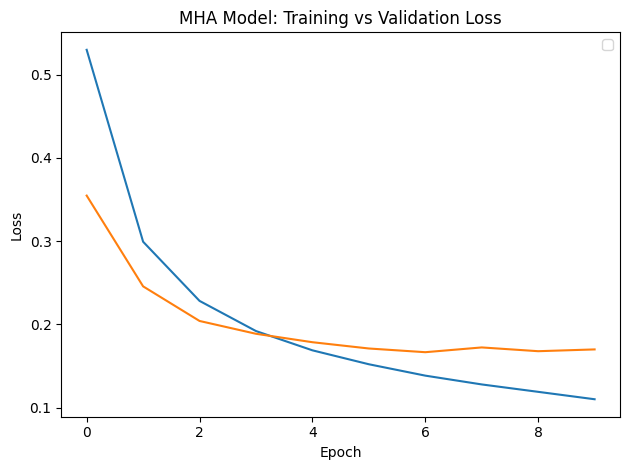

/tmp/ipykernel_55/3883659083.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


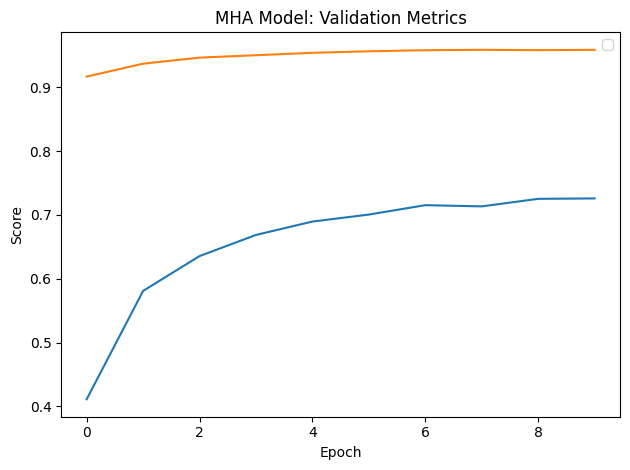

In [57]:
# TODO (Part 5): Plot training curves + evaluate on test + compare with earlier parts
#
# In this cell we will:
#   1) Plot the training/validation loss curves from your history dict
#   2) Plot validation F1 vs token accuracy (optional but recommended)
#   3) Evaluate the final/best MHA model on the test set
#   4) Optionally compare the test F1 to earlier parts (e.g., single-head with/without PE)
#
# Notes:
#   - This cell assumes you stored training logs in a dictionary (e.g., hist5 or history).
#   - It also assumes you have evaluate_attn(...) implemented (or an equivalent evaluator).
#   - Keep plotting readable: label axes, include legends, and avoid clutter.
#   - For comparisons, only compare runs that used the same splits + same metric logic.

epochs = range(len(history5["train_loss"]))
plt.figure()
plt.plot(epochs, history5["train_loss"])
plt.plot(epochs, history5["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MHA Model: Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(epochs, history5["val_f1"])
plt.plot(epochs, history["val_token_acc"])
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("MHA Model: Validation Metrics")
plt.legend()
plt.tight_layout()
plt.show()

In [58]:
test_metrics5 = evaluate_attn(mha_model, test_loader)

print(
    f"PART 5 TEST | "
    f"loss={test_metrics5['loss']:.4f} | "
    f"token_acc={test_metrics5['token_acc']:.4f} | "
    f"P={test_metrics5['precision']:.4f} | "
    f"R={test_metrics5['recall']:.4f} | "
    f"F1={test_metrics5['f1']:.4f}"
)

print("\n--- Comparison (if available) ---")
print(f"Part 3 (No PE) Test F1:  {test_metrics3['f1']:.4f}")
print(f"Part 4 (With PE) Test F1: {test_metrics4['f1']:.4f}")
print(f"Part 5 (MHA) Test F1:     {test_metrics5['f1']:.4f}")

PART 5 TEST | loss=0.1620 | token_acc=0.9585 | P=0.7107 | R=0.7408 | F1=0.7254

--- Comparison (if available) ---
Part 3 (No PE) Test F1:  0.5412
Part 4 (With PE) Test F1: 0.6589
Part 5 (MHA) Test F1:     0.7254


## Multi-Head Attention Maps (Interpretability) — TODO

In this cell we visualize **multi-head self-attention** on a single sentence to see whether different heads appear to specialize (e.g., local context vs. long-range links). We treat the plots as **diagnostics**, not as final explanations: we focus on correct token alignment, masking/cropping padded positions, and careful interpretation.


Tokens: ['On', 'Sunday', ',', 'several', 'major', 'newspapers', 'weighed', 'in', 'with', 'their', '<unk>', 'and', 'VOA', "'s", 'Peter', '<unk>', 'has', 'that', 'story', '.']
Pred  : ['O', 'B-DATE', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-ORG', 'O', 'B-PERSON', 'I-PERSON', 'O', 'O', 'O', 'O']


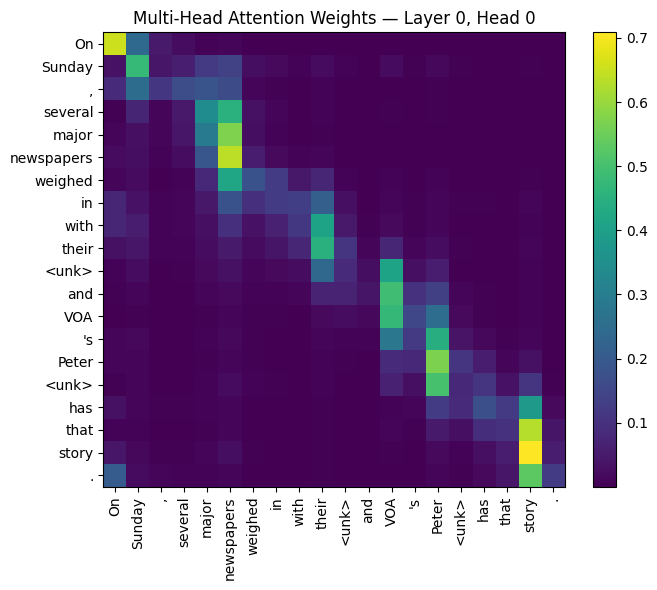

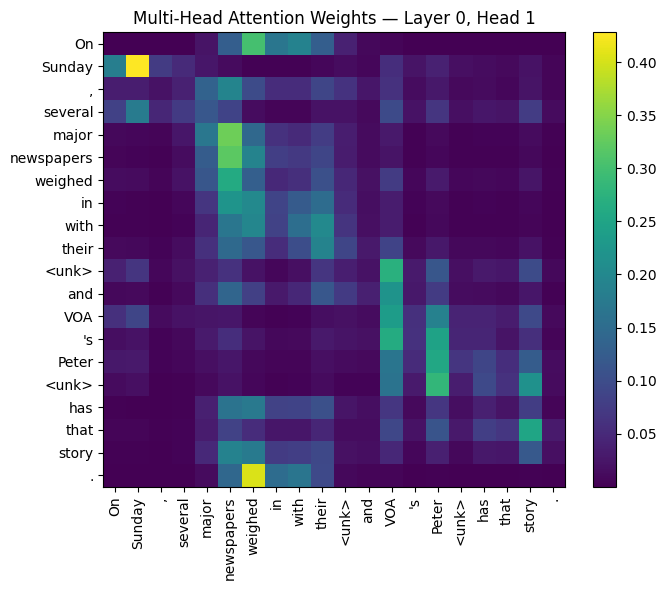

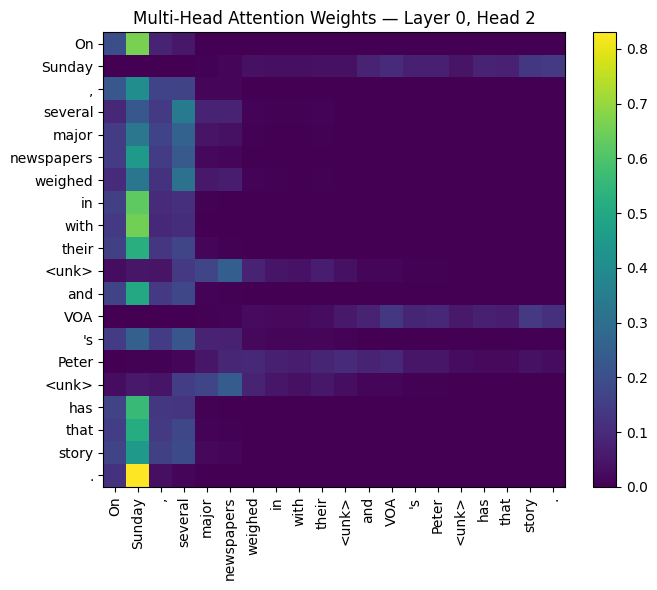

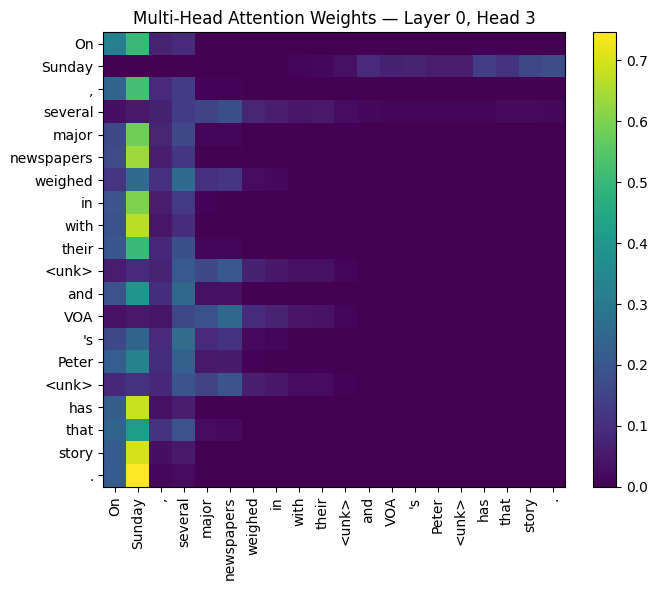

In [59]:
# TODO (Part 5): Multi-head attention visualization (interpretability mini-lab)
#
# Goal:
#   Visualize attention weights for several heads on ONE example sentence.
#
# Requirements (keep it general):
#   - Choose one example (from validation is recommended).
#   - Identify the true (unpadded) token span length and crop all visuals to it.
#   - Run the trained model in evaluation mode and obtain:
#       (a) token-level predictions (optional, for qualitative inspection)
#       (b) attention weights from ONE chosen layer
#   - Plot attention heatmaps for multiple heads (e.g., a small subset).
#
# What we should be careful about:
#   - Token alignment: axis tick labels must match the exact tokens being attended over.
#   - Padding: do not visualize padding rows/columns (crop before plotting).
#   - Interpretation: attention is a diagnostic signal, not a proof of explanation.
#
# Deliverable:
#   - A figure (or multiple figures) showing attention matrices per head.
#   - (Optional) print a compact token + predicted-tag view for the same example.

batch = next(iter(valid_loader))
input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)

example_idx = 10
example_ids = input_ids[example_idx:example_idx+1]        # [1, T]
example_mask = attention_mask[example_idx:example_idx+1]  # [1, T]

mha_model.eval()
with torch.no_grad():
    logits, attn_weights = mha_model(example_ids, attention_mask=example_mask, return_attn_layer=0) # [1, T, num_labels], [1, H, T, T]

L = int(example_mask.sum().item())
pred_ids = logits.argmax(dim=-1)[0][:L].cpu().tolist()

tokens = example_ids[0][:L].cpu().tolist()
token_strings = [itos[t] for t in tokens]
pred_strings = [id2label[p] for p in pred_ids]

print("Tokens:", token_strings)
print("Pred  :", pred_strings)

attn = attn_weights[0] # [H, T, T]
attn = attn[:, :L, :L] # [H, L, L]
for h in range(4):
    plt.figure(figsize=(7, 6))
    plt.imshow(attn[h].cpu(), aspect="auto")
    plt.colorbar()
    plt.xticks(range(L), token_strings, rotation=90)
    plt.yticks(range(L), token_strings)
    plt.title(f"Multi-Head Attention Weights — Layer 0, Head {h}")
    plt.tight_layout()
    plt.show()

## Concept Checks (answer in Markdown, no code)

1. In multi-head attention, we typically split the representation into subspaces of size:
   $$
   d_{\mathrm{head}} = \frac{d_{\mathrm{model}}}{H}.
   $$
   What is the intuition behind using smaller per-head dimensions instead of keeping one full-size attention?

   **My Answer**: The goal is specialization. If we used a single full-dimensional attention, it would have to represent all relational patterns in one similarity space. By splitting into smaller subspaces each head can focus on different types of relationships, one head might capture local context, another might capture long-range dependencies, another might focus on syntactic or entity-boundary cues. Each head operates in its own learned projection space (different Q/K/V projections), so it can develop a different notion of similarity. Afterward, we concatenate all heads, allowing the model to combine multiple relational perspectives.

2. Multi-head attention increases modeling capacity, but it also changes compute/memory usage.  
   Which part of attention has the dominant cost in sequence length **$T$**, and why?
   
   **My Answer**: The dominant cost in attention with respect to sequence length T is $O(T^2)$. Specifically, the expensive step is $QK^T$. This produces a [T × T] attention score matrix per head. This creates a full pairwise interaction matrix. Memory cost is also $O(T^2)$ because we must store the attention matrix. The projection layers (Q/K/V linear layers) are $O(T⋅d_{model}^2)$, but when $T$ becomes large, the quadratic $T^2$ term dominates. So the bottleneck in long sequences is the attention matrix itself, not the feed-forward network.

3. When we visualize attention heads, we might see different patterns per head.  
   Give **two plausible reasons** why heads can look different (even within the same layer).

   **My Answer**: Different attention heads can look different because each head has its own learned projection matrices (Q, K, V), meaning they compute similarity in different subspaces and therefore focus on different relational patterns in the sequence. Additionally, during training, optimization encourages heads to specialize rather than behave redundantly, leading some heads to capture local structure, others long-range dependencies, and others specific cues like entity boundaries or sentence structure.

# Part 6 — Going Deeper: A Tiny Transformer Encoder + Depth Ablation

In Parts 4–5, we saw that **positional information** makes attention usable for order-sensitive tagging, and that **multi-head attention** can represent multiple interaction patterns in parallel.

In this part we push one more core “Transformer/BERT idea”:

- instead of *one* encoder layer, we stack **multiple encoder blocks** (attention + feed-forward + residual + layer norm),
- and we treat the notebook like a small empirical study: **how does depth change NER performance?**

We will run a **depth ablation**: train several models that differ only in the **number of encoder layers**, while keeping the rest of the setup as controlled as possible (data, tokenizer/vocab, metric computation, optimization budget, etc.).

### What we should keep fixed (to make the ablation meaningful)

To interpret results correctly, we should try to change **one variable at a time**:

- keep the same dataset splits and evaluation function,
- keep the same embedding size and number of heads,
- keep positional encoding **on** (because Part 4 established it as necessary),
- keep the training recipe comparable (optimizer family, early stopping logic, etc.).

If we decide to change any of these, we should document it briefly (and explain why).

## Encoder Block (BERT-style): Attention + FFN + Residual + LayerNorm

In this cell we implement the **basic building block** of a Transformer encoder.  
The block has two sublayers—**multi-head self-attention** and a **position-wise feedforward network**—each wrapped with a **residual connection** and **LayerNorm**.

**Guiding questions:**
- What must stay shape-preserving so we can stack many layers cleanly?
- Where exactly do we apply masking so padding tokens do not affect attention?

In [60]:
# TODO: Implement a single BERT-style encoder block (a Transformer encoder layer).
#
# Requirements / expectations:
# - Inputs:
#   - x: Tensor of shape [B, T, D]
#   - attention_mask: optional Tensor of shape [B, T] (1 for real tokens, 0 for padding)
# - Core components (standard "encoder layer" recipe):
#   1) Multi-head self-attention sublayer (already available as MultiHeadSelfAttention)
#   2) Residual connection + LayerNorm
#   3) Position-wise feedforward network (MLP) sublayer
#   4) Residual connection + LayerNorm
# - Optional: support returning attention weights (return_attn=True)
#
# Notes:
# - Keep tensor shapes consistent across the block.
# - Masking must ensure padding tokens do not act as keys that receive attention.
# - Do NOT change the forward signature; later parts will rely on it.

class BertStyleEncoderBlock(nn.Module):
    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1, ff_mult: int = 4):
        super().__init__()
        self.mha = MultiHeadSelfAttention(d_model=d_model, num_heads=num_heads, dropout=dropout)
        self.attn_dropout = nn.Dropout(dropout)
        self.attn_norm = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(nn.Linear(d_model, ff_mult * d_model), nn.GELU(), nn.Dropout(dropout), nn.Linear(ff_mult * d_model, d_model))
        self.ffn_dropout = nn.Dropout(dropout)
        self.ffn_norm = nn.LayerNorm(d_model)

    def forward(self, x: torch.Tensor, attention_mask: torch.Tensor = None, return_attn: bool = False):
        attn_out, attn = self.mha(x, attention_mask=attention_mask, return_attn=True)
        x = self.attn_norm(x + self.attn_dropout(attn_out))
        ffn_out = self.ffn(x)
        x = self.ffn_norm(x + self.ffn_dropout(ffn_out))

        if return_attn:
            return x, attn
        else:
            return x

## Tiny Transformer Encoder for NER (BERT-style stack)

In this cell we define a **small Transformer encoder** for token classification.  
We stack multiple encoder blocks, optionally add **positional encoding**, and attach a **per-token classifier**.

**Guiding questions:**
- What tensor shapes must remain unchanged so the blocks can be stacked safely?
- Where should positional information be injected, and why *before* the blocks?
- What is the purpose of returning attention from a single selected layer instead of all layers?

In [61]:
# TODO: Implement a tiny Transformer-style encoder for NER.
#
# Goal:
# - Build a stack of BERT-style encoder blocks and attach a token-level classifier on top.
#
# Inputs / outputs:
# - input_ids: [B, T]
# - attention_mask: [B, T] (1 real token, 0 padding)
# - return logits: [B, T, num_labels]
# - Optional: return attention from a chosen layer (return_attn_layer)
#
# Design constraints:
# - Use nn.Embedding for token embeddings.
# - (Optionally) add positional encoding before the encoder blocks.
# - Use a ModuleList of BertStyleEncoderBlock.
# - Keep shapes consistent across layers: [B, T, D] in / out.
#
# Notes:
# - For stability, consider scaling embeddings by sqrt(d_model) (common in Transformers).
# - Masking should be applied inside attention blocks (keys must ignore padding).
# - return_attn_layer:
#     * if set to a valid layer index, that block should return attention weights too.
#     * if no attention requested, forward should return only logits.

class TinyEncoderForNER(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        num_labels: int,
        pad_id: int,
        d_model: int = 192,
        num_heads: int = 4,
        num_layers: int = 4,
        dropout: float = 0.1,
        max_len: int = 512,
        use_positional_encoding: bool = True,
    ):
        super().__init__()
        self.d_model = d_model
        self.num_layers = num_layers
        self.use_positional_encoding = use_positional_encoding
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.embed_dropout = nn.Dropout(dropout)
        if use_positional_encoding:
            self.positional_encoding = SinusoidalPositionalEncoding(d_model=d_model, max_len=max_len)
        else:
            self.positional_encoding = None
        self.layers = nn.ModuleList([BertStyleEncoderBlock(d_model=d_model, num_heads=num_heads, dropout=dropout) for _ in range(num_layers)])
        self.output_dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, num_labels)
        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.embedding.weight)
        nn.init.xavier_uniform_(self.classifier.weight)
        if self.classifier.bias is not None:
            nn.init.zeros_(self.classifier.bias)

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor = None,
        return_attn_layer: int = -1,
    ):
        x = self.embedding(input_ids) # [B, T, D]
        if self.positional_encoding is not None:
            x = self.positional_encoding(x) # [B, T, D]
        x = self.embed_dropout(x)

        attn_out = None
        for layer_idx, layer in enumerate(self.layers):
            if return_attn_layer == layer_idx:
                x, attn_out = layer(x, attention_mask=attention_mask, return_attn=True)
            else:
                x = layer(x, attention_mask=attention_mask, return_attn=False)
        x = self.output_dropout(x)
        logits = self.classifier(x)  # [B, T, num_labels]

        if return_attn_layer >= 0 and attn_out is not None:
            return logits, attn_out
        else:
            return logits

## Depth Ablation Runner (Fair Comparison Across Encoder Depths)

This cell defines a **single reusable training routine** used to compare models of different depth under the **same protocol** (same data, same metrics, same stopping rule).

In [70]:
# TODO: Implement a reusable training runner for the depth ablation study.
#
# Goal:
# - Train the same architecture while varying ONLY the number of encoder layers (depth).
# - Keep the training/evaluation protocol consistent across depths so the comparison is fair.
#
# Requirements / expectations:
# - Re-seed at the start (reproducibility).
# - Build a model whose depth is controlled by `num_layers`.
#   (You may use your Part 5/6 model class, or a TinyEncoder variant.)
# - Use a standard optimizer (e.g., AdamW) with provided lr/weight_decay.
# - Track history per epoch: train_loss, val_loss, val_token_acc, val_f1.
# - Use early stopping based on validation F1 (or a clearly justified alternative).
# - At the end, evaluate once on the test set and return:
#     (best_model, history_dict, best_val_f1, test_metrics_dict)
#
# Notes:
# - The core of this lab is controlled experimentation:
#   depth is the variable, everything else should be held fixed.

def train_mha_depth(
    num_layers: int,
    num_heads: int = 4,
    d_model: int = 192,
    lr: float = 5e-4,
    weight_decay: float = 0.02,
    max_epochs: int = 12,
    patience: int = 3,
):
    seed_everything(cfg.seed)

    model = TinyEncoderForNER(
        vocab_size=len(stoi),
        num_labels=num_labels,
        pad_id=stoi[cfg.pad_token],
        d_model=d_model,
        num_heads=num_heads,
        num_layers=num_layers,
        dropout=0.1,
        max_len=512,
        use_positional_encoding=True,
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_f1 = 0.0
    best_state = None
    bad_epochs = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_token_acc": [],
        "val_f1": [],
    }

    for epoch in range(1, max_epochs + 1):
        train_loss = train_one_epoch_attn(model, train_loader, optimizer)
        val_metrics = evaluate_attn(model, valid_loader)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics['loss'])
        history["val_token_acc"].append(val_metrics['token_acc'])
        history["val_f1"].append(val_metrics['f1'])

        print(
            f"[depth={num_layers}] "
            f"Epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_token_acc={val_metrics['token_acc']:.4f} | "
            f"val_F1={val_metrics['f1']:.4f}"
        )

        current_f1 = val_metrics['f1']
        if current_f1 > best_f1:
            best_f1 = current_f1
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    test_metrics = evaluate_attn(model, test_loader)
    return model, history, best_f1, test_metrics

## Run the Depth Sweep (Ablation Driver)

In this cell we run the **depth ablation**: the same encoder design trained multiple times while varying **only** the number of stacked layers.

In [71]:
# TODO: Depth ablation driver (you design this).
#
# Goal:
# - Run multiple training runs where the ONLY controlled change is encoder depth.
# - Log enough information to compare runs later (plots + a small summary table).
#
# What YOU decide:
# - Which depths to test
# - How many epochs / what early stopping rule
# - What to store (histories, best checkpoint, test metrics, etc.)
# - How to organize results (list, dict, DataFrame, files, etc.)
#
# Constraints:
# - Keep everything else fixed (same data splits, tokenizer/vocab, optimizer family, metrics)
# - Make the output readable (clear separators, concise prints)

depths_to_test = [1, 2, 4, 6]
max_epochs = 10
patience = 5
depth_results = {}
for depth in depths_to_test:
    print("\n" + "=" * 70)
    model, hist, best_val_f1, test_metrics = train_mha_depth(num_layers=depth, num_heads=4, d_model=192, lr=5e-4, weight_decay=0.02, max_epochs=max_epochs, patience=patience)

    depth_results[depth] = {
        "history": hist,
        "best_val_f1": best_val_f1,
        "test_metrics": test_metrics,
        "num_epochs_trained": len(hist["train_loss"]),
        "model_state_dict": copy.deepcopy(model.state_dict())
    }

    print(
        f"[depth={depth}] TEST | "
        f"loss={test_metrics['loss']:.4f} | "
        f"token_acc={test_metrics['token_acc']:.4f} | "
        f"P={test_metrics['precision']:.4f} | "
        f"R={test_metrics['recall']:.4f} | "
        f"F1={test_metrics['f1']:.4f}"
    )


[depth=1] Epoch 01 | train_loss=0.4161 | val_loss=0.2566 | val_token_acc=0.9341 | val_F1=0.5196
[depth=1] Epoch 02 | train_loss=0.1994 | val_loss=0.2037 | val_token_acc=0.9481 | val_F1=0.6259
[depth=1] Epoch 03 | train_loss=0.1524 | val_loss=0.1730 | val_token_acc=0.9550 | val_F1=0.6930
[depth=1] Epoch 04 | train_loss=0.1288 | val_loss=0.1692 | val_token_acc=0.9565 | val_F1=0.6970
[depth=1] Epoch 05 | train_loss=0.1129 | val_loss=0.1705 | val_token_acc=0.9572 | val_F1=0.7115
[depth=1] Epoch 06 | train_loss=0.1015 | val_loss=0.1720 | val_token_acc=0.9568 | val_F1=0.7089
[depth=1] Epoch 07 | train_loss=0.0924 | val_loss=0.1699 | val_token_acc=0.9571 | val_F1=0.7098
[depth=1] Epoch 08 | train_loss=0.0841 | val_loss=0.1788 | val_token_acc=0.9586 | val_F1=0.7196
[depth=1] Epoch 09 | train_loss=0.0781 | val_loss=0.1787 | val_token_acc=0.9581 | val_F1=0.7217
[depth=1] Epoch 10 | train_loss=0.0725 | val_loss=0.1869 | val_token_acc=0.9570 | val_F1=0.7076
[depth=1] TEST | loss=0.1672 | token_ac

## Plot Curves Across Depths (Train/Val Loss + Val F1)

In this cell we compare **training dynamics** across different encoder depths by plotting learning curves.  
We are not trying to “win” with one model yet — we are trying to understand *how depth changes behavior*.

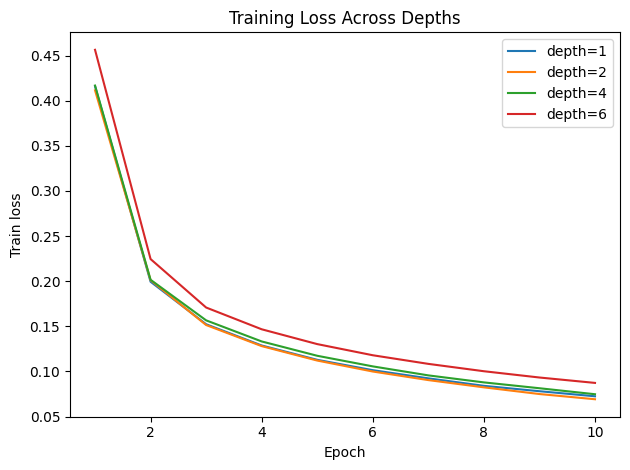

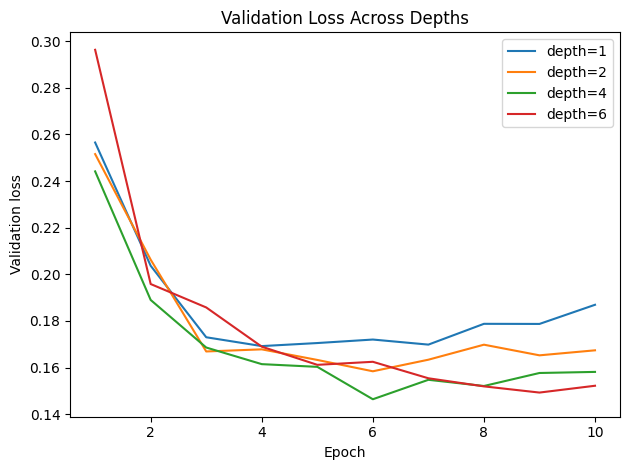

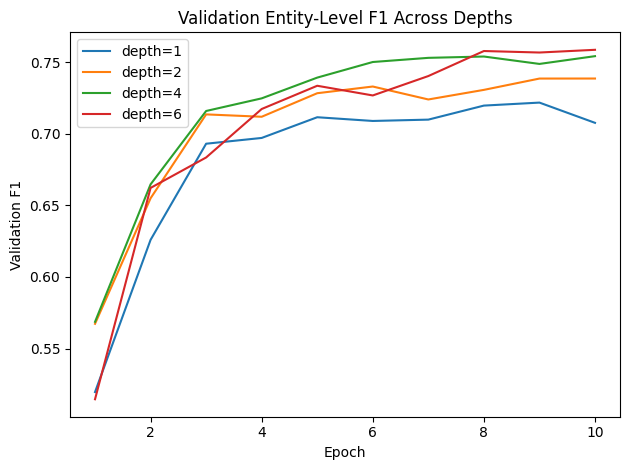

In [77]:
# TODO: Plot learning curves across depth runs.
#
# Goal:
# - Visualize how optimization and generalization change as depth increases.
# - At minimum, plot (vs epoch):
#   1) training loss
#   2) validation loss
#   3) validation entity-level F1
#
# What YOU decide:
# - How results are stored and accessed (lists, dicts, DataFrames, files, etc.)
# - Which depths to include and how to label them
# - How to handle runs that stopped early (different epoch lengths)
#
# Tips (not requirements):
# - Use consistent axes and legends across plots
# - If epoch lengths differ, plot each curve with its own x-range
# - Keep plots readable (labels, titles, legend)

plt.figure()
for depth, results in depth_results.items():
    hist = results["history"]
    epochs = range(1, len(hist["train_loss"]) + 1)
    plt.plot(epochs, hist["train_loss"], label=f"depth={depth}")
plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.title("Training Loss Across Depths")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
for depth, results in depth_results.items():
    hist = results["history"]
    epochs = range(1, len(hist["val_loss"]) + 1)
    plt.plot(epochs, hist["val_loss"], label=f"depth={depth}")
plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Validation Loss Across Depths")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
for depth, results in depth_results.items():
    hist = results["history"]
    epochs = range(1, len(hist["val_f1"]) + 1)
    plt.plot(epochs, hist["val_f1"], label=f"depth={depth}")
plt.xlabel("Epoch")
plt.ylabel("Validation F1")
plt.title("Validation Entity-Level F1 Across Depths")
plt.legend()
plt.tight_layout()
plt.show()

## Depth Ablation Summary Table

In this cell we summarize the depth experiment in a **single table** so we can compare depths without scanning logs.  
The point is to connect *capacity* (depth/parameters) with *generalization* (validation/test entity-level F1).

In [78]:
# TODO: Build a depth-ablation summary table (one row per depth).
#
# Goal:
# - Create a compact table that lets us compare depths at a glance.
# - Include, at minimum:
#   • number of layers (depth)
#   • best validation entity-level F1
#   • test entity-level F1
#   • test loss (optional but useful)
#   • parameter count (optional but useful)
#
# What YOU decide:
# - Where these numbers come from (your stored logs, a dict of runs, a CSV, etc.)
# - How you compute parameter counts (if you include them)
# - How you handle missing metrics or early-stopped runs
#
# Output:
# - A pandas DataFrame sorted by depth, displayed in the notebook.

rows = []
for depth, results in depth_results.items():
    history = results["history"]
    test_metrics = results["test_metrics"]
    best_val_f1 = max(history["val_f1"]) if len(history["val_f1"]) > 0 else None
    test_f1 = test_metrics.get("f1", None)
    test_loss = test_metrics.get("loss", None)
    model_for_count = TinyEncoderForNER(
        vocab_size=len(stoi),
        num_labels=num_labels,
        pad_id=stoi[cfg.pad_token],
        d_model=192,
        num_heads=4,
        num_layers=depth,
        dropout=0.1,
        max_len=512,
        use_positional_encoding=True,
    )
    param_count = sum(p.numel() for p in model_for_count.parameters())
    rows.append({
        "depth": depth,
        "best_val_F1": best_val_f1,
        "test_F1": test_f1,
        "test_loss": test_loss,
        "num_parameters": param_count,
    })

df_depth_summary = pd.DataFrame(rows)
df_depth_summary = df_depth_summary.sort_values("depth").reset_index(drop=True)
df_depth_summary

,depth,best_val_F1,test_F1,test_loss,num_parameters
0,1,0.721701,0.725231,0.167210,5035429
1,2,0.738508,0.740537,0.156113,5480293
2,4,0.754124,0.758262,0.143339,6370021
3,6,0.758561,0.769004,0.141739,7259749


## Visualizing the Depth Ablation

In this cell we visualize the most important ablation trend: how **test entity-level F1** changes as we increase the **number of encoder layers**.

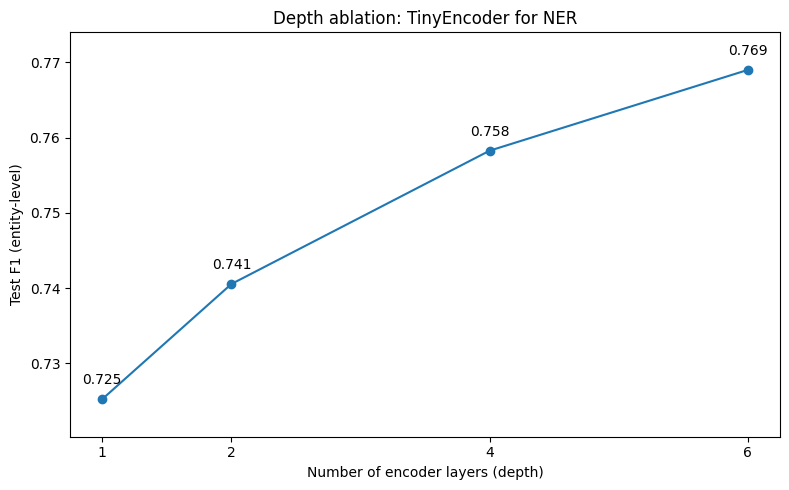

In [79]:
# TODO: Plot "depth (number of layers)" vs "test entity-level F1" for the depth ablation.
#
# Requirements:
# - Use your summary table / results structure from the previous cell.
# - X axis: depth (number of encoder layers)
# - Y axis: test F1 (entity-level)
#
# Nice-to-have:
# - Mark each point clearly (e.g., with markers)
# - Annotate each point with its F1 value
# - Keep axes labels + title informative
#
# Notes:
# - If you store results in a different schema than res_df, adapt accordingly.
# - If you do not have test results for some depths, decide how to handle them
#   (skip, mark as NaN, etc.) and explain briefly.

depths = df_depth_summary["depth"].values
test_f1 = df_depth_summary["test_F1"].values
plt.figure(figsize=(8, 5))
plt.plot(depths, test_f1, marker="o")

for x, y in zip(depths, test_f1):
    plt.text(x, y + 0.002, f"{y:.3f}", ha="center")

plt.xlabel("Number of encoder layers (depth)")
plt.ylabel("Test F1 (entity-level)")
plt.title("Depth ablation: TinyEncoder for NER")
plt.xticks(depths)
plt.ylim(min(test_f1) - 0.005, max(test_f1) + 0.005)
plt.tight_layout()
plt.show()

## Choosing the Best Depth and Inspecting What the Model Learned

Now that we have trained multiple Transformer depths, we do two “research-lab” steps:

1) **Model selection:** we pick the depth that performs best on **test entity-level F1** (with a clear tie-break if needed).  
2) **Qualitative inspection:** we look at one validation sentence, compare predicted tags to tokens, and visualize attention maps if our model exposes them.

In [80]:
# ============================================================
# TODO (Part 6): Pick the "best depth" based on TEST F1
# ============================================================
#
# Goal:
# - From your depth ablation results, select the depth (number of layers) that achieves
#   the highest TEST entity-level F1.
#
# What to define here:
# - best_L: the chosen depth (int)
# - best_model: the trained model at that depth
# - best_test_f1: the corresponding test F1 (float or None)
#
# Notes:
# - Be consistent with how you stored results (dict, DataFrame, list of runs, etc.).
# - If multiple depths tie, choose a tie-break rule (e.g., fewer params, earlier epoch, etc.)
#   and mention it briefly in a Markdown note.

best_L = None
best_model = None
best_test_f1 = -1.0

for depth, results in depth_results.items():
    test_f1 = results["test_metrics"].get("f1", None)
    if (test_f1 > best_test_f1) or (test_f1 == best_test_f1 and (best_L is None or depth < best_L)):
        best_test_f1 = test_f1
        best_L = depth
        best_state_dict = results["model_state_dict"]

print(f"Best depth (based on TEST F1): {best_L}")
print(f"Best TEST F1: {best_test_f1:.4f}")

Best depth (based on TEST F1): 6
Best TEST F1: 0.7690



--- Example Preview ---
A               -> O
Russian         -> B-NORP
<unk>           -> O
has             -> O
found           -> O
the             -> O
bodies          -> O
of              -> O
three           -> B-CARDINAL
of              -> O
the             -> O
118             -> B-CARDINAL
sailors         -> O
who             -> O
were            -> O
killed          -> O
when            -> O
the             -> O
nuclear         -> O
submarine       -> O
Kursk           -> B-PRODUCT
<unk>           -> I-PRODUCT
in              -> O
the             -> B-LOC
Barents         -> I-LOC


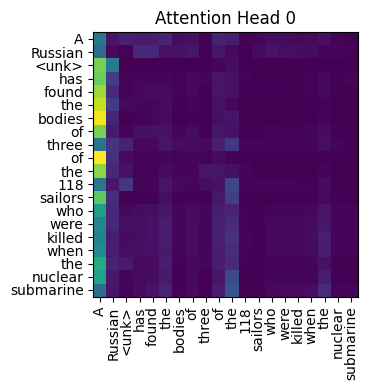

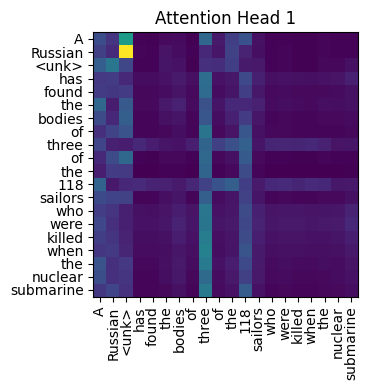

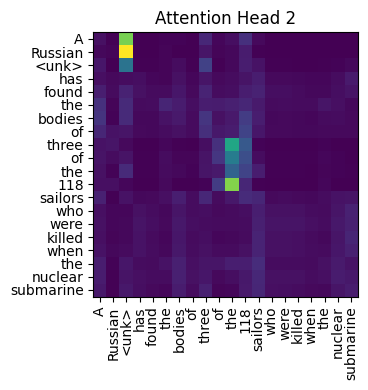

In [87]:
# ============================================================
# TODO (Part 6): Inspect one example + (optional) visualize attention
# ============================================================
#
# Goal:
# - Take ONE validation example (batch of size 1 is fine).
# - Run best_model to produce token-level predictions.
# - Optionally: if your model supports returning attention, visualize a few heads.
#
# What to be careful about:
# - Use the real (unpadded) length when decoding/printing tokens and when cropping attention maps.
# - If your model does NOT support returning attention, gracefully skip the visualization step.
#
# Suggested outputs:
# - Print the first L tokens
# - Print predicted tags for those L tokens
# - (Optional) show attention heatmaps for a chosen layer and a few heads

example_batch = next(iter(valid_loader))
input_ids = example_batch["input_ids"][:1].to(device)
attention_mask = example_batch["attention_mask"][:1].to(device)
true_len = attention_mask[0].sum().item()

best_model = TinyEncoderForNER(
    vocab_size=len(stoi),
    num_labels=len(id2label),
    pad_id=stoi[cfg.pad_token],
    d_model=192,
    num_heads=4,
    num_layers=best_L,
    dropout=0.1,
    max_len=512,
    use_positional_encoding=True
).to(device)
best_model.load_state_dict(best_state_dict)
best_model.eval()
with torch.no_grad():
    logits, attn = best_model(input_ids, attention_mask=attention_mask, return_attn_layer=best_L-1)

pred_ids = logits.argmax(dim=-1)[0][:true_len].cpu().tolist()
tokens = input_ids[0][:true_len].cpu().tolist()
decoded_tokens = [itos[t] for t in tokens]
decoded_preds = [id2label[p] for p in pred_ids]

print("\n--- Example Preview ---")
for tok, tag in zip(decoded_tokens[:25], decoded_preds[:25]):
    print(f"{tok:15s} -> {tag}")

attn_tensor = attn
if attn_tensor.dim() == 5:
    attn_tensor = attn_tensor[:, 0]  # [B, H, T, T]
attn_tensor = attn_tensor[0]  # [H, T, T]
num_heads = attn_tensor.size(0)
heads_to_show = min(3, num_heads)
L = min(true_len, 20)

for h in range(heads_to_show):
    plt.figure(figsize=(5, 4))
    plt.imshow(attn_tensor[h][:L, :L].cpu())
    plt.title(f"Attention Head {h}")
    plt.xticks(range(L), decoded_tokens[:L], rotation=90)
    plt.yticks(range(L), decoded_tokens[:L])
    plt.tight_layout()
    plt.show()

## Concept Checks (answer in Markdown, no code)

1) **Depth vs. capacity:**  
   What changes when we increase the number of encoder layers? Is it only “more parameters,” or also “more computation steps for composition”?

   **My Answe**: Increasing the number of encoder layers changes not only the number of parameters but also the number of sequential computation steps applied to each token representation. While deeper models do introduce more parameters, the more important change is that representations are refined through multiple rounds of context mixing and nonlinear transformation. Each layer composes information from the previous one, allowing progressively more abstract and globally informed features to emerge. Thus, depth increases both capacity and the ability to perform multi-step compositional reasoning over the sentence.

2) **Qualitative inspection:**  
   When we inspect one sentence, what kinds of NER errors should we categorize?
   
   **My Answer**: When inspecting a single sentence’s predictions, NER errors should be categorized into boundary errors (partial spans), type errors (correct span but wrong label), missing entities (false negatives), spurious entities (false positives), and fragmentation errors (entity split across inconsistent tags). Organizing errors this way helps distinguish whether the model struggles with span detection, semantic classification, contextual ambiguity, or over-triggering on superficial cues like capitalization or numbers.

   Which error types are most likely to be improved by “more context mixing” across layers?

   **My Answr**: Error types most likely to improve with increased depth are those that require broader contextual integration, such as boundary inconsistencies and type confusions for ambiguous entities (e.g., names that could be PERSON, ORG, or LOC). Deeper models allow tokens to repeatedly exchange information, which strengthens span coherence and enables disambiguation based on global sentence meaning. Long-range dependency errors also benefit from additional layers, whereas purely lexical memorization failures or dataset bias issues are less likely to be fixed by increasing depth alone.

# Part 7 — A Tiny BERT-Like Encoder

In Parts 3–6 we explored attention-only models and the effect of positional information.  
In this part, we move one step closer to **BERT-style inputs and embeddings**:

- We extend our **word-level vocabulary** with special tokens: `[CLS]`, `[SEP]`, `[MASK]`.
- We build a dataset and collate function that produce the typical BERT inputs:
  - `input_ids`
  - `token_type_ids` (segment IDs)
  - `position_ids`
  - `attention_mask`
  - `labels` aligned with the tokens (and ignored on special tokens)
- We implement a **TinyBERT-like** encoder:
  - token + position + segment embeddings
  - stacked Transformer encoder blocks
  - token-level classifier head for NER

The goal is not to reproduce pretrained BERT performance, but to understand **the full input pipeline and architectural ingredients** that make BERT “BERT”.

## Add BERT Special Tokens to the Vocabulary

We ensure `[CLS]`, `[SEP]`, and `[MASK]` exist in our word-level vocabulary so later “BERT-style” dataset and model code can reference them reliably.

In [88]:
BERT_CLS = "[CLS]"
BERT_SEP = "[SEP]"
BERT_MASK = "[MASK]"


def add_special_tokens_to_vocab(
    stoi: Dict[str, int],
    special_tokens: List[str],
) -> Tuple[Dict[str, int], Dict[int, str]]:
    """
    Ensure required special tokens exist in the word-level vocabulary.

    Args:
        stoi: token -> id mapping (will be updated in-place)
        special_tokens: list of tokens to add if missing

    Returns:
        (stoi, itos) where itos is id -> token mapping
    """
    for tok in special_tokens:
        if tok not in stoi:
            stoi[tok] = len(stoi)

    itos = {i: s for s, i in stoi.items()}
    return stoi, itos


stoi, itos = add_special_tokens_to_vocab(stoi, [BERT_CLS, BERT_SEP, BERT_MASK])

print("Vocab size:", len(stoi))
print(
    "IDs:",
    {t: stoi[t] for t in [cfg.pad_token, cfg.unk_token, BERT_CLS, BERT_SEP, BERT_MASK]},
)

Vocab size: 23875
IDs: {'<pad>': 0, '<unk>': 1, '[CLS]': 23872, '[SEP]': 23873, '[MASK]': 23874}


## Build a BERT-Style NER Dataset

We wrap the raw NER data into a BERT-like input format by inserting `[CLS]`/`[SEP]`, truncating to a maximum length, converting tokens to ids, and aligning labels so that special tokens use `ignore_index`.

In [89]:
class NERBertInputDataset(Dataset):
    """
    A dataset that converts word-level NER examples into a BERT-style format:

      tokens  -> [CLS] tokens ... [SEP]
      labels  -> ignore_index for special tokens, original labels for real tokens
      ids     -> token ids from `stoi`
      token_type_ids -> all zeros for single-sequence inputs

    Notes:
      - `max_len` counts *all* tokens, including [CLS] and [SEP].
      - Truncation must keep tokens/labels aligned.
    """

    def __init__(self, hf_split, stoi: Dict[str, int], max_len: int = 256):
        self.split = hf_split
        self.stoi = stoi
        self.max_len = max_len  # includes [CLS] and [SEP]

    def __len__(self) -> int:
        return len(self.split)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        # TODO: Read the raw example from the HF split
        ex = self.split[idx]
        tokens = ex["tokens"]
        labels = ex["ner_tags"]

        # TODO: Truncate to (self.max_len - 2) to make room for [CLS] and [SEP]
        max_tokens = self.max_len - 2
        tokens = tokens[:max_tokens]
        labels = labels[:max_tokens]

        # TODO: Add special tokens
        bert_tokens = [BERT_CLS] + tokens + [BERT_SEP]

        # TODO: Map tokens to ids using `self.stoi`
        #   - unknown tokens should map to `self.stoi[cfg.unk_token]`
        input_ids = [self.stoi.get(tok, self.stoi[cfg.unk_token]) for tok in bert_tokens]

        # TODO: Align labels to `bert_tokens`
        #   - special tokens ([CLS], [SEP]) should have label = cfg.ignore_index
        bert_labels = [cfg.ignore_index] + labels + [cfg.ignore_index]

        # TODO: Build token_type_ids (all zeros for one segment)
        token_type_ids = [0] * len(input_ids)

        # TODO: Return a dict with torch tensors and (optionally) the raw tokens for debugging
        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "token_type_ids": torch.tensor(token_type_ids, dtype=torch.long),
            "labels": torch.tensor(bert_labels, dtype=torch.long),
            "tokens": bert_tokens,
        }

## BERT-Style Collation for NER (Padding, Masks, Positions)

We implement a custom `collate_fn` that pads variable-length BERT-formatted sequences, builds an `attention_mask`, generates `position_ids`, and pads labels using `ignore_index` so loss is computed only on real tokens.

In [90]:
def bert_ner_collate_fn(batch: List[Dict]) -> Dict[str, torch.Tensor]:
    """
    TODO (students): Implement a BERT-style collate_fn for NER.

    Inputs (per example in `batch`):
      - "input_ids":      LongTensor of shape [L]
      - "token_type_ids": LongTensor of shape [L]
      - "labels":         LongTensor of shape [L] (with cfg.ignore_index on special tokens)
      - "tokens":         List[str] (optional, for debugging)

    Requirements (your output dict MUST contain):
      - input_ids:      [B, T] padded with PAD id
      - token_type_ids: [B, T] padded appropriately
      - attention_mask: [B, T] where 1 = real token, 0 = padding
      - position_ids:   [B, T] containing positions 0..T-1 (per row)
      - labels:         [B, T] padded with cfg.ignore_index
      - tokens:         list of token lists (optional but useful for debugging)
      - lengths:        [B] original (unpadded) lengths

    Notes:
      - Do NOT change label values except padding positions.
      - Ensure shapes match across all returned tensors.

    After implementing, run a quick sanity-check:
      - One batch from the loader and verify shapes match.
      - Verify attention_mask sums equal lengths.
    """
    pad_id = stoi[cfg.pad_token]
    ignore_index = cfg.ignore_index
    lengths = torch.tensor([len(ex["input_ids"]) for ex in batch], dtype=torch.long)
    B = len(batch)
    T = max(lengths).item()
    input_ids = torch.full((B, T), pad_id, dtype=torch.long)
    token_type_ids = torch.zeros((B, T), dtype=torch.long)
    attention_mask = torch.zeros((B, T), dtype=torch.long)
    labels = torch.full((B, T), ignore_index, dtype=torch.long)
    tokens_list = []

    for i, ex in enumerate(batch):
        L = lengths[i].item()
        input_ids[i, :L] = ex["input_ids"]
        token_type_ids[i, :L] = ex["token_type_ids"]
        labels[i, :L] = ex["labels"]
        attention_mask[i, :L] = 1
        tokens_list.append(ex["tokens"])
    position_ids = torch.arange(T).unsqueeze(0).expand(B, T)

    return {
        "input_ids": input_ids,
        "token_type_ids": token_type_ids,
        "attention_mask": attention_mask,
        "position_ids": position_ids,
        "labels": labels,
        "tokens": tokens_list,
        "lengths": lengths,
    }

In [101]:
train_ds = NERBertInputDataset(ds["train"], stoi)
valid_ds = NERBertInputDataset(ds["validation"], stoi)
test_ds  = NERBertInputDataset(ds["test"], stoi)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    collate_fn=bert_ner_collate_fn,
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    collate_fn=bert_ner_collate_fn,
)

test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    collate_fn=bert_ner_collate_fn,
)

## BERT-Style Embeddings (Token + Position + Segment)

We implement the embedding layer used in BERT-like encoders by combining token embeddings with positional and segment/type embeddings, then applying normalization and dropout before passing representations to the encoder blocks.

In [102]:
class BertEmbeddings(nn.Module):
    """
    TODO (students): Implement BERT-style input embeddings.

    Goal:
      Build the embedding representation X for each token position by combining:
        1) token embeddings (lookup by input_ids)
        2) position embeddings (lookup by position_ids)
        3) segment/type embeddings (lookup by token_type_ids)

      Then apply:
        - LayerNorm
        - Dropout

    Inputs:
      - input_ids:      LongTensor [B, T]
      - token_type_ids: LongTensor [B, T] (optional; if None, treat as all zeros)
      - position_ids:   LongTensor [B, T] (optional; if None, build 0..T-1 for each row)

    Output:
      - embeddings: FloatTensor [B, T, d_model]

    Design requirements:
      - Use nn.Embedding for token, position, and segment embeddings.
      - Support variable sequence lengths up to `max_len`.
      - Do NOT assume token_type_ids exist in the dataset (must handle None).
      - Keep the interface compatible with later encoder blocks.

    Optional (if you want BERT-like initialization):
      - Initialize embedding weights with Normal(mean=0, std=0.02).
    """
    def __init__(
        self,
        vocab_size: int,
        d_model: int,
        pad_id: int,
        max_len: int = 512,
        type_vocab_size: int = 2,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.token_embeddings = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.position_embeddings = nn.Embedding(max_len, d_model)
        self.segment_embeddings = nn.Embedding(type_vocab_size, d_model)
        self.layer_norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self._init_weights()

    def _init_weights(self):
        for module in [self.token_embeddings,
                       self.position_embeddings,
                       self.segment_embeddings]:
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(
        self,
        input_ids: torch.Tensor,
        token_type_ids: torch.Tensor = None,
        position_ids: torch.Tensor = None,
    ) -> torch.Tensor:

        B, T = input_ids.shape
        device = input_ids.device

        if token_type_ids is None:
            token_type_ids = torch.zeros_like(input_ids, device=device)
        if position_ids is None:
            position_ids = torch.arange(T, device=device).unsqueeze(0).expand(B, T)

        token_emb = self.token_embeddings(input_ids)
        pos_emb = self.position_embeddings(position_ids)
        seg_emb = self.segment_embeddings(token_type_ids)
        embeddings = token_emb + pos_emb + seg_emb
        embeddings = self.layer_norm(embeddings)
        embeddings = self.dropout(embeddings)
        return embeddings  # [B, T, d_model]

## Tiny BERT-Like Encoder for NER

We define a small BERT-style model for token classification: BERT-like embeddings, a stack of Transformer encoder blocks, and a token-level classifier head. The forward pass may optionally return an attention matrix from a chosen layer for interpretability.

In [181]:
class TinyBertLikeForNER(nn.Module):
    """
    TODO (students): Implement a tiny BERT-like encoder for NER.

    High-level structure:
      1) BERT-style embeddings (token + position + segment/type)
      2) Stack of encoder blocks (multi-head self-attention + FFN + residuals + LayerNorm)
      3) Token-level classifier: Linear(d_model -> num_labels)

    Forward should optionally return attention from one chosen layer:
      - If return_attn_layer >= 0, return (logits, attn)
      - Otherwise return logits only
    """
    def __init__(
        self,
        vocab_size: int,
        num_labels: int,
        pad_id: int,
        d_model: int = 192,
        num_heads: int = 4,
        num_layers: int = 4,
        dropout: float = 0.1,
        max_len: int = 512,
    ):
        super().__init__()
        self.emb = BertEmbeddings(vocab_size=vocab_size, d_model=d_model, pad_id=pad_id, max_len=max_len, dropout=dropout)
        self.layers = nn.ModuleList([BertStyleEncoderBlock(d_model=d_model, num_heads=num_heads, dropout=dropout) for _ in range(num_layers)])
        self.out_dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, num_labels)
        nn.init.xavier_uniform_(self.classifier.weight)
        nn.init.zeros_(self.classifier.bias)

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor = None,
        token_type_ids: torch.Tensor = None,
        position_ids: torch.Tensor = None,
        return_attn_layer: int = -1,
    ):
        x = self.emb(input_ids=input_ids, token_type_ids=token_type_ids, position_ids=position_ids)  # [B, T, d_model]

        for i, layer in enumerate(self.layers):
            if i == return_attn_layer:
                x, attn = layer(x, attention_mask=attention_mask, return_attn=True)
            else:
                x = layer(x, attention_mask=attention_mask, return_attn=False)

        x = self.out_dropout(x)
        logits = self.classifier(x)  # [B, T, num_labels]

        if return_attn_layer >= 0:
            return logits, attn
        return logits

## Inspect a BERT-Style Batch Example

We print one example from `train_bert_loader` to confirm that tokens, labels, attention masks, token-type ids, and position ids are aligned correctly—especially around `[CLS]`, `[SEP]`, padding, and `ignore_index`.

In [182]:
batch = next(iter(train_loader))

bs = len(batch["tokens"])
idx = 1 if bs > 1 else 0
print(f"BATCH SIZE: {bs} | showing example index: {idx}")

tokens = batch["tokens"][idx]
labels = batch["labels"][idx].tolist()
token_type_ids = batch["token_type_ids"][idx].tolist()
position_ids = batch["position_ids"][idx].tolist()
attention_mask = batch["attention_mask"][idx].tolist()

L = int(sum(attention_mask))  # number of real (non-pad) tokens
print("TOKENS         :", tokens[:L])
print("TOKEN_TYPE_IDS :", token_type_ids[:L])
print("POSITION_IDS   :", position_ids[:L])
print("LABELS         :", labels[:L], f"(ignore_index = {cfg.ignore_index})")

BATCH SIZE: 32 | showing example index: 1
TOKENS         : ['[CLS]', 'Chien', '-', 'chien', "'s", 'teacher', 'has', 'told', 'my', 'wife', 'that', 'Chien', '-', 'chien', "'s", 'French', 'is', 'very', 'good', '.', '[SEP]']
TOKEN_TYPE_IDS : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
POSITION_IDS   : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
LABELS         : [-100, 4, 5, 5, 5, 0, 0, 0, 0, 0, 0, 4, 5, 5, 5, 33, 0, 0, 0, 0, -100] (ignore_index = -100)


## Sanity Check: Forward Pass Shapes

We instantiate the tiny BERT-like model and run one batch through it to confirm tensor shapes and device placement. This helps catch silent bugs early (especially with padding masks and sequence length handling).

In [183]:
# ---- Instantiate TinyBertLikeForNER + sanity-check shapes ----
tiny_bert = TinyBertLikeForNER(
    vocab_size=len(stoi),
    num_labels=num_labels,
    pad_id=stoi[cfg.pad_token],
    d_model=192,
    num_heads=4,
    num_layers=4,
    dropout=0.1,
    max_len=256,
).to(device)

# `batch` is assumed to come from train_bert_loader in a previous cell
input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)
token_type_ids = batch["token_type_ids"].to(device)
position_ids = batch["position_ids"].to(device)
logits = tiny_bert(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, position_ids=position_ids)

print("input_ids:", input_ids.shape)
print("logits   :", logits.shape, "(expected [B, T, num_labels])")

input_ids: torch.Size([32, 43])
logits   : torch.Size([32, 43, 37]) (expected [B, T, num_labels])


## Training and Evaluation Loops for the TinyBERT-like Model

We implement the core learning logic: a training loop (forward → loss → backward → update) and an evaluation loop that reports masked loss, token accuracy, and entity-level NER metrics (precision/recall/F1). These functions must correctly ignore padding and special-token positions using `cfg.ignore_index`.

In [184]:
# TODO: Training + Evaluation loops for TinyBERT-like
#
# Goal:
#   - Implement one epoch of training for a BERT-style model
#   - Implement evaluation that returns loss + token accuracy + NER F1
#
# Notes:
#   - Your batch contains: input_ids, labels, attention_mask,
#     token_type_ids, position_ids (plus tokens/lengths).
#   - Use cfg.ignore_index to ignore padding/[CLS]/[SEP] labels in loss + metrics.
#   - Keep your implementation modular so you can reuse it later.

def train_one_epoch_bert(model, loader, optimizer, grad_clip: float = 1.0):
    """
    TODO:
      1) Set model to train mode.
      2) Loop over batches:
         - move tensors to device
         - forward pass (make sure to pass attention_mask, token_type_ids, position_ids)
         - compute loss (masked by cfg.ignore_index)
         - backward + gradient clipping
         - optimizer step
      3) Return average loss per *real token* (not per batch).
    """
    model.train()
    total_loss = 0.0
    total_tokens = 0

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        position_ids = batch["position_ids"].to(device)
        labels = batch["labels"].to(device)
        optimizer.zero_grad()
        logits = model(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, position_ids=position_ids)
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), labels.view(-1), ignore_index=cfg.ignore_index, reduction="sum")
        loss.backward()
        if grad_clip:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        mask = labels != cfg.ignore_index
        num_tokens = mask.sum().item()
        total_loss += loss.item()
        total_tokens += num_tokens

    return total_loss / total_tokens

@torch.no_grad()
def evaluate_bert(model, loader):
    """
    TODO:
      1) Set model to eval mode.
      2) Loop over batches:
         - move tensors to device
         - forward pass
         - compute total loss over real tokens
         - compute token-level accuracy on non-ignored positions
         - decode sequences to tag strings and compute precision/recall/F1 with seqeval
      3) Return a dict like:
         {"loss": ..., "token_acc": ..., "precision": ..., "recall": ..., "f1": ...}
    """
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    total_correct = 0
    all_preds = []
    all_labels = []

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        position_ids = batch["position_ids"].to(device)
        labels = batch["labels"].to(device)
        lengths = batch["lengths"]
        logits = model(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, position_ids=position_ids,)
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), labels.view(-1), ignore_index=cfg.ignore_index, reduction="sum")
        total_loss += loss.item()
        preds = logits.argmax(dim=-1)

        for i in range(input_ids.size(0)):
            mask = labels[i] != cfg.ignore_index
            num_tokens = mask.sum().item()
            total_tokens += num_tokens
            total_correct += ((preds == labels) & mask).sum().item()
            true_seq = []
            pred_seq = []

            for p, y, m in zip(preds[i], labels[i], mask):
                if m:
                    true_seq.append(id2label[y.item()])
                    pred_seq.append(id2label[p.item()])

            all_labels.append(true_seq)
            all_preds.append(pred_seq)

    token_acc = total_correct / total_tokens

    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    return {
        "loss": total_loss / total_tokens,
        "token_acc": token_acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

## Training Loop with Early Stopping and Checkpointing

We set up an optimizer and run multi-epoch training for the TinyBERT-like model. During training, we record learning curves (loss, token accuracy, and NER F1) and implement early stopping on a validation metric (typically F1) by saving and reloading the best model checkpoint.


In [185]:
# TODO: Optimization setup + training loop + checkpoint
#
# Goal:
#   - Choose optimizer + hyperparameters
#   - Train for multiple epochs
#   - Track history (loss, token_acc, F1)
#   - Implement early stopping and keep the best checkpoint
#
# Tips:
#   - Decide what metric you early-stop on (commonly val F1 for NER).
#   - Save the "best_state" safely (e.g., CPU copy) so it survives GPU changes.
#   - Store curves in a dict/list so you can plot them later.

# TODO: choose an optimizer (AdamW is a common default) and set lr/weight_decay
optimizer = torch.optim.AdamW(tiny_bert.parameters(), lr=5e-4, weight_decay=0.01)

# TODO: set training hyperparameters
EPOCHS = 10
patience = 5

# TODO: initialize tracking variables
best_metric = 0
best_state = None
bad_epochs = 0
hist7 = {
    "train_loss": [],
    "val_loss": [],
    "val_token_acc": [],
    "val_f1": [],
}

for ep in range(1, EPOCHS + 1):
    train_loss = train_one_epoch_bert(model=tiny_bert, loader=train_loader, optimizer=optimizer)
    val_metrics = evaluate_bert(model=tiny_bert, loader=valid_loader)
    val_loss = val_metrics["loss"]
    val_token_acc = val_metrics["token_acc"]
    val_f1 = val_metrics["f1"]

    hist7["train_loss"].append(train_loss)
    hist7["val_loss"].append(val_loss)
    hist7["val_token_acc"].append(val_token_acc)
    hist7["val_f1"].append(val_f1)

    print(
        f"[TinyBERT-like] Epoch {ep:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_token_acc:.4f} | "
        f"val_F1={val_f1:.4f}"
    )

    if val_f1 > best_metric:
        best_metric = val_f1
        best_state = {k: v.cpu().clone() for k, v in tiny_bert.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1

    if bad_epochs >= patience:
        print(f"Early stopping. Best val_F1 = {best_metric}")
        break

# TODO: after training, load best checkpoint back into the model
tiny_bert.load_state_dict(best_state)

[TinyBERT-like] Epoch 01 | train_loss=0.2565 | val_loss=0.1765 | val_acc=20.9424 | val_F1=0.6863
[TinyBERT-like] Epoch 02 | train_loss=0.1188 | val_loss=0.1656 | val_acc=20.9846 | val_F1=0.7070
[TinyBERT-like] Epoch 03 | train_loss=0.0869 | val_loss=0.1716 | val_acc=20.9772 | val_F1=0.7127
[TinyBERT-like] Epoch 04 | train_loss=0.0684 | val_loss=0.1659 | val_acc=21.0696 | val_F1=0.7418
[TinyBERT-like] Epoch 05 | train_loss=0.0561 | val_loss=0.1773 | val_acc=21.0245 | val_F1=0.7364
[TinyBERT-like] Epoch 06 | train_loss=0.0482 | val_loss=0.1956 | val_acc=21.0522 | val_F1=0.7427
[TinyBERT-like] Epoch 07 | train_loss=0.0417 | val_loss=0.1982 | val_acc=21.0415 | val_F1=0.7365
[TinyBERT-like] Epoch 08 | train_loss=0.0376 | val_loss=0.2060 | val_acc=21.0677 | val_F1=0.7472
[TinyBERT-like] Epoch 09 | train_loss=0.0333 | val_loss=0.2067 | val_acc=21.0534 | val_F1=0.7477
[TinyBERT-like] Epoch 10 | train_loss=0.0303 | val_loss=0.2160 | val_acc=21.0350 | val_F1=0.7442


<All keys matched successfully>

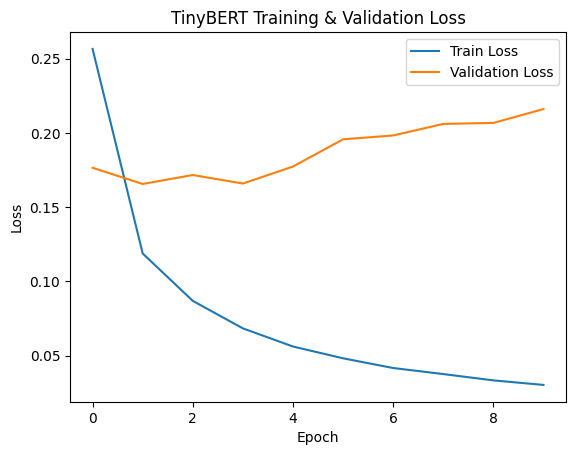

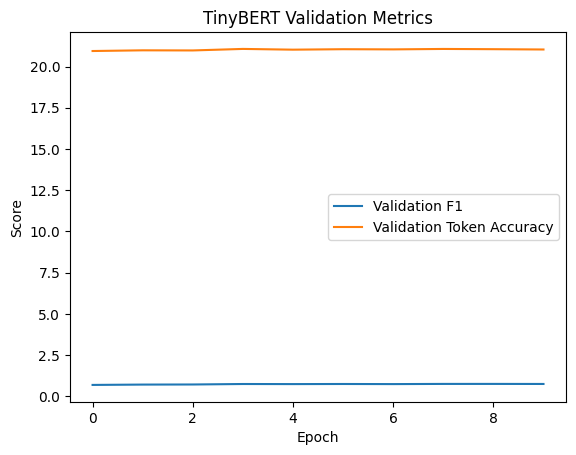

In [189]:
# TODO: Visualize training dynamics using the history dict you populated during training.
#
# Requirements:
#   - hist7 should contain (at least) train_loss and val_loss lists of equal length
#   - Optionally: val_f1 and val_token_acc for score curves

epochs = range(len(hist7["train_loss"]))
plt.figure()
plt.plot(epochs, hist7["train_loss"], label="Train Loss")
plt.plot(epochs, hist7["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("TinyBERT Training & Validation Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, hist7["val_f1"], label="Validation F1")
plt.plot(epochs, hist7["val_token_acc"], label="Validation Token Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("TinyBERT Validation Metrics")
plt.legend()
plt.show()

## Final Test Evaluation

We run the finalized TinyBERT-like model on the **test set** and report the core metrics (loss, token accuracy, and entity-level F1). This is the main quantitative summary of how well our model generalizes to unseen data.

In [190]:
test_metrics7 = evaluate_bert(tiny_bert, test_loader)

print(
    f"TinyBERT-like TEST | "
    f"loss={test_metrics7['loss']:.4f} | "
    f"token_acc={test_metrics7['token_acc']:.4f} | "
    f"P={test_metrics7['precision']:.4f} | "
    f"R={test_metrics7['recall']:.4f} | "
    f"F1={test_metrics7['f1']:.4f}"
)

TinyBERT-like TEST | loss=0.1888 | token_acc=20.9688 | P=0.7429 | R=0.7490 | F1=0.7460


## Concept Checks (answer in Markdown, no code)

1. **Special tokens & supervision**
   - Why do we set labels for `[CLS]` and `[SEP]` to `ignore_index`?
   - What would go wrong if we trained on those positions?
   - **My Answer**: We set the labels for `[CLS]` and `[SEP]` to ignore_index because they are structural tokens added for modeling purposes, not real words in the sentence with semantic NER labels. They do not correspond to entities and therefore should not contribute to the loss or evaluation metrics. If we trained on those positions, the model would be forced to predict artificial labels for them, introducing noisy supervision and skewing both the loss and token-level accuracy.

2. **Truncation effects**
   - We truncate tokens to `max_len - 2`. Why exactly “minus 2”?
   - What is the trade-off between a larger `max_len` and training speed/memory?
   - **My Answer**: We truncate to max_len - 2 because we must reserve two positions for the special tokens [CLS] at the beginning and [SEP] at the end, ensuring the final sequence length does not exceed max_len. The trade-off in choosing a larger max_len is that it allows the model to capture longer-range dependencies and retain more context, which can help entity recognition in long sentences. However, longer sequences increase memory usage and computational cost quadratically in self-attention $(O(T^2))$, slowing training and potentially limiting batch size due to GPU constraints.

3. **Architecture reflection**
   - Compare TinyBERT-like (this part) to the “attention-only with PE” model (Part 4):
     - What is the same?
     - What is different?
     - **My Answer**: TinyBERT-like and the “attention-only with positional encoding” model share the same core Transformer mechanics: token embeddings, positional information, multi-head self-attention, feed-forward networks, residual connections, and layer normalization. The main differences are architectural completeness and input structure: TinyBERT-like explicitly includes segment (token type) embeddings, special tokens ([CLS], [SEP], [MASK]), and a BERT-style input pipeline, making it structurally closer to real BERT. In contrast, the earlier attention-only model was a simplified encoder focused on studying positional encoding and depth, without full BERT-style embedding composition or segment modeling.

## Masked Language Modeling (MLM): Pretraining Objective

In this part we switch from **supervised NER** to a **self-supervised pretraining task**: **Masked Language Modeling (MLM)** (the core objective used in BERT-style models).  
Instead of predicting entity tags, the model sees sentences where some tokens are hidden and must **predict the original tokens** using context from both sides.

By the end of this part, you will:
- Build an MLM dataset and dynamic masking pipeline (the classic **80/10/10** masking rule).
- Train a small BERT-like encoder + MLM head using only masked positions for the loss.
- Evaluate the model using MLM loss (and optionally top-k masked accuracy).
- Visualize attention maps inside the encoder to see what patterns it learns during pretraining.

## Sanity Check
* This cell is a **sanity check**: it ensures all special tokens were added earlier and have valid IDs.
* If any key is missing, it means the notebook skipped the “add special tokens” step.

In [191]:
STOI = stoi
ITOS = itos

CLS_ID  = STOI[BERT_CLS]
SEP_ID  = STOI[BERT_SEP]
MASK_ID = STOI[BERT_MASK]
PAD_ID  = STOI[cfg.pad_token]
UNK_ID  = STOI[cfg.unk_token]

print("Shared vocab size:", len(STOI))
print({t: STOI[t] for t in [cfg.pad_token, cfg.unk_token, BERT_CLS, BERT_SEP, BERT_MASK]})

Shared vocab size: 23875
{'<pad>': 0, '<unk>': 1, '[CLS]': 23872, '[SEP]': 23873, '[MASK]': 23874}


## MLM Dataset (Sentence → BERT-style Input)

In this step, we build a dataset that wraps each sentence as **[CLS] tokens [SEP]** and returns `input_ids` + `token_type_ids`; **masking is NOT done here** (it will be applied later inside the `collate_fn` for dynamic MLM masking).

In [218]:
class MLMSentenceDataset(Dataset):
    """
    Dataset for MLM pretraining:
    returns a single sentence wrapped with [CLS] ... [SEP].
    (Masking + MLM labels will be created later in the collate_fn.)
    """
    def __init__(self, hf_split, stoi: Dict[str, int], max_len: int = 256):
        self.split = hf_split
        self.stoi = stoi
        self.max_len = max_len
        self.unk_id = stoi[cfg.unk_token]

    def __len__(self):
        return len(self.split)

    def __getitem__(self, idx):
        ex = self.split[idx]
        tokens = ex["tokens"]

        # TODO: truncate tokens to (max_len - 2) to leave room for [CLS] and [SEP]
        max_tokens = self.max_len - 2
        tokens = tokens[:max_tokens]

        # TODO: add special tokens: [CLS] + tokens + [SEP]
        bert_tokens = ["[CLS]"] + tokens + ["[SEP]"]

        # TODO: map tokens -> ids using stoi (fallback to UNK for missing tokens)
        input_ids = [self.stoi.get(tok, self.unk_id) for tok in bert_tokens]

        # TODO: token_type_ids for single-sentence input (all zeros, same length as input_ids)
        token_type_ids = [0] * len(input_ids)

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "token_type_ids": torch.tensor(token_type_ids, dtype=torch.long),
            "tokens": bert_tokens,
        }

# TODO: build MLM train/valid datasets
mlm_train_ds = MLMSentenceDataset(ds["train"], STOI, max_len=256)
mlm_valid_ds = MLMSentenceDataset(ds["validation"], STOI, max_len=256)

# TODO: sanity checks (uncomment after implementing __getitem__)
print("MLM train/valid:", len(mlm_train_ds), len(mlm_valid_ds))
print("Example tokens:", mlm_train_ds[0]["tokens"][:15])

MLM train/valid: 59924 8528
Example tokens: ['[CLS]', 'People', 'start', 'their', 'own', 'businesses', 'for', 'many', 'reasons', '.', '[SEP]']


## Dynamic MLM Masking + Collate Function

In this step, we implement **BERT-style dynamic masking (15% with 80/10/10 rule)** inside the `collate_fn`, so each epoch sees *different masked positions* without changing the stored dataset.

In [219]:
def mask_tokens_bert_style(
    input_ids: torch.Tensor,
    attention_mask: torch.Tensor,
    mlm_prob: float = 0.15,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    BERT-style dynamic masking (done on-the-fly).

    input_ids:      [B, T]
    attention_mask: [B, T]  1 for real tokens, 0 for padding

    returns:
      masked_input_ids: [B, T]
      mlm_labels:       [B, T] with original ids at masked positions, cfg.ignore_index elsewhere
    """
    device = input_ids.device
    masked_input_ids = input_ids.clone()
    labels = torch.full_like(input_ids, fill_value=cfg.ignore_index)
    special_ids = {PAD_ID, CLS_ID, SEP_ID, MASK_ID}

    is_not_special = torch.ones_like(input_ids, dtype=torch.bool)
    for sid in special_ids:
        is_not_special &= (input_ids != sid)
    candidate_mask = (attention_mask == 1) & is_not_special

    random_probs = torch.rand(input_ids.shape, device=device)
    mask_positions = (random_probs < mlm_prob) & candidate_mask
    labels[mask_positions] = input_ids[mask_positions]

    replace_probs = torch.rand(input_ids.shape, device=device)
    mask_80 = mask_positions & (replace_probs < 0.8)
    masked_input_ids[mask_80] = MASK_ID
    mask_10_random = mask_positions & (replace_probs >= 0.8) & (replace_probs < 0.9)

    vocab_size = len(STOI)
    all_ids = torch.arange(vocab_size, device=device)
    allowed_ids = all_ids[~torch.isin(all_ids, torch.tensor(list(special_ids), device=device))]
    random_tokens = allowed_ids[torch.randint(len(allowed_ids), size=input_ids.shape, device=device)]
    masked_input_ids[mask_10_random] = random_tokens[mask_10_random]

    return masked_input_ids, labels

In [220]:
def mlm_collate_fn(batch: List[Dict]) -> Dict[str, torch.Tensor]:
    lengths = [len(x["input_ids"]) for x in batch]
    max_len = max(lengths)

    input_ids = torch.full((len(batch), max_len), fill_value=PAD_ID, dtype=torch.long)
    token_type_ids = torch.zeros((len(batch), max_len), dtype=torch.long)
    attention_mask = torch.zeros((len(batch), max_len), dtype=torch.long)

    tokens_list = []
    for i, ex in enumerate(batch):
        L = len(ex["input_ids"])
        input_ids[i, :L] = ex["input_ids"]
        token_type_ids[i, :L] = ex["token_type_ids"]
        attention_mask[i, :L] = 1
        tokens_list.append(ex["tokens"])

    # Position ids: [0..T-1] for each row
    position_ids = torch.arange(max_len, dtype=torch.long).unsqueeze(0).repeat(len(batch), 1)

    # TODO: apply dynamic masking here (NOT in the dataset)
    masked_input_ids, mlm_labels = mask_tokens_bert_style(
        input_ids=input_ids,
        attention_mask=attention_mask,
        mlm_prob=0.15,
    )

    return {
        "input_ids": masked_input_ids,
        "labels": mlm_labels,
        "token_type_ids": token_type_ids,
        "position_ids": position_ids,
        "attention_mask": attention_mask,
        "tokens": tokens_list,
        "lengths": torch.tensor(lengths, dtype=torch.long),
    }


mlm_train_loader = DataLoader(
    mlm_train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=0,
    collate_fn=mlm_collate_fn,
)
mlm_valid_loader = DataLoader(
    mlm_valid_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=0,
    collate_fn=mlm_collate_fn,
)

batch = next(iter(mlm_train_loader))
{k: (v.shape if torch.is_tensor(v) else type(v)) for k, v in batch.items()}

{'input_ids': torch.Size([32, 44]),
 'labels': torch.Size([32, 44]),
 'token_type_ids': torch.Size([32, 44]),
 'position_ids': torch.Size([32, 44]),
 'attention_mask': torch.Size([32, 44]),
 'tokens': list,
 'lengths': torch.Size([32])}

## TinyBERT Encoder + MLM Head (with Weight Tying)

Here we build a small BERT-like encoder and an MLM prediction head, including **weight tying** between the input token embeddings and the output decoder matrix.

In [221]:
class TinyBertEncoder(nn.Module):
    """
    A tiny BERT-style encoder: embeddings + a stack of encoder blocks.
    Returns contextual token representations h in R^{B×T×D}.
    """
    def __init__(
        self,
        vocab_size: int,
        pad_id: int,
        d_model: int = 192,
        num_heads: int = 4,
        num_layers: int = 4,
        dropout: float = 0.1,
        max_len: int = 512,
    ):
        super().__init__()
        self.emb = BertEmbeddings(vocab_size, d_model, pad_id=pad_id, max_len=max_len, dropout=dropout)
        self.blocks = nn.ModuleList([BertStyleEncoderBlock(d_model=d_model, num_heads=num_heads, dropout=dropout, ff_mult=4) for _ in range(num_layers)])

    def forward(self, input_ids, attention_mask=None, token_type_ids=None, position_ids=None):
        x = self.emb(input_ids, token_type_ids=token_type_ids, position_ids=position_ids)
        for blk in self.blocks:
            x = blk(x, attention_mask=attention_mask, return_attn=False)
        return x  # [B, T, D]


class MLMHead(nn.Module):
    """
    BERT-style MLM head:
      - linear -> GELU -> LayerNorm -> vocabulary projection
    Optionally ties decoder weights to the input embedding matrix.
    """
    def __init__(self, d_model: int, vocab_size: int, tie_weights: nn.Embedding = None):
        super().__init__()
        self.dense = nn.Linear(d_model, d_model)
        self.act = nn.GELU()
        self.ln = nn.LayerNorm(d_model)

        # Decoder (no bias; BERT keeps bias as a separate parameter)
        self.decoder = nn.Linear(d_model, vocab_size, bias=False)
        self.bias = nn.Parameter(torch.zeros(vocab_size))

        # TODO (concept): weight tying helps reduce parameters and often improves MLM training
        # If tying is enabled, make decoder weights share storage with token embedding weights.
        if tie_weights is not None:
            self.decoder.weight = tie_weights.weight  # weight tying

    def forward(self, x):
        x = self.dense(x)
        x = self.act(x)
        x = self.ln(x)
        logits = self.decoder(x) + self.bias
        return logits  # [B, T, V]


class TinyBertForMLM(nn.Module):
    """
    Full MLM model: Encoder + MLMHead.
    """
    def __init__(
        self,
        vocab_size: int,
        pad_id: int,
        d_model: int = 192,
        num_heads: int = 4,
        num_layers: int = 4,
        dropout: float = 0.1,
        max_len: int = 512,
    ):
        super().__init__()
        self.encoder = TinyBertEncoder(vocab_size, pad_id, d_model, num_heads, num_layers, dropout, max_len)

        # TODO: tie MLM decoder weights to token embedding matrix (like BERT)
        tied = self.encoder.emb.token_embeddings
        self.mlm_head = MLMHead(d_model=d_model, vocab_size=vocab_size, tie_weights=tied)

    def forward(self, input_ids, attention_mask=None, token_type_ids=None, position_ids=None):
        h = self.encoder(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, position_ids=position_ids)
        logits = self.mlm_head(h)
        return logits  # [B, T, V]

## MLM Loss (masked positions only)

We compute the MLM loss **only over masked tokens** (labels ≠ ignore_index), using summed cross-entropy divided by the number of masked tokens.

In [222]:
def mlm_loss_mean(logits: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
    """
    logits: [B, T, V]
    labels: [B, T] with cfg.ignore_index (e.g. -100) on non-masked positions

    Return: mean loss over MASKED positions only.
    """
    # TODO: unpack shapes
    B, T, V = logits.shape

    # TODO: reshape logits to [B*T, V] and labels to [B*T]
    logits_flat = logits.view(B * T, V)
    labels_flat = labels.view(B * T)

    # TODO: compute summed CE loss ignoring cfg.ignore_index
    loss_sum = F.cross_entropy(logits_flat, labels_flat, ignore_index=cfg.ignore_index, reduction="sum")

    # TODO: count how many labels are NOT ignore_index (masked positions)
    n_masked = (labels_flat != cfg.ignore_index).sum().item()

    # TODO: return mean loss over masked positions
    return loss_sum / max(n_masked, 1)

## MLM Evaluation Loop

Evaluate the MLM model by averaging the **summed masked loss** across a limited number of batches (to keep evaluation fast).

In [223]:
@torch.no_grad()
def evaluate_mlm(model, loader, max_batches: int = None):
    """
    Returns average loss over masked tokens only, optionally over the first `max_batches`.
    """
    model.eval()
    total_loss_sum = 0.0
    total_masked = 0

    for bi, batch in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break

        # TODO: move batch tensors to device
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        position_ids = batch["position_ids"].to(device)

        # TODO: forward pass
        logits = model(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, position_ids=position_ids)

        # TODO: compute summed masked CE loss (reduction="sum", ignore_index=cfg.ignore_index)
        B, T, V = logits.shape
        loss_sum = F.cross_entropy(logits.view(-1, V), labels.view(-1), ignore_index=cfg.ignore_index, reduction="sum")
        n_masked = (labels != cfg.ignore_index).sum().item()

        # TODO: accumulate
        total_loss_sum += loss_sum.item()
        total_masked += n_masked

    # TODO: return average
    return total_loss_sum / max(total_masked, 1)

## MLM Training Loop (dynamic masking)

Train the MLM model with AdamW, log training loss every `log_every` steps, and periodically evaluate on validation batches to track progress.

In [224]:
def train_mlm(
    model,
    train_loader,
    valid_loader,
    epochs: int = 1,
    lr: float = 5e-4,
    weight_decay: float = 0.02,
    max_steps: int = 3000,
    log_every: int = 50,
    eval_batches: int = 50,
):
    # TODO: create AdamW optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.02)
    hist = {"step": [], "train_loss": [], "valid_loss": []}
    global_step = 0

    for ep in range(1, epochs + 1):
        model.train()
        running = 0.0
        seen = 0

        for batch in tqdm(train_loader, desc=f"MLM Train (epoch {ep})", leave=False):
            # TODO: move batch tensors to device
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            token_type_ids = batch["token_type_ids"].to(device)
            position_ids = batch["position_ids"].to(device)

            # TODO: zero grads
            optimizer.zero_grad(set_to_none=True)

            # TODO: forward pass + loss (use mlm_loss_mean)
            logits = model(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, position_ids=position_ids)
            loss = mlm_loss_mean(logits, labels)

            # TODO: backward + clip + step
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            # TODO: update trackers
            running += loss.item()
            seen += 1
            global_step += 1

            # TODO: logging block every log_every steps
            if global_step % log_every == 0:
                train_loss_avg = running / max(seen, 1)
                val_loss = evaluate_mlm(model, valid_loader, max_batches=eval_batches)

                hist["step"].append(global_step)
                hist["train_loss"].append(train_loss_avg)
                hist["valid_loss"].append(val_loss)

                print(f"... valid_ppl≈{math.exp(min(val_loss, 20)):.1f}")

            # TODO: stop when reaching max_steps
            if global_step >= max_steps:
                break

        # TODO: also break outer loop if needed (max_steps)
        if global_step >= max_steps:
            break

    return model, hist

## Train TinyBERT for MLM (dynamic masking)

We initialize the MLM model, measure an initial validation loss, then train for a small number of steps/epochs and re-evaluate to confirm learning progress.

In [225]:
seed_everything(cfg.seed)

# 1) Build the MLM model
mlm_model = TinyBertForMLM(
    vocab_size=len(STOI),
    pad_id=PAD_ID,
    d_model=192,
    num_heads=4,
    num_layers=4,
    dropout=0.1,
    max_len=256,
).to(device)

# 2) Sanity check: initial validation loss (masked tokens only)
print("Initial valid MLM loss:", evaluate_mlm(mlm_model, mlm_valid_loader, max_batches=50))

# 3) Train (students: choose a reasonable training budget)
# TODO: Pick practical values for:
#   - epochs (e.g., 1–3)
#   - max_steps (e.g., 500–5000)
#   - log_every (e.g., 25–100)
# and then run training.

mlm_model, mlm_hist = train_mlm(
    mlm_model,
    mlm_train_loader,
    mlm_valid_loader,
    epochs=2,
    lr=5e-4,
    weight_decay=0.02,
    max_steps=3000,
    log_every=100,
    eval_batches=50,
)

# 4) Final validation loss (after training)
# TODO: Uncomment after training
print("Final valid MLM loss:", evaluate_mlm(mlm_model, mlm_valid_loader, max_batches=50))

Initial valid MLM loss: 10.115511509569846


MLM Train (epoch 1):   0%|          | 0/1873 [00:00<?, ?it/s]

... valid_ppl≈1353.4
... valid_ppl≈1100.9
... valid_ppl≈903.0
... valid_ppl≈908.8
... valid_ppl≈766.8
... valid_ppl≈731.7
... valid_ppl≈710.4
... valid_ppl≈663.6
... valid_ppl≈701.9
... valid_ppl≈686.0
... valid_ppl≈577.9
... valid_ppl≈593.7
... valid_ppl≈576.8
... valid_ppl≈596.1
... valid_ppl≈543.3
... valid_ppl≈555.3
... valid_ppl≈508.4
... valid_ppl≈531.6


MLM Train (epoch 2):   0%|          | 0/1873 [00:00<?, ?it/s]

... valid_ppl≈476.4
... valid_ppl≈511.4
... valid_ppl≈421.3
... valid_ppl≈430.6
... valid_ppl≈362.0
... valid_ppl≈374.0
... valid_ppl≈289.6
... valid_ppl≈331.2
... valid_ppl≈297.8
... valid_ppl≈271.9
... valid_ppl≈263.1
... valid_ppl≈260.1
Final valid MLM loss: 5.612403077439378


## Visualize MLM training

Plot the training loss (running average) and validation loss over steps, and convert validation loss to an approximate perplexity via `exp(loss)` (clipped for numerical safety).

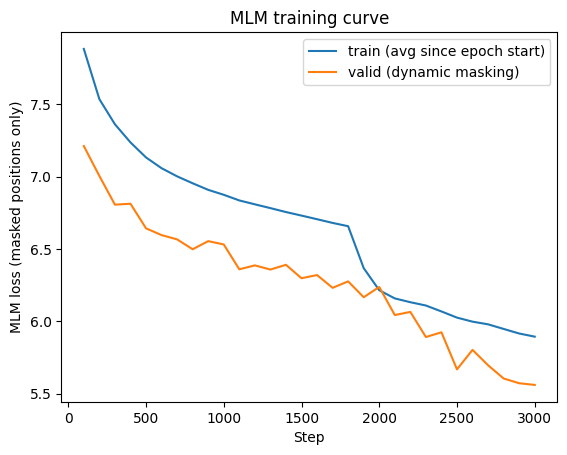

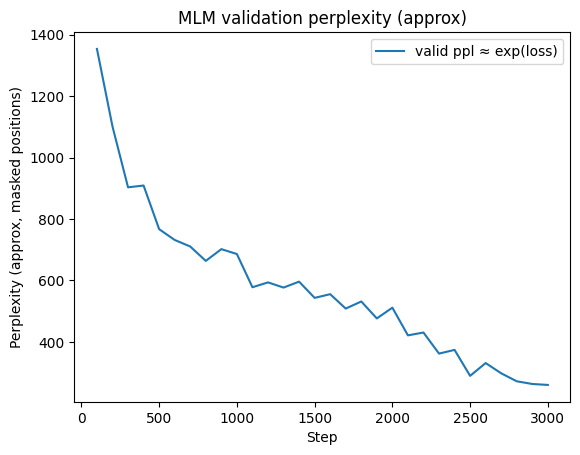

In [226]:
# Plot MLM curves only if you have already run training and produced `mlm_hist`.
# TODO: Run the training cell above to create `mlm_hist`, then re-run this cell.

df_mlm = pd.DataFrame(mlm_hist)

plt.figure()
plt.plot(df_mlm["step"], df_mlm["train_loss"], label="train (avg since epoch start)")
plt.plot(df_mlm["step"], df_mlm["valid_loss"], label="valid (dynamic masking)")
plt.xlabel("Step")
plt.ylabel("MLM loss (masked positions only)")
plt.title("MLM training curve")
plt.legend()
plt.show()

plt.figure()
plt.plot(
    df_mlm["step"],
    [math.exp(min(x, 20)) for x in df_mlm["valid_loss"]],
    label="valid ppl ≈ exp(loss)"
)
plt.xlabel("Step")
plt.ylabel("Perplexity (approx, masked positions)")
plt.title("MLM validation perplexity (approx)")
plt.legend()
plt.show()

## TODO: Evaluate MLM Top-k Accuracy (masked positions only)

Compute masked-token Top-1 and Top-5 accuracy on the validation set to quantify how often the true token appears in the model’s top predictions.

In [227]:
# TODO: Implement masked-token Top-k accuracy for MLM.
# Requirements:
# - Only evaluate positions where `labels != cfg.ignore_index` (i.e., masked prediction targets)
# - Use `torch.no_grad()` and `model.eval()`
# - Support `k` and `max_batches` to keep validation quick

@torch.no_grad()
def mlm_topk_acc(model, loader, k: int = 1, max_batches: int = 50):
    model.to(device)
    correct = 0
    total = 0

    for bi, batch in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break

        # TODO: move tensors to device
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        position_ids = batch["position_ids"].to(device)

        # TODO: forward pass (logits shape should be [B, T, V])
        logits = model(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, position_ids=position_ids)

        # TODO: build mask for masked positions only
        mask = (labels != cfg.ignore_index)

        # If there are no masked targets in this batch, skip it
        if not mask.any():
            continue

        # TODO: compute top-k predicted token IDs at each position
        masked_logits = logits[mask]
        masked_labels = labels[mask]
        _, topk_indices = masked_logits.topk(k, dim=-1)

        # TODO: compare topk predictions to true labels at masked positions
        correct_in_topk = (topk_indices == masked_labels.unsqueeze(-1)).any(dim=-1)

        # TODO: accumulate correct / total (masked positions only)
        correct += correct_in_topk.sum().item()
        total += masked_labels.size(0)

    return correct / max(total, 1)

# TODO: compute and print Top-1 and Top-5 accuracy
top1 = mlm_topk_acc(mlm_model, mlm_valid_loader, k=1, max_batches=50)
top5 = mlm_topk_acc(mlm_model, mlm_valid_loader, k=5, max_batches=50)
print(f"Valid MLM masked top-1 acc: {top1:.4f}")
print(f"Valid MLM masked top-5 acc: {top5:.4f}")

Valid MLM masked top-1 acc: 0.2260
Valid MLM masked top-5 acc: 0.3557


## TODO: Visualize MLM Encoder Attention (single layer/head)

Extract and plot one attention head from a chosen encoder layer to inspect what tokens the model attends to during MLM pretraining.


Visualizing: Layer 0 | Head 0
Tokens: ['[CLS]', 'A', 'Russian', '<unk>', 'has', '[MASK]', '[MASK]', '[MASK]', 'of', 'three', 'of', 'the', '118', 'sailors', 'who', 'were', 'killed', '[MASK]', 'the', 'nuclear', 'submarine', 'Kursk', '<unk>', '[MASK]', 'the', 'Barents', 'Sea', '.', '[SEP]']




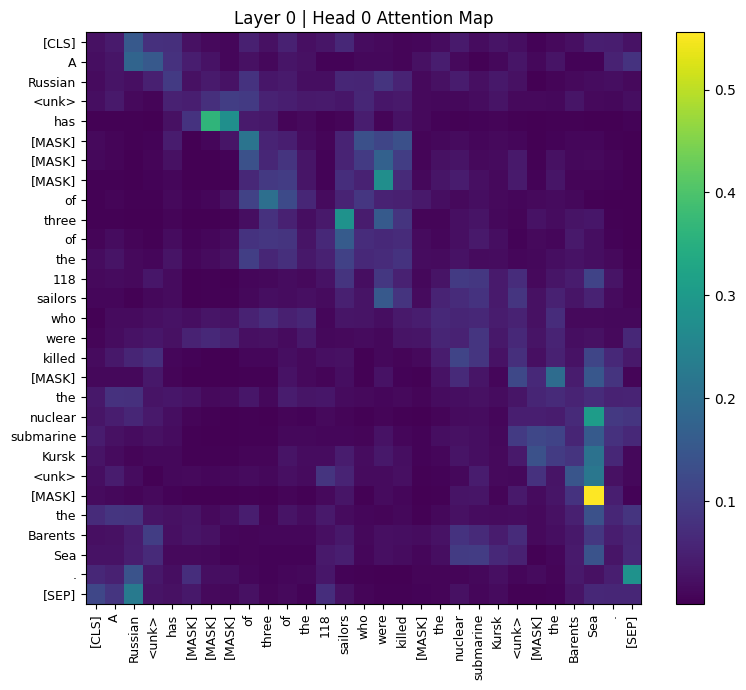

Visualizing: Layer 0 | Head 1
Tokens: ['[CLS]', 'A', 'Russian', '[MASK]', 'has', 'found', 'the', 'bodies', 'of', 'three', 'of', 'the', '118', 'sailors', 'who', 'were', 'killed', 'when', 'the', 'nuclear', 'submarine', 'Kursk', '<unk>', 'in', 'the', 'Barents', 'Sea', '.', '[SEP]']




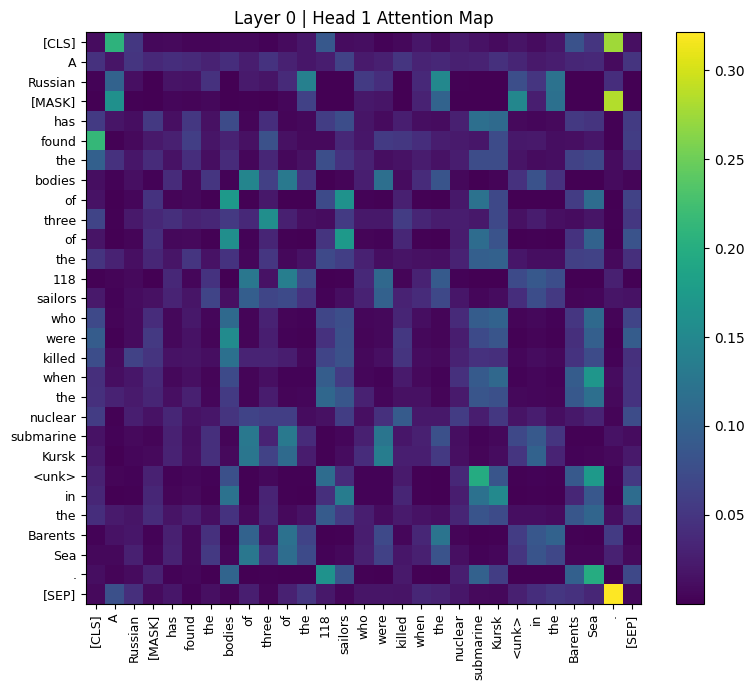

In [272]:
@torch.no_grad()
def encoder_attention_map(model, loader, layer_to_show: int = 0, head_to_show: int = 0, ex_idx: int = 0, max_tokens: int = 40):
    """
    TODO:
    1) Switch model to evaluation mode.
    2) Read one batch from `loader`.
    3) Move required batch tensors to the correct device.
    4) Choose one example (index = ex_idx) and compute its real length (exclude padding).
    5) Decode the visible tokens for axis labels (cap to max_tokens).
    6) Run the encoder forward, requesting attention only for `layer_to_show`.
    7) Extract the attention matrix for `head_to_show` and crop it to [L, L].
    8) Plot the matrix as a heatmap with token labels on both axes.
    """
    model.eval()
    batch = next(iter(loader))
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    token_type_ids = batch["token_type_ids"].to(device)

    position_ids = batch.get("position_ids", None)
    if position_ids is not None:
        position_ids = position_ids.to(device)

    itos = {i: s for s, i in STOI.items()}
    ex_ids = input_ids[ex_idx]

    if (ex_ids == PAD_ID).any():
        L = (ex_ids == PAD_ID).nonzero(as_tuple=True)[0][0].item()
    else:
        L = len(ex_ids)
    L = min(L, max_tokens)

    tokens = [itos.get(ex_ids[i].item()) for i in range(L)]
    x = model.encoder.emb(input_ids, token_type_ids=token_type_ids, position_ids=position_ids)
    
    attn_matrix = None
    for i, blk in enumerate(model.encoder.blocks):
        if i == layer_to_show:
            x, attn = blk(x, attention_mask=attention_mask, return_attn=True)
            attn_matrix = attn[ex_idx, head_to_show, :L, :L].cpu()
        else:
            x = blk(x, attention_mask=attention_mask, return_attn=False)
            
    if attn_matrix is None:
        print(f"Error: Layer {layer_to_show} is out of bounds.")
        return

    print(f"Visualizing: Layer {layer_to_show} | Head {head_to_show}")
    print("Tokens:", tokens)
    print("\n")

    plt.figure(figsize=(8, 7))
    plt.imshow(attn_matrix, aspect="auto", cmap="viridis")
    plt.colorbar()

    plt.xticks(range(L), tokens, rotation=90, fontsize=9)
    plt.yticks(range(L), tokens, fontsize=9)

    plt.title(f"Layer {layer_to_show} | Head {head_to_show} Attention Map")
    plt.tight_layout()
    plt.show()

encoder_attention_map(mlm_model, mlm_valid_loader, layer_to_show=0, head_to_show=0, ex_idx=0)
encoder_attention_map(mlm_model, mlm_valid_loader, layer_to_show=0, head_to_show=1, ex_idx=0)

## Concept Checks (answer in Markdown, no code)

1) **What is MLM actually optimizing?**  
Explain in words what the model is asked to predict, and why this is a self-supervised objective.
**My Answer**: Masked Language Modeling (MLM) is optimizing the model's ability to recover missing information based on context. The model is given a sentence where some percentage of the words (tokens) have been hidden or replaced with a special `[MASK]` token. For these specific "blank" positions, the model must output a probability distribution over the entire vocabulary to guess the original word. It is called "self-supervised" because it does not require human annotators to create labels. The "labels" are simply the original words that were present in the text before we masked them.

2) **Dynamic masking vs. static masking:**  
What is dynamic masking, and why can it help training compared to precomputing a fixed masked dataset? The masking decision is made on the fly every time a batch is created. It acts as a powerful form of data augmentation. Across different epochs, the model will see the same sentence with different words masked out. This prevents the model from memorizing specific "fill-in-the-blank" questions and forces it to learn more robust contextual relationships, as it eventually has to predict almost every word in the dataset given different surrounding contexts.


## Part 9 — Pretraining Objective #2: Next Sentence Prediction (NSP)

So far we trained a **masked language model (MLM)** that learns to recover missing tokens from context.  
In this part we add a second classic pretraining signal from the original BERT recipe: **Next Sentence Prediction (NSP)**.

### What we build
We will construct **sentence pairs**:
- **Sentence A** = a real sentence from the dataset
- **Sentence B** = either the *true next* sentence (**IsNext = 1**) or a *random* sentence from elsewhere (**NotNext = 0**)

Then we train a single encoder to solve **two tasks at once**:
1. **MLM**: predict masked tokens (token-level classification over the vocabulary)
2. **NSP**: predict whether B follows A (binary classification from the `[CLS]` representation)

### Why this matters
- MLM encourages **local, token-level semantic understanding**.
- NSP encourages the model to capture **sentence-to-sentence coherence** and discourse-level signals.
- Multi-task training forces the encoder to learn representations useful at different granularity levels.

## Build NSP sentence pairs
We create positive (next-sentence) and negative (random-sentence) pairs for the NSP objective.

In [238]:
class NSPPairDataset(Dataset):
    def __init__(self, hf_split, stoi: Dict[str, int], max_len: int = 256, p_is_next: float = 0.5):
        self.split = hf_split
        self.stoi = stoi
        self.max_len = max_len
        self.p_is_next = p_is_next
        self.n = len(hf_split)

    def _truncate_pair(self, a_tokens, b_tokens):
        # total length must fit: [CLS] A [SEP] B [SEP]
        max_pair = self.max_len - 3
        a = list(a_tokens)
        b = list(b_tokens)

        while len(a) + len(b) > max_pair:
            if len(a) > len(b):
                a.pop()
            else:
                b.pop()
        return a, b

    def __len__(self):
        return self.n - 1  # need idx+1 to exist for a true "next" example

    def __getitem__(self, idx):
        tokens_a = self.split[idx]["tokens"]
        if random.random() < self.p_is_next:
            is_next = 1
            tokens_b = self.split[idx + 1]["tokens"]
        else:
            is_next = 0
            j = random.randint(0, self.n - 1)
            while j == idx or j == idx + 1:
                j = random.randint(0, self.n - 1)
            tokens_b = self.split[j]["tokens"]

        tokens_a, tokens_b = self._truncate_pair(tokens_a, tokens_b)

        return {
            "tokens_a": tokens_a,
            "tokens_b": tokens_b,
            "is_next": torch.tensor(is_next, dtype=torch.long)
        }


nsp_train_ds = NSPPairDataset(ds["train"], STOI, max_len=256, p_is_next=0.5)
nsp_valid_ds = NSPPairDataset(ds["validation"], STOI, max_len=256, p_is_next=0.5)

print("NSP train/valid:", len(nsp_train_ds), len(nsp_valid_ds))
ex0 = nsp_train_ds[0]
print("Example A:", ex0["tokens_a"][:10])
print("Example B:", ex0["tokens_b"][:10])
print("Label is_next:", int(ex0["is_next"].item()))

NSP train/valid: 59923 8527
Example A: ['People', 'start', 'their', 'own', 'businesses', 'for', 'many', 'reasons', '.']
Example B: ['However', 'we', "'re", 'the', 'first', 'to', 'admit', 'we', "'re", 'not']
Label is_next: 0


## Collate NSP pairs for MLM + NSP
Pack sentence pairs into one BERT-style sequence and prepare tensors needed for joint pretraining.

In [273]:
def nsp_mlm_collate_fn(batch: List[Dict]) -> Dict[str, torch.Tensor]:
    input_ids_list = []
    token_type_list = []
    is_next_list = []
    tokens_debug = []
    lengths = [] 

    for ex in batch:
        a = ex["tokens_a"]
        b = ex["tokens_b"]
        
        is_next_list.append(ex["is_next"])

        full_tokens = ["[CLS]"] + a + ["[SEP]"] + b + ["[SEP]"]
        tokens_debug.append(full_tokens)
        
        unk_id = STOI[cfg.unk_token]
        ids = [STOI.get(t, unk_id) for t in full_tokens]
        
        input_ids_list.append(torch.tensor(ids, dtype=torch.long))
        
        len_a_part = len(a) + 2  # [CLS] ... [SEP]
        len_b_part = len(b) + 1  # ... [SEP]
        types = [0] * len_a_part + [1] * len_b_part
        
        token_type_list.append(torch.tensor(types, dtype=torch.long))
        lengths.append(len(ids))

    input_ids_padded = torch.nn.utils.rnn.pad_sequence(input_ids_list, batch_first=True, padding_value=PAD_ID)
    token_type_ids_padded = torch.nn.utils.rnn.pad_sequence(token_type_list, batch_first=True, padding_value=0)
    attention_mask = (input_ids_padded != PAD_ID).long()

    B, T = input_ids_padded.shape
    position_ids = torch.arange(T, device=input_ids_padded.device).unsqueeze(0).expand(B, T)
    
    masked_input_ids, mlm_labels = mask_tokens_bert_style(
        input_ids=input_ids_padded, 
        attention_mask=attention_mask,
        mlm_prob=0.15
    )
    
    return {
        "input_ids": masked_input_ids,
        "mlm_labels": mlm_labels,
        "nsp_labels": torch.tensor(is_next_list, dtype=torch.long), # tensor() is safer than stack() for ints
        "token_type_ids": token_type_ids_padded,
        "position_ids": position_ids,
        "attention_mask": attention_mask,
        "tokens": tokens_debug,
        "lengths": torch.tensor(lengths)
    }

batch_size = 32
raw_batch = [nsp_train_ds[i] for i in range(batch_size)]
collated_batch = nsp_mlm_collate_fn(raw_batch)
{k: v.shape if isinstance(v, torch.Tensor) else type(v) for k, v in collated_batch.items()}

{'input_ids': torch.Size([32, 84]),
 'mlm_labels': torch.Size([32, 84]),
 'nsp_labels': torch.Size([32]),
 'token_type_ids': torch.Size([32, 84]),
 'position_ids': torch.Size([32, 84]),
 'attention_mask': torch.Size([32, 84]),
 'tokens': list,
 'lengths': torch.Size([32])}

In [279]:
nsp_train_loader = DataLoader(
    nsp_train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=0,
    collate_fn=nsp_mlm_collate_fn,
)
nsp_valid_loader = DataLoader(
    nsp_valid_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=0,
    collate_fn=nsp_mlm_collate_fn,
)

## Add an NSP head for joint MLM + NSP pretraining
Extend the MLM encoder with a small classifier on the `[CLS]` representation to predict whether sentence B follows sentence A.

In [280]:
# Note: You can modify this part if you need

class NSPHead(nn.Module):
    def __init__(self, d_model: int):
        super().__init__()
        self.dense = nn.Linear(d_model, d_model)
        self.act = nn.Tanh()
        self.classifier = nn.Linear(d_model, 2)  # 0 = NotNext, 1 = IsNext
        nn.init.xavier_uniform_(self.classifier.weight)
        nn.init.zeros_(self.classifier.bias)

    def forward(self, cls_hidden: torch.Tensor):
        x = self.act(self.dense(cls_hidden))
        return self.classifier(x)

class TinyBertForPretraining(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        pad_id: int,
        d_model: int = 192,
        num_heads: int = 4,
        num_layers: int = 4,
        dropout: float = 0.1,
        max_len: int = 512,
    ):
        super().__init__()
        self.encoder = TinyBertEncoder(vocab_size, pad_id, d_model, num_heads, num_layers, dropout, max_len)
        tied = self.encoder.emb.token_embeddings
        self.mlm_head = MLMHead(d_model=d_model, vocab_size=vocab_size, tie_weights=tied)
        self.nsp_head = NSPHead(d_model=d_model)

    def forward(self, input_ids, attention_mask=None, token_type_ids=None, position_ids=None):
        h = self.encoder(
            input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            position_ids=position_ids,
        )
        mlm_logits = self.mlm_head(h)
        cls_hidden = h[:, 0, :]
        nsp_logits = self.nsp_head(cls_hidden)
        return mlm_logits, nsp_logits

## Initialize the joint pretraining model (optional warm start)
Create the MLM+NSP model and (optionally) reuse the encoder/MLM weights learned in Part 8.

In [281]:
seed_everything(cfg.seed)

pretrain_model = TinyBertForPretraining(
    vocab_size=len(STOI),
    pad_id=PAD_ID,
    d_model=192,
    num_heads=4,
    num_layers=4,
    dropout=0.1,
    max_len=256,
).to(device)

if "mlm_model" in globals():
    print("Loading weights from Part 8 MLM model...")
    pretrain_model.encoder.load_state_dict(mlm_model.encoder.state_dict())
    pretrain_model.mlm_head.load_state_dict(mlm_model.mlm_head.state_dict(), strict=False)

print("Ready.")

Loading weights from Part 8 MLM model...
Ready.


## Joint Pretraining: Evaluation + Training Loop (MLM + NSP)
Implement the evaluation and training routines for the combined MLM+NSP objective, then track validation metrics during training.

In [282]:
@torch.no_grad()
def eval_pretrain(model, loader, max_batches: int = 100):
    """
    Evaluate a joint-pretraining model (MLM + NSP) on up to `max_batches`.

    Return a dict with:
      - "mlm_loss": average MLM loss over masked positions only
      - "nsp_loss": average NSP loss over examples
      - "nsp_acc" : NSP accuracy over examples
    """
    model.eval()
    mlm_loss_sum = 0.0
    mlm_total_masked = 0
    nsp_loss_sum = 0.0
    nsp_correct = 0
    nsp_total = 0

    for bi, batch in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break

        input_ids = batch["input_ids"].to(device)
        mlm_labels = batch["mlm_labels"].to(device)
        nsp_labels = batch["nsp_labels"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        position_ids = batch["position_ids"].to(device)

        mlm_logits, nsp_logits = model(input_ids,  attention_mask=attention_mask,  token_type_ids=token_type_ids,  position_ids=position_ids)
        B, T, V = mlm_logits.shape

        mlm_loss = F.cross_entropy(mlm_logits.reshape(-1, V),  mlm_labels.reshape(-1), ignore_index=cfg.ignore_index, reduction="sum")
        n_masked = (mlm_labels != cfg.ignore_index).sum().item()
        mlm_loss_sum += mlm_loss.item()
        mlm_total_masked += n_masked

        nsp_loss = F.cross_entropy(nsp_logits, nsp_labels, reduction="sum")
        nsp_preds = nsp_logits.argmax(dim=-1)
        n_correct = (nsp_preds == nsp_labels).sum().item()
        nsp_loss_sum += nsp_loss.item()

        nsp_correct += n_correct
        nsp_total += nsp_labels.size(0)

    return {
        "mlm_loss": mlm_loss_sum / max(mlm_total_masked, 1),
        "nsp_loss": nsp_loss_sum / max(nsp_total, 1),
        "nsp_acc": nsp_correct / max(nsp_total, 1)
    }

In [283]:
def train_pretrain(
    model, train_loader, valid_loader,
    lr: float = 5e-4, weight_decay: float = 0.02,
    max_steps: int = 300, log_every: int = 50,
    grad_clip: float = 1.0, valid_batches: int = 100
):
    """
    Train joint-pretraining model with loss = MLM_loss + NSP_loss.

    Track:
      - training running averages (mlm, nsp)
      - validation metrics via eval_pretrain()
      - optional: validation MLM perplexity ~ exp(mlm_loss)
    """
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {
        "step": [],
        "train_mlm": [],
        "train_nsp": [],
        "valid_mlm": [],
        "valid_nsp": [],
        "valid_nsp_acc": [],
        "valid_mlm_ppl": [],
    }

    model.train()

    global_step = 0
    running_mlm = 0.0
    running_nsp = 0.0
    running_count = 0

    train_iter = iter(train_loader)
    pbar = tqdm(total=max_steps, desc="Joint Pretraining")
    while global_step < max_steps:
        try:
            batch = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            batch = next(train_iter)

        input_ids = batch["input_ids"].to(device)
        mlm_labels = batch["mlm_labels"].to(device)
        nsp_labels = batch["nsp_labels"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        position_ids = batch["position_ids"].to(device)

        opt.zero_grad()
        mlm_logits, nsp_logits = model(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, position_ids=position_ids)
        mlm_loss = mlm_loss_mean(mlm_logits, mlm_labels)
        nsp_loss = F.cross_entropy(nsp_logits, nsp_labels)
        loss = mlm_loss + nsp_loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        opt.step()

        running_mlm += mlm_loss.item()
        running_nsp += nsp_loss.item()
        running_count += 1
        global_step += 1
        pbar.update(1)

        if global_step % log_every == 0:
            avg_mlm = running_mlm / running_count
            avg_nsp = running_nsp / running_count

            val_metrics = eval_pretrain(model, valid_loader, max_batches=valid_batches)
            val_mlm = val_metrics["mlm_loss"]
            val_nsp = val_metrics["nsp_loss"]
            val_acc = val_metrics["nsp_acc"]
            val_ppl = math.exp(val_mlm) if val_mlm < 20 else 1e9

            history["step"].append(global_step)
            history["train_mlm"].append(avg_mlm)
            history["train_nsp"].append(avg_nsp)
            history["valid_mlm"].append(val_mlm)
            history["valid_nsp"].append(val_nsp)
            history["valid_nsp_acc"].append(val_acc)
            history["valid_mlm_ppl"].append(val_ppl)

            print(f"step={global_step:04d} | "
                  f"Tr MLM={avg_mlm:.4f} NSP={avg_nsp:.4f} | "
                  f"Val MLM={val_mlm:.4f} (PPL~{val_ppl:.1f}) NSP Acc={val_acc:.4f}")

            running_mlm = 0.0
            running_nsp = 0.0
            running_count = 0
            model.train()

    pbar.close()
    return model, history

In [284]:
# Evaluate before training
print("Initial valid metrics:", eval_pretrain(pretrain_model, nsp_valid_loader, max_batches=100))

# Train for ~1 epoch worth of steps (or as configured)
pretrain_model, hist9 = train_pretrain(
    pretrain_model,
    nsp_train_loader,
    nsp_valid_loader,
    max_steps=len(nsp_train_loader) + 1,
    log_every=50,
)

# Evaluate after training
print("Final valid metrics:", eval_pretrain(pretrain_model, nsp_valid_loader, max_batches=100))

Initial valid metrics: {'mlm_loss': 5.942752934930252, 'nsp_loss': 0.728234429359436, 'nsp_acc': 0.4734375}


Joint Pretraining:   0%|          | 0/1874 [00:00<?, ?it/s]

step=0050 | Tr MLM=5.8386 NSP=0.7431 | Val MLM=5.7669 (PPL~319.6) NSP Acc=0.5722
step=0100 | Tr MLM=5.8798 NSP=0.7010 | Val MLM=5.6999 (PPL~298.8) NSP Acc=0.5250
step=0150 | Tr MLM=5.7743 NSP=0.6690 | Val MLM=5.6891 (PPL~295.6) NSP Acc=0.5644
step=0200 | Tr MLM=5.7712 NSP=0.6762 | Val MLM=5.6655 (PPL~288.7) NSP Acc=0.4838
step=0250 | Tr MLM=5.7782 NSP=0.6839 | Val MLM=5.5911 (PPL~268.0) NSP Acc=0.5950
step=0300 | Tr MLM=5.7028 NSP=0.6434 | Val MLM=5.5739 (PPL~263.5) NSP Acc=0.6144
step=0350 | Tr MLM=5.6895 NSP=0.6334 | Val MLM=5.5660 (PPL~261.4) NSP Acc=0.6062
step=0400 | Tr MLM=5.6860 NSP=0.6298 | Val MLM=5.5794 (PPL~264.9) NSP Acc=0.6253
step=0450 | Tr MLM=5.6434 NSP=0.6214 | Val MLM=5.4825 (PPL~240.5) NSP Acc=0.6534
step=0500 | Tr MLM=5.5535 NSP=0.6192 | Val MLM=5.4947 (PPL~243.4) NSP Acc=0.5147
step=0550 | Tr MLM=5.5747 NSP=0.6239 | Val MLM=5.4626 (PPL~235.7) NSP Acc=0.6144
step=0600 | Tr MLM=5.5727 NSP=0.6045 | Val MLM=5.4168 (PPL~225.2) NSP Acc=0.6419
step=0650 | Tr MLM=5.5459 NS

## Visualize MLM + NSP Pretraining Curves
Plot the logged training/validation MLM loss, NSP loss/accuracy, and MLM perplexity as a function of update steps.

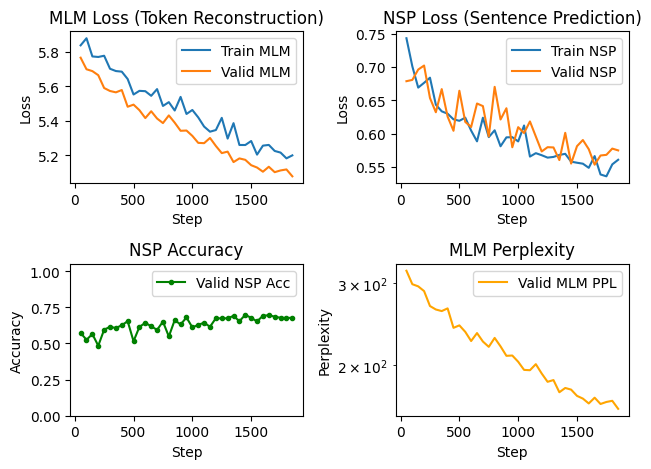

In [285]:
plt.figure()

plt.subplot(2, 2, 1)
plt.plot(hist9["step"], hist9["train_mlm"], label="Train MLM")
plt.plot(hist9["step"], hist9["valid_mlm"], label="Valid MLM")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("MLM Loss (Token Reconstruction)")
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(hist9["step"], hist9["train_nsp"], label="Train NSP")
plt.plot(hist9["step"], hist9["valid_nsp"], label="Valid NSP")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("NSP Loss (Sentence Prediction)")
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(hist9["step"], hist9["valid_nsp_acc"], color="green", marker=".", label="Valid NSP Acc")
plt.xlabel("Step")
plt.ylabel("Accuracy")
plt.title("NSP Accuracy")
plt.ylim(0, 1.05)
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(hist9["step"], hist9["valid_mlm_ppl"], color="orange", label="Valid MLM PPL")
plt.xlabel("Step")
plt.ylabel("Perplexity")
plt.title("MLM Perplexity")
plt.yscale("log")
plt.legend()

plt.tight_layout()
plt.show()

## Inspect One NSP Pair (Qualitative Check)
Take one batch from the NSP validation loader, split it into sentence A/B using `[SEP]`, and print the NSP label + tokens.

In [286]:
batch = next(iter(nsp_valid_loader))

idx = 0
ids = batch["input_ids"][idx]
nsp_label = batch["nsp_labels"][idx].item()
attn_mask = batch["attention_mask"][idx]

L = attn_mask.sum().item()
ids = ids[:L]
itos = {i: s for s, i in STOI.items()}
tokens = [itos.get(i.item(), "[UNK]") for i in ids]

sep_indices = [i for i, t in enumerate(tokens) if t == "[SEP]"]

if len(sep_indices) >= 2:
    sent_a = tokens[1 : sep_indices[0]]
    sent_b = tokens[sep_indices[0] + 1 : sep_indices[1]]
else:
    sent_a = tokens
    sent_b = []

label_str = "IsNext (1)" if nsp_label == 1 else "NotNext (0)"

print(f"NSP Label: {nsp_label} ({label_str})")
print(f"Sentence A: {' '.join(sent_a)}")
print(f"Sentence B: {' '.join(sent_b)}")

NSP Label: 0 (NotNext (0))
Sentence A: A Russian <unk> has found the bodies of three of the 118 sailors [MASK] were killed when the adhered submarine Kursk <unk> in the Barents Sea .
Sentence B: [MASK] do n't wear a <unk> .


## Concept Checks (answer in Markdown, no code)

1. **Data construction:**  
   In our NSP dataset, how are positive pairs (IsNext) and negative pairs (NotNext) created?  
   What role does `p_is_next` play?

   **My Answer**: Positive pairs (IsNext) are created by taking two actual consecutive sentences (or segments) from the original text corpus. If Sentence A is at index $i$, Sentence B is the sentence at index $i+1$. Negative pairs (NotNext) are created by pairing Sentence A with a random sentence from the corpus (a "distractor"). This random sentence typically comes from a different document or a far-away position, having no logical connection to A. `p_is_next` probability parameter controls the balance of the dataset. It is typically set to 0.5, ensuring that 50% of the examples are positive (true next sentences) and 50% are negative (random pairs). This balanced distribution prevents the model from trivially guessing one class.

2. **Loss design:**  
   We train with a combined loss:

   $$
   \mathcal{L} = \mathcal{L}_{\mathrm{MLM}} + \mathcal{L}_{\mathrm{NSP}}.
   $$

   What does each term supervise, and which model outputs are used to compute them?

   **My Answer**: $L_{MLM}$ (Masked Language Modeling Loss) teaches the model local context and token-level semantics. The model learns to use surrounding words to fill in the blanks. It is computed using the final hidden vectors of the masked tokens. These vectors are projected to the vocabulary size to predict the original word identities.$L_{NSP}$ (Next Sentence Prediction Loss) teaches the model global context and sentence-level relationships. The model learns to determine if two segments logically follow one another (coherence). It is computed using the final hidden vector of the [CLS] token. This single vector is treated as a summary representation of the entire input pair and is passed to a binary classifier.

# Part 10 — Fine-tuning Results

In Parts 8–9 we trained the same tiny BERT-style encoder with self-supervised objectives (MLM, then MLM+NSP).  
In this part we **fine-tune for NER** and compare three initializations:

- **Scratch:** encoder starts from random weights.
- **MLM-init:** encoder starts from the Part 8 MLM-pretrained weights.
- **MLM+NSP-init:** encoder starts from the Part 9 MLM+NSP-pretrained weights.

We will evaluate each run with the same NER metrics (loss, token accuracy, and entity-level precision/recall/F1) and then do a small qualitative check by printing token-level predictions for one validation example.

## Select a Compatible Vocabulary for Fine-Tuning  
We must ensure the fine-tuning vocabulary size matches the encoder’s token embedding table to avoid shape-mismatch errors.


In [287]:
def pick_vocab_for_encoder():
    """
    Returns (FT_STOI, FT_ITOS) such that len(FT_STOI) matches the encoder vocab size.
    Priority:
      1) If pretrain_model exists -> match its encoder embedding size
      2) elif mlm_model exists -> match its encoder embedding size
      3) else fallback to (stoi, itos)
    """
    # candidates we might have
    candidates = []
    if "mlm_stoi" in globals() and "mlm_itos" in globals():
        candidates.append(("mlm", mlm_stoi, mlm_itos))
    if "stoi" in globals() and "itos" in globals():
        candidates.append(("ner", stoi, itos))

    # determine target vocab size
    target = None
    if "pretrain_model" in globals():
        target = pretrain_model.encoder.emb.token_embeddings.num_embeddings
        src = "pretrain_model"
    elif "mlm_model" in globals():
        target = mlm_model.encoder.emb.token_embeddings.num_embeddings
        src = "mlm_model"
    else:
        target = None
        src = "none"

    if target is None:
        print("No pretrained encoder found; using (stoi, itos).")
        return stoi, itos

    for name, S, I in candidates:
        if len(S) == target:
            print(f"Using vocab '{name}' because it matches encoder vocab_size={target} (source={src}).")
            return S, I

    # If none match, fail loudly with a helpful message
    raise ValueError(
        f"No available vocab matches encoder vocab size={target}. "
        f"Available sizes: {[ (name, len(S)) for name,S,_ in candidates ]}. "
        f"Fix by using the same vocab in Parts 8–10."
    )

FT_STOI, FT_ITOS = pick_vocab_for_encoder()

FT_PAD_ID  = FT_STOI[cfg.pad_token]
FT_UNK_ID  = FT_STOI[cfg.unk_token]
FT_CLS_ID  = FT_STOI[BERT_CLS]
FT_SEP_ID  = FT_STOI[BERT_SEP]

Using vocab 'ner' because it matches encoder vocab_size=23875 (source=pretrain_model).


## NER Dataset with BERT-Style Special Tokens  
Wrap each sentence as `[CLS] tokens [SEP]` and align labels by ignoring the special-token positions.

In [288]:
class NERBertInputDataset(Dataset):
    def __init__(self, hf_split, stoi: Dict[str,int], max_len: int = 256):
        self.split = hf_split
        self.stoi = stoi
        self.max_len = max_len

    def __len__(self):
        return len(self.split)

    def __getitem__(self, idx):
        ex = self.split[idx]
        tokens = ex["tokens"]
        labels = ex["ner_tags"]

        # Fit: [CLS] + tokens + [SEP]
        max_tokens = self.max_len - 2
        tokens = tokens[:max_tokens]
        labels = labels[:max_tokens]

        bert_tokens = [BERT_CLS] + tokens + [BERT_SEP]
        input_ids = [self.stoi.get(t, self.stoi[cfg.unk_token]) for t in bert_tokens]

        # Labels: ignore CLS and SEP positions
        bert_labels = [cfg.ignore_index] + labels + [cfg.ignore_index]

        token_type_ids = [0] * len(input_ids)  # single segment

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "token_type_ids": torch.tensor(token_type_ids, dtype=torch.long),
            "labels": torch.tensor(bert_labels, dtype=torch.long),
            "tokens": bert_tokens,
        }

## Collate Function + Fine-tuning DataLoaders  
Implement padding + attention masks (and position ids) to build BERT-style batches for NER fine-tuning.

In [300]:
# TODO: Implement a BERT-style collate function for token classification.
# Requirements:
# 1) Pad input_ids with FT_PAD_ID to [B, T_max]
# 2) Build token_type_ids (already provided per example) and pad to [B, T_max]
# 3) Build attention_mask with 1 for real tokens, 0 for padding
# 4) Pad labels with cfg.ignore_index to [B, T_max]
# 5) Build position_ids as [0..T_max-1] repeated for each batch row
# 6) Return a dict with:
#    "input_ids", "token_type_ids", "position_ids", "attention_mask", "labels",
#    "tokens" (list of token strings per example), "lengths" (original lengths)

def bert_ner_collate_fn(batch: List[Dict]) -> Dict[str, torch.Tensor]:
    # lengths: list[int] of each example sequence length
    # max_len: int, the maximum length in this batch
    # Create padded tensors and fill them in a loop.
    lengths = [len(x["input_ids"]) for x in batch]
    max_len = max(lengths)
    batch_size = len(batch)
    input_ids = torch.full((batch_size, max_len), FT_PAD_ID, dtype=torch.long)
    token_type_ids = torch.zeros((batch_size, max_len), dtype=torch.long)
    attention_mask = torch.zeros((batch_size, max_len), dtype=torch.long)
    labels = torch.full((batch_size, max_len), cfg.ignore_index, dtype=torch.long)

    batch_tokens = []
    for i, ex in enumerate(batch):
        seq_len = lengths[i]
        input_ids[i, :seq_len] = ex["input_ids"]
        token_type_ids[i, :seq_len] = ex["token_type_ids"]
        labels[i, :seq_len] = ex["labels"]
        attention_mask[i, :seq_len] = 1
        batch_tokens.append(ex["tokens"])

    position_ids = torch.arange(max_len, dtype=torch.long).unsqueeze(0).expand(batch_size, -1)

    return {
        "input_ids": input_ids,
        "token_type_ids": token_type_ids,
        "position_ids": position_ids,
        "attention_mask": attention_mask,
        "labels": labels,
        "tokens": batch_tokens,
        "lengths": torch.tensor(lengths, dtype=torch.long)
    }

# Build datasets
ft_train_ds = NERBertInputDataset(ds["train"], FT_STOI, max_len=256)
ft_valid_ds = NERBertInputDataset(ds["validation"], FT_STOI, max_len=256)
ft_test_ds  = NERBertInputDataset(ds["test"], FT_STOI, max_len=256)

# TODO: Build loaders for fine-tuning using your collate_fn above.
BATCH_SIZE = getattr(cfg, "batch_size", 32)

ft_train_loader = DataLoader(
    ft_train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=bert_ner_collate_fn
)

ft_valid_loader = DataLoader(
    ft_valid_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=bert_ner_collate_fn
)

ft_test_loader = DataLoader(
    ft_test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=bert_ner_collate_fn
)

# TODO: Sanity check one batch (shapes should be consistent)
batch = next(iter(ft_train_loader))
{k: (v.shape if torch.is_tensor(v) else type(v)) for k, v in batch.items()}

{'input_ids': torch.Size([32, 43]),
 'token_type_ids': torch.Size([32, 43]),
 'position_ids': torch.Size([32, 43]),
 'attention_mask': torch.Size([32, 43]),
 'labels': torch.Size([32, 43]),
 'tokens': list,
 'lengths': torch.Size([32])}

## Token Classification Head  
Wrap an encoder with a dropout + linear layer to predict a NER label for every token.

In [301]:
class TinyBertForTokenClassification(nn.Module):
    def __init__(self, encoder: nn.Module, d_model: int, num_labels: int, dropout: float = 0.1):
        super().__init__()
        self.encoder = encoder
        self.drop = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, num_labels)
        nn.init.xavier_uniform_(self.classifier.weight)
        nn.init.zeros_(self.classifier.bias)

    def forward(self, input_ids, attention_mask=None, token_type_ids=None, position_ids=None):
        h = self.encoder(
            input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            position_ids=position_ids,
        )
        logits = self.classifier(self.drop(h))
        return logits  # [B,T,C]

## Fine-tuning Loops (Train + Evaluate)  
Implement the training and evaluation routines for token-level classification during fine-tuning.

In [302]:
# TODO: Implement fine-tuning evaluation + training loops (NER)

@torch.no_grad()
def evaluate_ner_ft(model, loader):
    model.eval()

    total_loss_sum = 0.0
    total_tokens = 0
    correct_tokens = 0
    total_valid_tokens = 0

    y_true_all = []
    y_pred_all = []

    for batch in loader:
        # Move to device
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        position_ids = batch["position_ids"].to(device)

        logits = model(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, position_ids=position_ids)
        B, T, C = logits.shape
        loss_sum = F.cross_entropy(logits.view(-1, C), labels.view(-1), ignore_index=cfg.ignore_index, reduction='sum')
        n_tokens = (labels != cfg.ignore_index).sum().item()
        total_loss_sum += loss_sum.item()
        total_tokens += n_tokens

        preds = logits.argmax(dim=-1)
        mask = (labels != cfg.ignore_index)

        correct = (preds == labels) & mask
        correct_tokens += correct.sum().item()
        total_valid_tokens += n_tokens

        preds_cpu = preds.cpu().numpy()
        labels_cpu = labels.cpu().numpy()

        for i in range(B):
            true_seq = []
            pred_seq = []
            for j in range(T):
                if labels_cpu[i, j] != cfg.ignore_index:
                    true_seq.append(id2label[labels_cpu[i, j]])
                    pred_seq.append(id2label[preds_cpu[i, j]])

            y_true_all.append(true_seq)
            y_pred_all.append(pred_seq)

    avg_loss = total_loss_sum / max(total_tokens, 1)
    acc = correct_tokens / max(total_valid_tokens, 1)
    f1 = f1_score(y_true_all, y_pred_all)
    report = classification_report(y_true_all, y_pred_all, output_dict=True)

    return {
        "loss": avg_loss,
        "acc": acc,
        "f1": f1,
        "report": report
    }

def train_one_epoch_ner_ft(model, loader, optimizer, grad_clip=1.0):
    model.train()

    total_loss_sum = 0.0
    total_tokens = 0

    pbar = tqdm(loader, desc="NER Fine-tuning", leave=False)

    for batch in pbar:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        position_ids = batch["position_ids"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, position_ids=position_ids)

        B, T, C = logits.shape
        loss = F.cross_entropy(logits.view(-1, C), labels.view(-1), ignore_index=cfg.ignore_index)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        n_tokens = (labels != cfg.ignore_index).sum().item()
        loss_sum = loss.item() * n_tokens

        total_loss_sum += loss_sum
        total_tokens += n_tokens

        pbar.set_postfix({"loss": loss.item()})

    avg_loss = total_loss_sum / max(total_tokens, 1)
    return avg_loss

## Infer Encoder Hyperparameters from Pretraining  
Automatically detect the encoder’s shape (dimension/length/depth) so fine-tuning matches the pretrained weights.

In [314]:
# Infer encoder config (d_model, heads, layers, max_len) from pretrained if possible
ENC_D_MODEL = 192
ENC_HEADS = 4
ENC_LAYERS = 4
ENC_MAXLEN = 256

if "pretrain_model" in globals():
    ENC_D_MODEL = pretrain_model.encoder.emb.token_embeddings.embedding_dim
    ENC_MAXLEN  = pretrain_model.encoder.emb.position_embeddings.num_embeddings
    ENC_LAYERS  = len(pretrain_model.encoder.blocks)
elif "mlm_model" in globals():
    ENC_D_MODEL = mlm_model.encoder.emb.token_embeddings.embedding_dim
    ENC_MAXLEN  = mlm_model.encoder.emb.position_embeddings.num_embeddings
    ENC_LAYERS  = len(mlm_model.encoder.blocks)

## Fine-tuning Experiment Helper Function  
Implement one end-to-end fine-tuning run (init → train/early-stop → test) so we can compare scratch vs. pretrained encoders fairly.

In [315]:
def finetune_experiment(
    init_name: str,
    encoder_init: str,
    d_model: int,
    lr: float = 3e-4,
    wd: float = 0.01,
    epochs: int = 5,
    patience: int = 2
):
    """
    Run ONE fine-tuning experiment for token classification (NER).

    encoder_init options:
      - "scratch"  : randomly initialized encoder
      - "mlm"      : initialize encoder from Part 8 MLM (requires mlm_model)
      - "mlm_nsp"  : initialize encoder from Part 9 MLM+NSP (requires pretrain_model)

    Returns:
      model, hist, best_val_f1, test_metrics
    """
    seed_everything(cfg.seed)

    encoder_args = {
        "vocab_size": len(FT_STOI),
        "pad_id": FT_PAD_ID,
        "d_model": ENC_D_MODEL,
        "num_heads": ENC_HEADS,
        "num_layers": ENC_LAYERS,
        "max_len": ENC_MAXLEN,
        "dropout": 0.1
    }

    if encoder_init == "scratch":
        print(f"[{init_name}] Initializing encoder from scratch...")
        encoder = TinyBertEncoder(**encoder_args)

    elif encoder_init == "mlm":
        print(f"[{init_name}] Loading encoder from MLM model...")
        if "mlm_model" not in globals():
            raise ValueError("mlm_model not found in globals(). Run Part 8 first.")
        encoder = TinyBertEncoder(**encoder_args)
        encoder.load_state_dict(mlm_model.encoder.state_dict())

    elif encoder_init == "mlm_nsp":
        print(f"[{init_name}] Loading encoder from MLM+NSP model...")
        if "pretrain_model" not in globals():
            raise ValueError("pretrain_model not found in globals(). Run Part 9 first.")
        encoder = TinyBertEncoder(**encoder_args)
        encoder.load_state_dict(pretrain_model.encoder.state_dict())

    else:
        raise ValueError(f"Unknown encoder_init: {encoder_init}")


    num_labels = len(id2label)
    model = TinyBertForTokenClassification(encoder=encoder, d_model=ENC_D_MODEL, num_labels=num_labels, dropout=0.1).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    hist = {"train_loss": [], "val_loss": [], "val_f1": []}

    best_val_f1 = -1.0
    patience_counter = 0
    best_model_state = None

    for ep in range(1, epochs + 1):
        train_loss = train_one_epoch_ner_ft(model, ft_train_loader, optimizer)
        val_metrics = evaluate_ner_ft(model, ft_valid_loader)
        val_loss = val_metrics["loss"]
        val_f1 = val_metrics["f1"]

        hist["train_loss"].append(train_loss)
        hist["val_loss"].append(val_loss)
        hist["val_f1"].append(val_f1)

        print(f"Epoch {ep:02d} | Tr Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {ep} (no improvement for {patience} epochs).")
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    print(f"[{init_name}] Evaluating best model on TEST set...")
    test_metrics = evaluate_ner_ft(model, ft_test_loader)
    print(f"[{init_name}] Test F1: {test_metrics['f1']:.4f}")

    return model, hist, best_val_f1, test_metrics

## Fine-tuning Comparison (Scratch vs. Pretraining)  
Run the same NER fine-tuning pipeline with different encoder initializations and summarize results in one table.

In [316]:
D_MODEL = 192

if "pretrain_model" in globals():
    D_MODEL = pretrain_model.encoder.emb.token_embeddings.embedding_dim
    print(f"Inferred D_MODEL={D_MODEL} from pretrain_model (MLM+NSP).")
elif "mlm_model" in globals():
    D_MODEL = mlm_model.encoder.emb.token_embeddings.embedding_dim
    print(f"Inferred D_MODEL={D_MODEL} from mlm_model (MLM only).")
else:
    print(f"No pretrained models found. Using default D_MODEL={D_MODEL}.")

FT_LR = 5e-5       # Lower learning rate for fine-tuning
FT_WD = 0.01
FT_EPOCHS = 5      # 3-5 epochs is usually sufficient for NER
FT_PATIENCE = 2    # Stop if no improvement for 2 epochs
results = []

print("\n" + "="*40)
print("Running Experiment: Scratch Initialization")
print("="*40)

model_scratch, hist_scratch, best_val_scratch, test_scratch = finetune_experiment(
    init_name="Scratch",
    encoder_init="scratch",
    d_model=D_MODEL,
    lr=FT_LR,
    wd=FT_WD,
    epochs=FT_EPOCHS,
    patience=FT_PATIENCE
)

results.append({
    "Init": "Scratch",
    "Best Val F1": best_val_scratch,
    "Test F1": test_scratch["f1"],
    "Test Loss": test_scratch["loss"]
})


if "mlm_model" in globals():
    print("\n" + "="*40)
    print("Running Experiment: MLM Initialization")
    print("="*40)

    model_mlm, hist_mlm, best_val_mlm, test_mlm = finetune_experiment(
        init_name="MLM",
        encoder_init="mlm",
        d_model=D_MODEL,
        lr=FT_LR,
        wd=FT_WD,
        epochs=FT_EPOCHS,
        patience=FT_PATIENCE
    )

    results.append({
        "Init": "MLM Only",
        "Best Val F1": best_val_mlm,
        "Test F1": test_mlm["f1"],
        "Test Loss": test_mlm["loss"]
    })
else:
    print("\n[Skip] MLM-init experiment skipped (mlm_model not found).")

if "pretrain_model" in globals():
    print("\n" + "="*40)
    print("Running Experiment: MLM+NSP Initialization")
    print("="*40)

    model_nsp, hist_nsp, best_val_nsp, test_nsp = finetune_experiment(
        init_name="MLM+NSP",
        encoder_init="mlm_nsp",
        d_model=D_MODEL,
        lr=FT_LR,
        wd=FT_WD,
        epochs=FT_EPOCHS,
        patience=FT_PATIENCE
    )

    results.append({
        "Init": "MLM + NSP",
        "Best Val F1": best_val_nsp,
        "Test F1": test_nsp["f1"],
        "Test Loss": test_nsp["loss"]
    })
else:
    print("\n[Skip] MLM+NSP-init experiment skipped (pretrain_model not found).")

df_results = pd.DataFrame(results)
if not df_results.empty:
    df_results = df_results.sort_values(by="Test F1", ascending=False).reset_index(drop=True)
    print("\nFinal Results Summary:")
    print(df_results)
else:
    print("No results to display.")

Inferred D_MODEL=192 from pretrain_model (MLM+NSP).

Running Experiment: Scratch Initialization
[Scratch] Initializing encoder from scratch...


NER Fine-tuning:   0%|          | 0/1873 [00:00<?, ?it/s]

Epoch 01 | Tr Loss: 0.4618 | Val Loss: 0.3009 | Val F1: 0.4671


NER Fine-tuning:   0%|          | 0/1873 [00:00<?, ?it/s]

Epoch 02 | Tr Loss: 0.2486 | Val Loss: 0.2398 | Val F1: 0.5443


...

Epoch 03 | Tr Loss: 0.1589 | Val Loss: 0.1582 | Val F1: 0.7111


NER Fine-tuning:   0%|          | 0/1873 [00:00<?, ?it/s]

Epoch 04 | Tr Loss: 0.1320 | Val Loss: 0.1481 | Val F1: 0.7383


NER Fine-tuning:   0%|          | 0/1873 [00:00<?, ?it/s]

Epoch 05 | Tr Loss: 0.1130 | Val Loss: 0.1438 | Val F1: 0.7474
[MLM+NSP] Evaluating best model on TEST set...
[MLM+NSP] Test F1: 0.7476

Final Results Summary:
        Init  Best Val F1   Test F1  Test Loss
0  MLM + NSP     0.747422  0.747557   0.135884
1   MLM Only     0.727143  0.726779   0.143315
2    Scratch     0.674357  0.661261   0.175163


## Training Curves  
Plot train/validation loss curves to compare convergence across different initialization strategies.

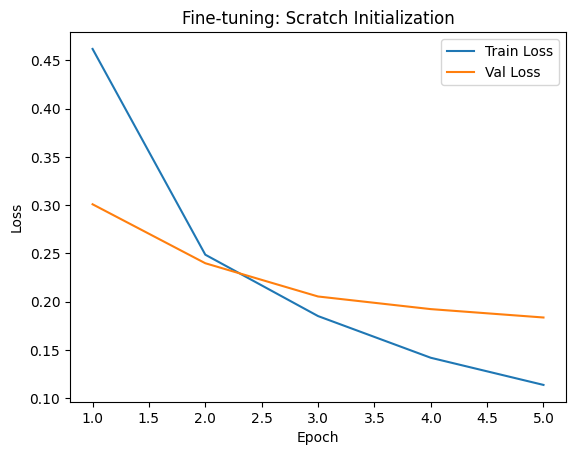

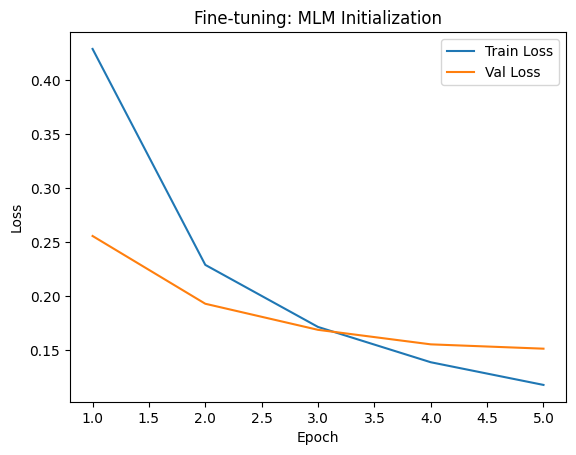

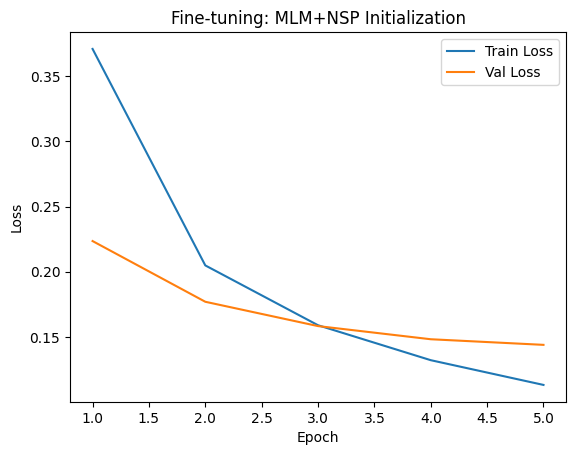

In [322]:
def plot_hist(hist, title):
    epochs = range(1, len(hist["train_loss"]) + 1)
    plt.figure()
    plt.plot(epochs, hist["train_loss"], label="Train Loss")
    plt.plot(epochs, hist["val_loss"], label="Val Loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_hist(hist_scratch, "Fine-tuning: Scratch Initialization")
plot_hist(hist_mlm, "Fine-tuning: MLM Initialization")
plot_hist(hist_nsp, "Fine-tuning: MLM+NSP Initialization")

## Fine-tuning Comparison Plots  
Compare validation F1 curves (raw and best-so-far) across different encoder initializations.

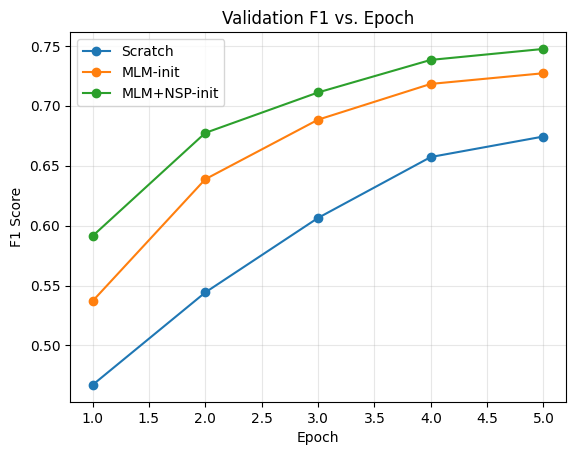

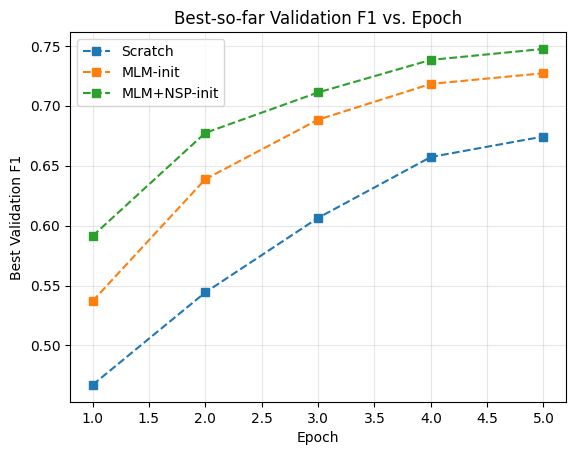

In [318]:
# ------------------------------------------------------------
# TODO: Compare fine-tuning runs with Validation F1 plots.
# Requirements:
#   1) Build a dict `hists` that always includes "Scratch"
#      and conditionally includes "MLM-init" and "MLM+NSP-init" if available.
#   2) Plot Validation F1 vs epoch for each run on the same figure.
#   3) Plot "best-so-far" Validation F1 vs epoch for each run on a second figure.
# Notes:
#   - Some histories may store the key as "val_f1" or "val_F1".
#   - Make x-axis epochs start at 1.
#   - Keep the plot labels, titles, and legend clear.
# ------------------------------------------------------------

hists = {}
hists["Scratch"] = hist_scratch
hists["MLM-init"] = hist_mlm
hists["MLM+NSP-init"] = hist_nsp

def get_val_f1(h):
    if "val_f1" in h: return h["val_f1"]
    if "val_F1" in h: return h["val_F1"]
    return []

plt.figure()
for name, h in hists.items():
    f1_scores = get_val_f1(h)
    epochs = range(1, len(f1_scores) + 1)
    plt.plot(epochs, f1_scores, marker='o', label=name)

plt.title("Validation F1 vs. Epoch")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure()
for name, h in hists.items():
    f1_scores = get_val_f1(h)
    if not f1_scores: continue
    best_so_far = np.maximum.accumulate(f1_scores)
    epochs = range(1, len(f1_scores) + 1)
    plt.plot(epochs, best_so_far, marker='s', linestyle='--', label=name)

plt.title("Best-so-far Validation F1 vs. Epoch")
plt.xlabel("Epoch")
plt.ylabel("Best Validation F1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Qualitative Inspection: Token-level Predictions  
Print one validation example with true vs. predicted NER tags for the best-performing fine-tuned model.

In [319]:
@torch.no_grad()
def pretty_print_ner_tokens(tokens, true_ids, pred_ids, max_tokens=60):
    print(f"{'TOKEN':<18} {'TRUE':<15} {'PRED':<15} {'OK?'}")
    print("-" * 55)

    printed_count = 0
    for i, token in enumerate(tokens):
        if printed_count >= max_tokens:
            break

        t_id = true_ids[i].item() if torch.is_tensor(true_ids) else true_ids[i]
        p_id = pred_ids[i].item() if torch.is_tensor(pred_ids) else pred_ids[i]

        if t_id == cfg.ignore_index:
            continue

        true_tag = id2label[t_id]
        pred_tag = id2label[p_id]

        marker = "✓" if t_id == p_id else "✗"

        print(f"{token:<18} {true_tag:<15} {pred_tag:<15} {marker}")
        printed_count += 1

    print("-" * 55)

selected_model = None
run_name = "None"

if "model_nsp" in globals():
    selected_model = model_nsp
    run_name = "MLM+NSP Initialization"
elif "model_mlm" in globals():
    selected_model = model_mlm
    run_name = "MLM Initialization"
elif "model_scratch" in globals():
    selected_model = model_scratch
    run_name = "Scratch Initialization"
else:
    print("No fine-tuned models found to inspect.")

if selected_model is not None:
    batch = next(iter(ft_valid_loader))

    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    token_type_ids = batch["token_type_ids"].to(device)
    position_ids = batch["position_ids"].to(device)
    labels = batch["labels"].to(device)

    selected_model.eval()
    logits = selected_model(
        input_ids,
        attention_mask=attention_mask,
        token_type_ids=token_type_ids,
        position_ids=position_ids
    )
    preds = logits.argmax(dim=-1)

    print(f"\nQualitative Inspection: {run_name}")
    print(f"Example 0 from Validation Batch:\n")

    pretty_print_ner_tokens(
        batch["tokens"][0],
        labels[0],
        preds[0],
        max_tokens=30
    )


Qualitative Inspection: MLM+NSP Initialization
Example 0 from Validation Batch:

TOKEN              TRUE            PRED            OK?
-------------------------------------------------------
A                  O               O               ✓
Russian            B-NORP          B-NORP          ✓
diver              O               O               ✓
has                O               O               ✓
found              O               O               ✓
the                O               O               ✓
bodies             O               O               ✓
of                 O               O               ✓
three              B-CARDINAL      B-CARDINAL      ✓
of                 O               O               ✓
the                O               O               ✓
118                B-CARDINAL      B-CARDINAL      ✓
sailors            O               O               ✓
who                O               O               ✓
were               O               O               ✓
killed      

## Concept Checks (answer in Markdown, no code)

1. **Why might MLM pretraining help NER?**  
   Explain the kind of information MLM forces the encoder to learn, and why that information could transfer to token-level labeling.

4. **Interpret the curves:** If the pretrained model reaches higher validation F1 earlier, what does that suggest?  
   Relate your answer to optimization and sample efficiency.

# Part 11 — Fine-tuning a Pretrained Transformer for NER

In this part we switch from our **from-scratch encoders** to a **pretrained Transformer** (e.g., DistilBERT/BERT) and fine-tune it for **Named Entity Recognition** using the Hugging Face `Trainer` API.

Why this matters:
- Pretraining gives strong language representations “for free”, so fine-tuning often reaches high NER performance with much less task-specific training.
- The main technical challenge for token classification is **label alignment**: our dataset labels are word-level, but the tokenizer produces **subword tokens**.
- We will also test **data efficiency** by training on different fractions of the training set and comparing Test F1.

## Choose Pretrained Backbone

Select a HuggingFace checkpoint and load its tokenizer for the pretrained NER fine-tuning experiments.

In [324]:
MODEL_NAME = "distilbert-base-cased"
# MODEL_NAME = "bert-base-cased"  # stronger but heavier

print("Using:", MODEL_NAME)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

print("num_labels:", num_labels)
print("example label:", id2label[12])

Using: distilbert-base-cased


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

num_labels: 37
example label: I-ORG


## Sanity Check: Labels Are Available

Quickly verify that the label mapping and label count are loaded from earlier parts.

In [325]:
# Ensure these exist from earlier parts
print("num_labels:", num_labels)
print("example label:", id2label[13])

num_labels: 37
example label: B-PERCENT


In [326]:
def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(examples["tokens"],  truncation=True,  is_split_into_words=True)
    labels = []

    for i, label in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx
        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs


## Tokenize and Align Word-Level Labels

Convert word-level NER tags into token-level labels after subword tokenization.

In [327]:
hf_ner = DatasetDict({
    "train": ds["train"],
    "validation": ds["validation"],
    "test": ds["test"],
})

tok_ner = hf_ner.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=hf_ner["train"].column_names,
)

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

print(tok_ner)

Map:   0%|          | 0/59924 [00:00<?, ? examples/s]

Map:   0%|          | 0/8528 [00:00<?, ? examples/s]

Map:   0%|          | 0/8262 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 59924
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 8528
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 8262
    })
})


## Trainer Metrics (Entity-Level)

Compute precision/recall/F1 from token-level predictions while ignoring special/padded positions.

In [328]:
def compute_metrics_trainer(eval_pred):
    # TODO: unpack eval_pred -> (logits, labels)
    logits, labels = eval_pred

    # TODO: preds = argmax over last dim
    preds = np.argmax(logits, axis=-1)

    y_true_all, y_pred_all = [], []
    for lab_seq, pred_seq in zip(labels, preds):
        true_tags, pred_tags = [], []
        for l, p in zip(lab_seq, pred_seq):
            if l != -100:
                true_tags.append(id2label[l])
                pred_tags.append(id2label[p])

        y_true_all.append(true_tags)
        y_pred_all.append(pred_tags)

    # TODO: return dict with precision/recall/f1 (seqeval)
    return {
        "precision": precision_score(y_true_all, y_pred_all),
        "recall": recall_score(y_true_all, y_pred_all),
        "f1": f1_score(y_true_all, y_pred_all),
    }

## TrainingArguments + Trainer Setup

Create version-safe HuggingFace `TrainingArguments` and `Trainer` kwargs (tokenizer/processing_class) for fine-tuning.

In [329]:
def make_training_args(
    output_dir: str,
    seed: int,
    num_train_epochs: float,
    learning_rate: float = 2e-5,
    train_bs: int = 16,
    eval_bs: int = 32,
    weight_decay: float = 0.01,
    warmup_ratio: float = 0.1,
    eval_steps: int = 200,
    save_steps: int = 200,
    logging_steps: int = 50,
    save_total_limit: int = 1,
):
    ta_sig = inspect.signature(TrainingArguments.__init__)

    # TODO: fill the important kwargs (batch sizes, lr, epochs, wd, warmup, fp16, etc.)
    kwargs = dict(
        output_dir=output_dir,
        overwrite_output_dir=True,
        logging_steps=logging_steps,
        report_to="none",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        seed=seed,
        data_seed=seed,
        save_total_limit=save_total_limit,
        per_device_train_batch_size=train_bs,
        per_device_eval_batch_size=eval_bs,
        num_train_epochs=num_train_epochs,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        warmup_ratio=warmup_ratio,
        fp16=torch.cuda.is_available(),
    )

    # transformers version compatibility
    if "eval_strategy" in ta_sig.parameters:
        kwargs["eval_strategy"] = "steps"
    else:
        kwargs["evaluation_strategy"] = "steps"

    # TODO: set eval_steps/save_steps and save_strategy="steps"
    kwargs["eval_steps"] = eval_steps
    kwargs["save_steps"] = save_steps
    kwargs["save_strategy"] = "steps"

    return TrainingArguments(**kwargs)

def make_trainer_kwargs(model, args, train_dataset, eval_dataset):
    # TODO: build Trainer kwargs dict (model/args/datasets/collator/metrics)
    t_kwargs = dict(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        data_collator=data_collator,
        compute_metrics=compute_metrics_trainer,
    )

    # TODO: pick correct key depending on transformers version
    tr_sig = inspect.signature(Trainer.__init__)
    if "processing_class" in tr_sig.parameters:
        t_kwargs["processing_class"] = tokenizer
    else:
        t_kwargs["tokenizer"] = tokenizer

    return t_kwargs

## Tokenize + align word-level labels to subword tokens

Convert word-level NER tags into token-level labels using `word_ids()` and `ignore_index` for non-first subwords.

In [330]:
def plot_log_history(log_history, title_prefix=""):
    steps_train, loss_train = [], []
    steps_eval, f1_eval = [], []

    for item in log_history:
        if "loss" in item and "eval_loss" not in item and "step" in item:
            steps_train.append(item["step"])
            loss_train.append(item["loss"])
        if "eval_f1" in item and "step" in item:
            steps_eval.append(item["step"])
            f1_eval.append(item["eval_f1"])

    if steps_train:
        plt.figure()
        plt.plot(steps_train, loss_train)
        plt.xlabel("Step")
        plt.ylabel("Train loss")
        plt.title(f"{title_prefix} Train loss vs step")
        plt.show()

    if steps_eval:
        plt.figure()
        plt.plot(steps_eval, f1_eval, marker="o")
        plt.xlabel("Step")
        plt.ylabel("Validation F1")
        plt.title(f"{title_prefix} Val F1 vs step")
        plt.show()

## Build pretrained token-classification model

Load a pretrained backbone and adapt it to `num_labels` for NER.

In [331]:
def build_hf_ner_model():
    m = AutoModelForTokenClassification.from_pretrained(MODEL_NAME, num_labels=num_labels, id2label=id2label, label2id=label2id)
    m.config.output_attentions = False
    m.config.output_hidden_states = False
    return m

## Train on a fraction of the data

Subsample the training set, fine-tune, and return validation/test metrics and logs.

In [332]:
def run_data_fraction(
    frac: float,
    seed: int = 42,
    num_train_epochs: float = 1.0,
    learning_rate: float = 2e-5,
    train_bs: int = 16,
    eval_bs: int = 32,
    eval_steps: int = 200,
    save_steps: int = 200,
    logging_steps: int = 50,
):
    n = len(tok_ner["train"])
    k = max(1, int(frac * n))
    sub = tok_ner["train"].shuffle(seed=seed).select(range(k))

    print(f"\n>>> Running Experiment: Fraction={frac:.2f} (n={k})")
    model = build_hf_ner_model()
    output_dir = f"./hf_ner_frac_{frac:.2f}"
    args = make_training_args(
        output_dir=output_dir,
        seed=seed,
        num_train_epochs=num_train_epochs,
        learning_rate=learning_rate,
        train_bs=train_bs,
        eval_bs=eval_bs,
        eval_steps=eval_steps,
        save_steps=save_steps,
        logging_steps=logging_steps
    )

    t_kwargs = make_trainer_kwargs(
        model=model,
        args=args,
        train_dataset=sub,
        eval_dataset=tok_ner["validation"]
    )
    trainer = Trainer(**t_kwargs)
    trainer.train()
    val_metrics = trainer.evaluate()
    test_metrics = trainer.evaluate(tok_ner["test"], metric_key_prefix="test")

    test_f1 = test_metrics.get("test_f1", 0.0)
    test_loss = test_metrics.get("test_loss", 0.0)
    val_f1 = val_metrics.get("eval_f1", 0.0)

    print(f"DONE: Val F1={val_f1:.4f} | Test F1={test_f1:.4f}")

    return test_f1, test_loss, model, val_metrics, test_metrics

## Data efficiency sweep

Run the same pretrained model on multiple training fractions and plot Test F1 vs fraction.

In [333]:
fractions = [0.10, 0.25, 1.00]
seed = cfg.seed
rows = []
logs_by_frac = {}

for f in fractions:
    test_f1, test_loss, model, val_metrics, test_metrics = run_data_fraction(
        frac=f,
        seed=seed,
        num_train_epochs=1.0
    )

    rows.append({
        "Fraction": f,
        "Test F1": test_f1,
        "Test Loss": test_loss,
        "Val F1": val_metrics.get("eval_f1", 0.0)
    })

    logs_by_frac[f] = {
        "val": val_metrics,
        "test": test_metrics
    }

frac_df = pd.DataFrame(rows)
frac_df = frac_df.sort_values(by="Fraction").reset_index(drop=True)

print("\nFinal Foundation Model Results (by Data Fraction):")
print(frac_df)


>>> Running Experiment: Fraction=0.10 (n=5992)


model.safetensors:   0%|          | 0.00/263M [00:00<?, ?B/s]

{'loss': 1.9351, 'grad_norm': 1.3926823139190674, 'learning_rate': 1.6449704142011837e-05, 'epoch': 0.26595744680851063}
{'loss': 0.4248, 'grad_norm': 0.8974587321281433, 'learning_rate': 1.0532544378698226e-05, 'epoch': 0.5319148936170213}
{'loss': 0.305, 'grad_norm': 1.7873642444610596, 'learning_rate': 4.615384615384616e-06, 'epoch': 0.7978723404255319}
{'train_runtime': 30.0469, 'train_samples_per_second': 199.421, 'train_steps_per_second': 6.257, 'train_loss': 0.7653323132941063, 'epoch': 1.0}
{'eval_loss': 0.24253344535827637, 'eval_precision': 0.49367816091954025, 'eval_recall': 0.5433761069943972, 'eval_f1': 0.5173363159253205, 'eval_runtime': 12.7284, 'eval_samples_per_second': 669.999, 'eval_steps_per_second': 10.528, 'epoch': 1.0}
{'test_loss': 0.2487792670726776, 'test_precision': 0.492645285748734, 'test_recall': 0.5444612241272098, 'test_f1': 0.5172588404084733, 'test_runtime': 11.7677, 'test_samples_per_second': 702.089, 'test_steps_per_second': 11.047, 'epoch': 1.0}
DON

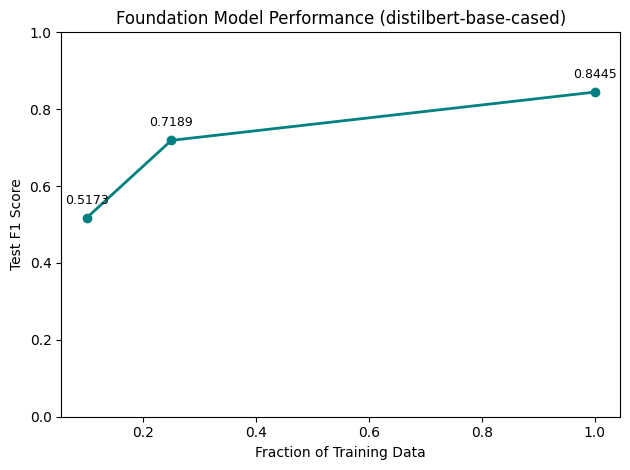

In [336]:
plt.figure()
plt.plot(frac_df["Fraction"], frac_df["Test F1"], marker='o', linestyle='-', color='teal', linewidth=2)

for i, row in frac_df.iterrows():
    plt.annotate(f"{row['Test F1']:.4f}",
                 (row["Fraction"], row["Test F1"]),
                 textcoords="offset points",
                 xytext=(0,10),
                 ha='center',
                 fontsize=9)

plt.title(f"Foundation Model Performance ({MODEL_NAME})")
plt.xlabel("Fraction of Training Data")
plt.ylabel("Test F1 Score")
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()

## Concept Checks (answer in Markdown, no code)

1. **Subword label alignment:**  
   Suppose a word is split into subwords, e.g. `["play", "##ing"]`.  
   - Which token(s) should receive the original word label?  **My Answer**: Typically, only the first subword ("play") receives the original label (e.g., B-VERB).
   - Which token(s) should receive `ignore_index`?  **My Answer**: All subsequent subwords ("##ing") and special tokens (like [CLS] or [SEP]) receive the ignore_index (usually -100).
   - Why? **My Answer**: Predicting the same label for every subword of a single word doesn't provide the model with new semantic information and can bias the loss toward longer words. It simplifies the decoding process; we only care about the model's prediction for the start of the word to determine the entity type.

2. **Model choice trade-off:**  
   Compare using `distilbert-base-cased` vs `bert-base-cased` in terms of:
   - expected accuracy/F1
   - training/inference cost
   - when you would prefer each one

   **My Answer**: `distilbert-base-cased` is the preferred choice for most practical engineering tasks where the marginal gain in F1 from the full BERT model does not justify the significant increase in computation and latency. `bert-base-cased` is preferred for research benchmarks or "offline" tasks where accuracy is the only priority.

---

> **“In theory there is no difference between theory and practice. In practice there is.”**

This notebook is where Transformers stop being magic and start being engineering.

*Wish you luck,*  
**Sina Bayrami**

---